<a href="https://colab.research.google.com/github/ecloguehwang/2026-Seojinhyeop-Workshop/blob/main/00%EB%8C%80%EB%A1%9C%EB%81%9D%EB%82%98%EB%8A%94%EC%9E%90%EB%A3%8C_%ED%95%A9%EB%B6%88%EC%9E%90%EB%A3%8C%EC%A0%95%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###: 4년제 합격자
###. 수도권 합격자
###. 전문대 합격자
###. 인서울 4년제 합격자

In [ ]:
#colab에서 matplotlib와 sns 라이브러리 그래프 한글을 깨지지 않게 하는 법A: 이 코드실행하고 런타임(runtime) 다시 실행하기
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (21.3 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and direct

In [ ]:
#pandas, openpyxl 라이브러리 부르기
import pandas as pd
import numpy as np
from tabulate import tabulate
import matplotlib.pyplot as plt


#matplotlib에서 한글구현
plt.rc('font', family='NanumBarunGothic')

#그래프 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False



##  데이터 부르기
path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')


# 첫 5줄을 봅니다.
df.tail(3)

,학번,이름,지역,대학,지원시기,전형명,계열,모집단위,1단계,최종,...,선택2_백분위,선택2_등급,한국사_등급,제2외국어_과목명,제2외국어_등급,표점합수능,백분위수능,등급수능,이름_대학_모집단위_최종_표점합수능_백분위수능_등급수능,대학_모집단위_최종_표점합수능_백분위수능_등급수능
710,NaN,NaN,인천,인천재능대학교,수시2차,일반고,인문,호텔관광과,NaN,불,...,10.0,8.0,6.0,NaN,NaN,223,13.8,6.5,nan 인천재능대학교 호텔관광과 불/223점 13.8% 6.5등급,인천재능대학교 호텔관광과 불/223점 13.8% 6.5등급
711,NaN,NaN,서울,한국폴리텍1대학,수시2차,일반전형,자연,의료정보,NaN,불,...,10.0,8.0,6.0,NaN,NaN,223,13.8,6.5,nan 한국폴리텍1대학 의료정보 불/223점 13.8% 6.5등급,한국폴리텍1대학 의료정보 불/223점 13.8% 6.5등급
712,NaN,NaN,서울,백석예술대학교,수시2차,일반학생,인문,유아교육과,NaN,합,...,10.0,8.0,6.0,NaN,NaN,223,13.8,6.5,nan 백석예술대학교 유아교육과 합/223점 13.8% 6.5등급,백석예술대학교 유아교육과 합/223점 13.8% 6.5등급


In [ ]:
#'대학'열의 값의 빈도계산

df_uni = df['대학'].value_counts()
df_uni

,count
대학,
인하공업전문대학,17
수원대,16
경기대(수원),15
한양여자대학교,15
가천대(글로벌),13
...,...
한국예술종합학교,1
정화예술대학교,1
군산대,1


In [ ]:
#합불자료 인원: 121명

df_number = df.drop_duplicates('전과목')
df_number = len(df_number)
print(df_number)

121


In [ ]:
#중복제외한 합격률 75%

#중복제외한 수능응시자수
df_number = df.drop_duplicates('전과목')
df_number = len(df_number)

#합격자
df_pass = df[df.최종 == '합']


#중복제외한 합격자수
df_pass_noduplicate = df_pass.drop_duplicates('전과목')

#중복제외한 합격자 비율
df_pass_noduplicate_ratio = (len(df_pass_noduplicate) / df_number) * 100


#소수점 첫째자리에 반올림
df_pass_noduplicate_ratio = int(round(df_pass_noduplicate_ratio, 0))


print(f'중복제외한 합격률 {df_pass_noduplicate_ratio}%')

중복제외한 합격률 75%


In [ ]:
#중복제외한 합격률 75%- 134명 학생기준: 지원건수 대비 아님!

#중복제외한 수능응시자수
df_number = df.drop_duplicates('전과목')
df_number = len(df_number)

#합격자
df_pass = df[df.최종 == '합']


#중복제외한 합격자수
df_pass_noduplicate = df_pass.drop_duplicates('전과목')

#이름, 대학, 모집단위
df_pass_noduplicate = df_pass_noduplicate[['전과목', '대학', '모집단위', '최종']]

df_pass_noduplicate

,전과목,대학,모집단위,최종
3,1.000,서울대,치의학대학원(치의학과),합
8,1.071,고려대,컴퓨터학과,합
14,1.186,고려대,경영대학,합
18,1.526,울산과학대학교,컴퓨터IT학부,합
26,1.726,건국대,생명과학대학자유전공학부,합
...,...,...,...,...
693,7.407,숭의여자대학교,소프트웨어융합과,합
696,7.474,백석예술대학교,외식학부,합
697,7.617,백석예술대학교,외식학부,합
704,8.434,대림대,건축과,합


In [ ]:
#'전과목'열의 값이 1.000인 학생의 '대학', '모집단위', '최종', '전과목',  추출

df_top = df[df['전과목'] == 1.000]
df_top = df_top[['이름', '대학', '모집단위', '최종', '표점합수능', '백분위수능', '등급수능', '전과목']]
df_top

,이름,대학,모집단위,최종,표점합수능,백분위수능,등급수능,전과목
0,NaN,가천대(메디컬),의예과,불,384,93.2,1.9,1.0
1,NaN,가톨릭대(성의),의예과,불,384,93.2,1.9,1.0
2,NaN,경희대,의예과,불,384,93.2,1.9,1.0
3,NaN,서울대,치의학대학원(치의학과),합,384,93.2,1.9,1.0
4,NaN,연세대,치의예과,불,384,93.2,1.9,1.0


In [ ]:
#1. 서울주요대(18개대) 대학별 합격건수

import os
import pandas as pd


# 대학교 이름 리스트 데이터
uni = [
    '서울대', '연세대', '고려대', '서강대', '성균관대', '한양대',
    '중앙대', '경희대', '한국외대', '서울시립대', '이화여대', '건국대',
    '동국대', '홍익대', '숙명여대', '국민대', '숭실대', '세종대'
]


# 서울 주요대학 수시합격자수 출력
print("\n***2025학년도 수명고 합격건수***")

total_accepted = 0  # Variable to store the total number of accepted students

for u in range(len(uni)):
    df_u = df[(df.대학 == uni[u]) & (df.최종 == '합')]
    accepted_count = len(df_u['대학'])
    total_accepted += accepted_count
    print(uni[u], str(accepted_count) + "건")

print(f"\n총 합격자 수: {total_accepted}건")


***2025학년도 수명고 합격건수***
서울대 1건
연세대 1건
고려대 2건
서강대 1건
성균관대 1건
한양대 4건
중앙대 0건
경희대 1건
한국외대 0건
서울시립대 0건
이화여대 2건
건국대 1건
동국대 0건
홍익대 1건
숙명여대 0건
국민대 2건
숭실대 1건
세종대 4건

총 합격자 수: 22건


In [ ]:
#2.수시, 정시별 서울주요대 합격자 명단

import pandas as pd
import matplotlib.pyplot as plt



# 대학교 이름 리스트 데이터
uni = [
    '서울대', '연세대', '고려대', '서강대', '성균관대', '한양대',
    '중앙대', '경희대', '한국외대', '서울시립대', '이화여대', '건국대',
    '동국대', '홍익대', '숙명여대', '국민대', '숭실대', '세종대'
]



# 데이터 부르기
path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')


# '지원시기'열의 값 변경: 가,나
df['지원시기'] = df['지원시기'].replace({'정시(가)': '정시', '정시(나)': '정시', '정시(다)': '정시',
                                       '수시1차': '수시', '수시2차': '수시'})

# 빈 리스트
uni_new = []
num_su = []
num_je = []


# 리스트에 새로운 대학리스트와, 수시합격자, 정시합격자를 담기
for u in uni:
    df_u = df[(df.대학 == u) & (df.최종 == '합')]
    df_u = df_u[['지원시기', '학번', '대학', '최종']]

    num_su_u = len(df_u[df_u['지원시기'] == '수시'])
    num_je_u = len(df_u[df_u['지원시기'] == '정시'])


    if num_su_u >= 1 or num_je_u >= 1:  # '지원시기'열의 값이 1 이상일 때만 값을 표시
        uni_new.append(u)
        num_su.append(num_su_u)
        num_je.append(num_je_u)

        print(u, "합격자수 - 수시:", str(num_su_u) + "명,", "정시:", str(num_je_u) + "명")
        print("-----------------------------------------\n")

서울대 합격자수 - 수시: 1명, 정시: 0명
-----------------------------------------

연세대 합격자수 - 수시: 1명, 정시: 0명
-----------------------------------------

고려대 합격자수 - 수시: 2명, 정시: 0명
-----------------------------------------

서강대 합격자수 - 수시: 1명, 정시: 0명
-----------------------------------------

성균관대 합격자수 - 수시: 1명, 정시: 0명
-----------------------------------------

한양대 합격자수 - 수시: 4명, 정시: 0명
-----------------------------------------

경희대 합격자수 - 수시: 1명, 정시: 0명
-----------------------------------------

이화여대 합격자수 - 수시: 2명, 정시: 0명
-----------------------------------------

건국대 합격자수 - 수시: 1명, 정시: 0명
-----------------------------------------

홍익대 합격자수 - 수시: 1명, 정시: 0명
-----------------------------------------

국민대 합격자수 - 수시: 2명, 정시: 0명
-----------------------------------------

숭실대 합격자수 - 수시: 1명, 정시: 0명
-----------------------------------------

세종대 합격자수 - 수시: 4명, 정시: 0명
-----------------------------------------



In [ ]:
#3. 의치한약수(ex: 의학 등) 합격자 명단 찾기

df_의치한약수 = df['모집단위'].str.contains('[의치한약수]+') & ~df['모집단위'].str.contains('[ICT외류기공위료작특국생학]+')& ~df['모집단위'].str.contains('[한문교육]+')



subset_df = df[df_의치한약수]
subset_df_p = subset_df[(subset_df.최종 == '합')]
subset_df_p = subset_df_p[['학번', '이름', '대학', '모집단위', '전형분류', '최종', '전과목', '백분위수능']]
print("***2025학년도 수시 의치한약수 합격자 명단***")
print(subset_df_p)
print("\n-----------------------------------------")
print("***2025학년도 수명고 수시 의치한약수 합격자수***")

***2026학년도 수시 의치한약수 합격자 명단***
Empty DataFrame
Columns: [학번, 이름, 대학, 모집단위, 전형분류, 최종, 전과목, 백분위수능]
Index: []

-----------------------------------------
***2025학년도 수명고 수시 의치한약수 합격자수***


In [ ]:
#4. 특수대 합격자 명단

sp = ['경찰대', '육군사관학교', '해군사관학교', '공군사관학교', '국군간호사관학교', 'GIST', 'DGIST', 'UNIST', '한국과학기술원(KAIST)', '한국예술종합학교']


print("***202학년도 수시 특수대 합격자 명단***\n")
for u in range(len(sp)):
    df_특수대 = df[(df.대학 == sp[u]) & (df.최종 == '합')]
    df_특수대 = df_특수대[['학번', '대학', '모집단위', '전형분류', '최종', '전과목', '백분위수능' ]]
    print("%s 대학 합격자" % sp[u])
    #print("{} 대학 합격자는 {}명" .format(sp[u] len(df_특수대)))
    print(df_특수대)
    print("--------------------------------------")


print("\n-----------------------------------------")
print("***2025학년도 수시 특수대 합격자수***\n")

# 특수대 합격자수
sp = ['경찰대', '육군사관학교', '해군사관학교', '공군사관학교', 'GIST', 'DGIST', 'UNIST', 'KAIST', '한국예술종합학교']

for u in range(len(sp)):
    df_특수대 = df[(df.대학 == sp[u]) & (df.최종 == '합')]
    df_특수대 = df_특수대[['학번', '대학', '모집단위', '전형분류', '최종']]
print("2025학년도 특수대 수시합격자수는 %d명입니다." % len(df_특수대))

***202학년도 수시 특수대 합격자 명단***

경찰대 대학 합격자
Empty DataFrame
Columns: [학번, 대학, 모집단위, 전형분류, 최종, 전과목, 백분위수능]
Index: []
--------------------------------------
육군사관학교 대학 합격자
Empty DataFrame
Columns: [학번, 대학, 모집단위, 전형분류, 최종, 전과목, 백분위수능]
Index: []
--------------------------------------
해군사관학교 대학 합격자
Empty DataFrame
Columns: [학번, 대학, 모집단위, 전형분류, 최종, 전과목, 백분위수능]
Index: []
--------------------------------------
공군사관학교 대학 합격자
Empty DataFrame
Columns: [학번, 대학, 모집단위, 전형분류, 최종, 전과목, 백분위수능]
Index: []
--------------------------------------
국군간호사관학교 대학 합격자
Empty DataFrame
Columns: [학번, 대학, 모집단위, 전형분류, 최종, 전과목, 백분위수능]
Index: []
--------------------------------------
GIST 대학 합격자
Empty DataFrame
Columns: [학번, 대학, 모집단위, 전형분류, 최종, 전과목, 백분위수능]
Index: []
--------------------------------------
DGIST 대학 합격자
Empty DataFrame
Columns: [학번, 대학, 모집단위, 전형분류, 최종, 전과목, 백분위수능]
Index: []
--------------------------------------
UNIST 대학 합격자
Empty DataFrame
Columns: [학번, 대학, 모집단위, 전형분류, 최종, 전과목, 백분위수능]
Index: []
----------------

/tmp/ipykernel_19256/3132605285.py:122: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


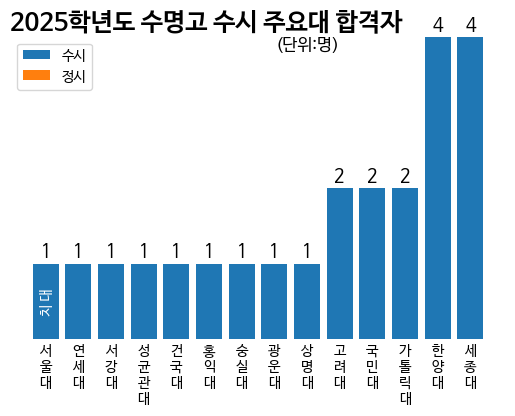

In [ ]:
#5. 서울주요대 합격자수 막대그래프(세로)

import pandas as pd
import matplotlib.pyplot as plt

# 데이터 부르기
path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')

# ── 대학명 통합 ─────────────────────────────
df['대학'] = df['대학'].replace({
    '가톨릭대(성심)': '가톨릭대',
    '가천대(글로벌)': '가천대'
})

# 표시할 대학 리스트
uni = ['서울대', '연세대', '고려대', '서강대', '성균관대', '한양대', '중앙대',
       '한국외국어대', '서울시립대', '이화여자대', '건국대', '동국대', '홍익대',
       '숙명여자대', '국민대', '숭실대', '세종대', '서울과기대', '광운대',
       '명지대', '상명대', '가톨릭대', '가천대']

# 추가 대학
uni = uni + ['한국과학기술원(KAIST)', '한국예술종합학교', '경희대학교(국제)']

# 지원시기 통합
df['지원시기'] = df['지원시기'].replace({
    '정시(가)': '정시', '정시(나)': '정시', '정시(다)': '정시',
    '수시1차': '수시', '수시2차': '수시'
})

# 빈 리스트
uni_new = []
num_su = []
num_je = []

# 데이터 집계
for u in uni:
    df_u = df[(df['대학'] == u) & (df['최종'] == '합')]
    df_u = df_u[['지원시기', '학번', '대학', '최종']]

    num_su_u = len(df_u[df_u['지원시기'] == '수시'])
    num_je_u = len(df_u[df_u['지원시기'] == '정시'])

    if num_su_u >= 1 or num_je_u >= 1:
        uni_new.append(u)
        num_su.append(num_su_u)
        num_je.append(num_je_u)

# 필터링
filtered = [(u, su, je) for u, su, je in zip(uni_new, num_su, num_je) if su >= 1 or je >= 1]

if len(filtered) > 0:

    # 정렬
    data = sorted(filtered, key=lambda x: x[1] + x[2], reverse=False)
    uni_new = [x[0] for x in data]
    num_su = [x[1] for x in data]
    num_je = [x[2] for x in data]

    # ── 그래프 표시용 대학명 변환 ─────────────────
    def format_uni_name(u):
        if u == '한국예술종합학교':
            return u
        if u == '한국과학기술원(KAIST)':
            return 'KAIST'
        if u == '경희대학교(국제)':
            return '경희대'

        name = u.replace('학교', '')
        name = name.replace('숙명여자대', '숙명여대')
        name = name.replace('이화여자대', '이화여대')

        return name

    uni_display = [format_uni_name(u) for u in uni_new]

    # 그래프
    fig, ax = plt.subplots()

    ax.bar(uni_display, num_su, label='수시')
    ax.bar(uni_display, num_je, bottom=num_su, label='정시')

    # 값 표시
    for i, (su, je) in enumerate(zip(num_su, num_je)):
        if su >= 1:
            ax.text(i, su + 0.09, su, ha='center', fontsize=13)
        if je >= 1:
            ax.text(i, su + je + 0.09, je, ha='center', fontsize=13)

    # ── 의대 표시 (핵심) ─────────────────────────
    for i, (uni, su, je) in enumerate(zip(uni_new, num_su, num_je)):

        # 기존 의대 대학
        if uni in ['서울대']:
            y_pos = su if su > 0 else je

            ax.text(i + 0.08, y_pos - 0.5, '치 대',
                    ha='center', va='center',
                    fontsize=10, color='white', rotation=90)

    # 범례
    ax.legend()

    # 제목
    ax.set_title('2025학년도 수명고 수시 주요대 합격자',
                 fontsize=18, fontweight='bold', loc='left')

    # 부제
    ax.text(0.6, 1.00, '(단위:명)',
            ha='center', va='top', transform=ax.transAxes, fontsize=12)

    # X축 설정
    ax.tick_params(axis='x', which='both', length=0)

    # 세로 라벨
    plt.xticks(rotation=0, ha='center', va='top')
    labels = ax.get_xticklabels()

    for label in labels:
        label.set_text('\n'.join(label.get_text()))

    ax.set_xticklabels(labels)

    # 스타일
    plt.box(False)
    plt.yticks([])

    plt.subplots_adjust(bottom=0.25)

    plt.show()

else:
    print("아쉽게도 그래프를 그릴 합격자가 없습니다.")

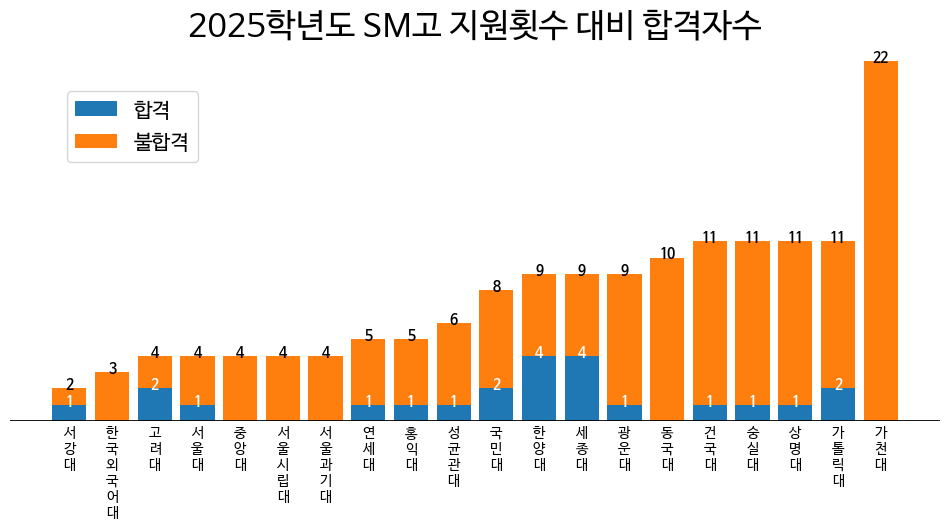

In [ ]:
# 6. 서울주요대 합격자 및 불합격자 누적 세로 막대그래프

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FixedLocator

# 데이터 부르기
path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')


# ── 가천대 캠퍼스 통합 ─────────────────────────────
df['대학'] = df['대학'].replace({
    '가천대(글로벌)': '가천대',
    '가천대(메디컬)': '가천대'
})


# 표시할 대학 리스트
uni = ['서울대', '연세대', '고려대', '서강대', '성균관대', '한양대', '중앙대',
       '한국외국어대', '서울시립대', '이화여자대', '건국대', '동국대', '홍익대',
       '숙명여자대', '국민대', '숭실대', '세종대', '서울과기대', '광운대',
       '명지대', '상명대', '가톨릭대(성심)', '가천대']



# 대학별 지원/합격 계산
num_applications = []
num_acceptance = []

for u in uni:
    uni_admissions = df[df['대학'] == u]

    num_app = len(uni_admissions)
    num_acc = len(uni_admissions[uni_admissions['최종'] == '합'])

    num_applications.append(num_app)
    num_acceptance.append(num_acc)

admission_df = pd.DataFrame({
    '대학': uni,
    '지원건수': num_applications,
    '합격건수': num_acceptance
})

# 빈도가 0인 대학 제거
admission_df = admission_df[admission_df['지원건수'] != 0]

# 지원건수 기준 오름차순 정렬
admission_df = admission_df.sort_values('지원건수')

# ── 그래프 표시용 대학명 변환 ─────────────────────
def format_uni_name(u):
    if u == '가톨릭대(성심)':
        return '가톨릭대'

    name = u.replace('학교', '')
    name = name.replace('숙명여자대', '숙명여대')
    name = name.replace('이화여자대', '이화여대')

    return name

uni_display = [format_uni_name(u) for u in admission_df['대학']]

# 그래프 생성
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    x=range(len(admission_df)),
    height='합격건수',
    data=admission_df,
    bottom=0,
    label='합격'
)

ax.bar(
    x=range(len(admission_df)),
    height=admission_df['지원건수'] - admission_df['합격건수'],
    data=admission_df,
    bottom=admission_df['합격건수'],
    label='불합격'
)

# ── x축 레이블 세로쓰기 ─────────────────────────
ax.xaxis.set_major_locator(FixedLocator(range(len(uni_display))))

def name_to_vertical(name):
    if '·' in name:
        parts = name.split('·')
        return '\n'.join(parts[0]) + '\n' + '\n'.join(parts[1])
    return '\n'.join(name)

ax.set_xticklabels(
    [name_to_vertical(name) for name in uni_display],
    rotation=0,
    ha='center',
    va='top'
)

# 제목
ax.set_title('2025학년도 SM고 지원횟수 대비 합격자수', fontsize=24)

# 합격자 수 표시
for i, v in enumerate(admission_df['합격건수']):
    if v > 0:
        ax.text(i, v, str(v), color='white', ha='center', fontweight='bold')

# 지원자 수 표시
for a, b in enumerate(admission_df['지원건수']):
    if b > 0:
        ax.text(a, b, str(b), color='black', ha='center', fontweight='bold')

# y축 제거
ax.set_yticks([])

# 축 스타일 정리
ax.tick_params(axis='y', which='both', length=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# x축 기준선
ax.axhline(y=0, color='black', linewidth=2)

# 범례
ax.legend(fontsize=15, loc='upper left', bbox_to_anchor=(0.05, 0.9))

# x축 눈금 제거
ax.tick_params(axis='x', which='both', length=0)

plt.subplots_adjust(bottom=0.25)

plt.show()

In [ ]:
#대학 열의 값에 가천이 들어있는 행을 출력

df_uni = df[df.대학.str.contains('가천')]
df_uni = df_uni['대학'].value_counts()
df_uni

,count
대학,
가천대(글로벌),13
가천대(메디컬),9


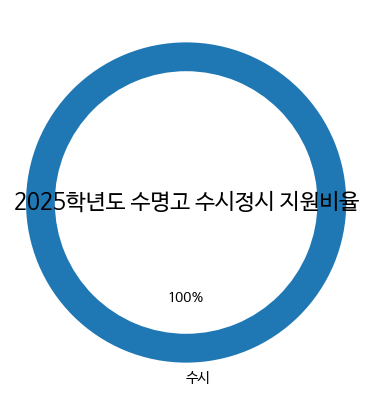

In [ ]:
#7. 수시정시 지원률 도넛차트 그래프

import pandas as pd
import matplotlib.pyplot as plt


##  데이터 부르기
path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')



# 조건에 따라 '지원시기'열의 값 변경
df['지원시기'] = df['지원시기'].replace({'정시(가)': '정시', '정시(나)': '정시', '정시(다)': '정시',
                                       '수시1차': '수시', '수시2차': '수시'})


# '지원시기'별 비율 계산
지원시기_비율 = (df['지원시기'].value_counts(normalize=True) * 100).astype(int)  # 정수로 변환 후 퍼센트로 변환

# ✅ 0%가 된 항목 제거
지원시기_비율 = 지원시기_비율[지원시기_비율 > 0]

labels = 지원시기_비율.index


# '최종' 열의 값이 '합'인 경우는 '합격', '불'인 경우는 '불합격'으로 변경
df['최종'] = df['최종'].apply(lambda x: '합격' if x == '합' else '불합격')


# '합격'과 '불합격'별 비율 계산
최종_비율 = (df['최종'].value_counts(normalize=True) * 100).astype(int)  # 정수로 변환 후 퍼센트로 변환


# '지원시기' 도넛 차트
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.pie(지원시기_비율, labels=labels, autopct='%1.0f%%', startangle=90, colors=plt.cm.tab20.colors, wedgeprops=dict(width=0.18))




# 제목 추가
plt.text(0, 0, '2025학년도 수명고 수시정시 지원비율', fontsize=16, ha='center', va='center')
plt.axis('equal')  # 동그랗게 만들기


plt.show()

=== 원본 '지원시기' 값 확인 ===
지원시기
수시      482
수시1차    195
수시2차     36
Name: count, dtype: int64


=== 변경 후 '지원시기' 값 확인 ===
지원시기
수시_4년제    482
수시_전문대    231
Name: count, dtype: int64


=== 빈도 및 비율 ===
     지원시기   빈도  비율(%)
0  수시_4년제  482     68
1  수시_전문대  231     32

비율 합계: 100%




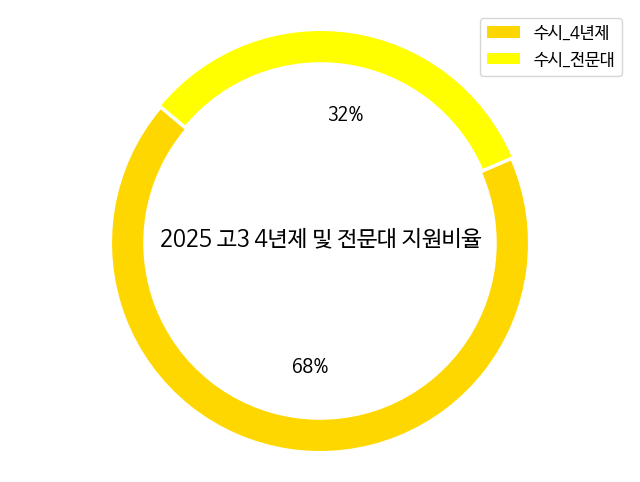

In [ ]:
#8. 수시정시 4년제/전문대 구분 지원비율 도넛차트

import pandas as pd
import matplotlib.pyplot as plt

##  데이터 부르기
path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')

# 디버깅용 출력
print("=== 원본 '지원시기' 값 확인 ===")
print(df['지원시기'].value_counts())
print("\n")

# 조건에 따라 '지원시기'열의 값 변경
df['지원시기'] = df['지원시기'].replace({
    # 정시 관련
    '정시(가)': '정시_4년제',
    '정시(나)': '정시_4년제',
    '정시(다)': '정시_4년제',
    '정시': '정시_전문대',

    # 전문대 수시 관련 (먼저 처리)
    '수시1차': '수시_전문대',
    '수시_1차': '수시_전문대',
    '수시2차': '수시_전문대',
    '수시_2차': '수시_전문대',

    # 4년제 수시 (마지막 처리)
    '수시': '수시_4년제'
})

# 변경 후 확인
print("=== 변경 후 '지원시기' 값 확인 ===")
print(df['지원시기'].value_counts())
print("\n")

# 변경된 '지원시기'열의 값으로 groupby하여 빈도 계산
frequency = df.groupby('지원시기').size().reset_index(name='빈도')

# 🔧 비율 계산 (정수로, 합계 100% 보장)
total = frequency['빈도'].sum()
frequency['비율(%)'] = (frequency['빈도'] / total * 100).round(0).astype(int)


# 반올림으로 인한 오차 보정 (합계가 100이 되도록)
diff = 100 - frequency['비율(%)'].sum()
if diff != 0:
    # 가장 큰 빈도를 가진 항목에 오차 추가
    max_idx = frequency['빈도'].idxmax()
    frequency.loc[max_idx, '비율(%)'] += diff

print("=== 빈도 및 비율 ===")
print(frequency)
print(f"\n비율 합계: {frequency['비율(%)'].sum()}%")
print("\n")

# 데이터프레임에서 '지원시기'와 '빈도' 열 추출
labels = frequency['지원시기']
sizes = frequency['빈도']
#colors = ['gold', 'lightcoral', 'blue', 'lightskyblue']
colors = ['gold', 'yellow', 'lightblue', 'lightskyblue']



# explode 길이 자동 조정
explode = [0.02 if i == 0 else 0 for i in range(len(sizes))]


# 도넛 차트 생성
plt.figure(figsize=(8, 6))
wedges, texts, autotexts = plt.pie(
    sizes,
    explode=explode,
    colors=colors[:len(sizes)],
    autopct='%1.0f%%',  # 🔧 정수로 표시
    startangle=140,
    wedgeprops=dict(width=0.15)
)
plt.axis('equal')

# labels를 도넛 차트 위에 표시
plt.legend(wedges, labels, loc="best", fontsize=12)


# 비율(%)의 글자 크기 확대 및 위치 조정
for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_position((autotext.get_position()[0] - 0.05, autotext.get_position()[1]))
    autotext.set_horizontalalignment('left')

# 제목 추가
plt.text(0, 0, '2025 고3 4년제 및 전문대 지원비율', fontsize=16, ha='center', va='center')

plt.show()

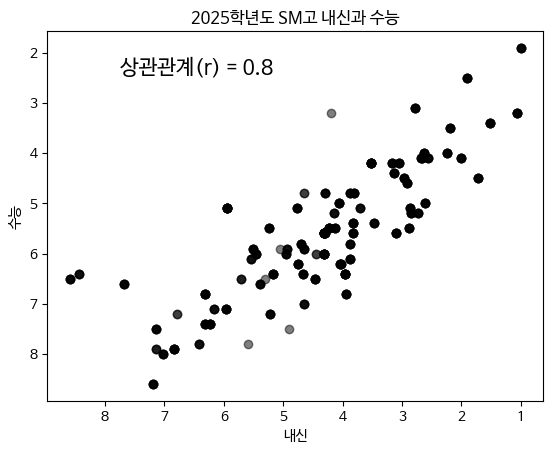

In [ ]:
#9. 내신과 수능과 상관관계A: 산포도

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Drop rows with any NaN values in '전과목' or '등급수능' columns
df = df.dropna(subset=['전과목', '등급수능'])


# Extract '전과목' and '등급수능' columns
x = df['전과목'].values
y = df['등급수능'].values


# Calculate the correlation coefficient
corr_coef = np.corrcoef(x, y)[0, 1]


# Create the scatter plot
plt.scatter(x, y, alpha=0.5,  c='black')
plt.title('2025학년도 SM고 내신과 수능')
plt.xlabel('내신')
plt.ylabel('수능')

# Add the correlation coefficient to the plot
plt.text(0.3, 0.9, f'상관관계(r) = {corr_coef:.1f}',
         horizontalalignment='center', verticalalignment='center',
         transform=plt.gca().transAxes, fontsize=15)

# Reverse the x-axis and y-axis
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()



plt.show()

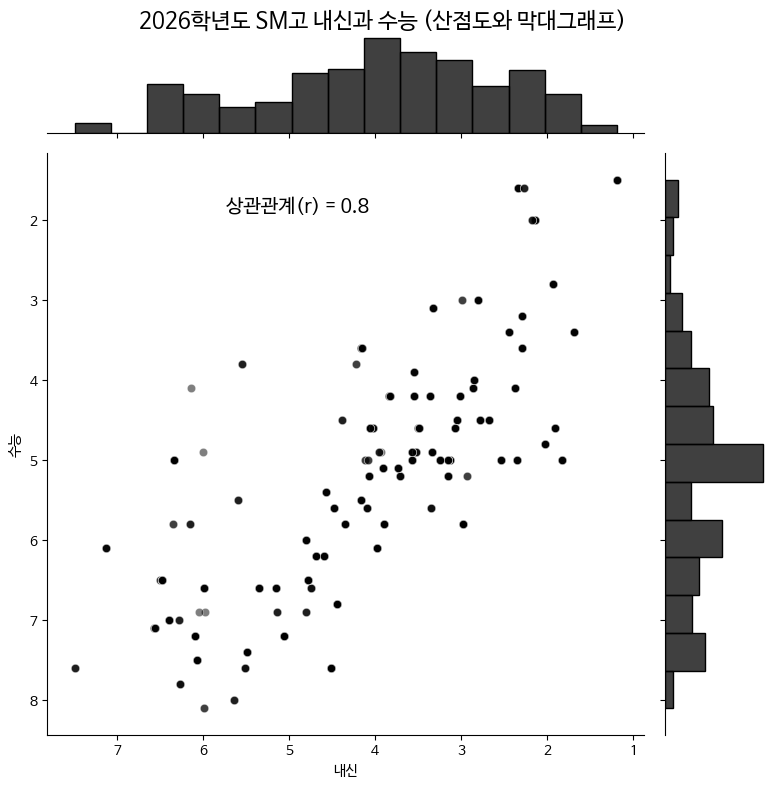

In [ ]:
#9-1 산포도와 막대그래프

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 데이터 전처리
df = df.dropna(subset=['전과목', '등급수능'])
x = df['전과목'].values
y = df['등급수능'].values
corr_coef = np.corrcoef(x, y)[0, 1]

# jointplot: 산점도 + 주변 히스토그램
g = sns.jointplot(
    data=df,
    x='전과목',
    y='등급수능',
    kind='scatter',
    color='black',
    height=8,
    alpha=0.5
)

# 상관계수 텍스트 추가
g.ax_joint.text(
    0.3, 0.9,
    f'상관관계(r) = {corr_coef:.1f}',
    transform=g.ax_joint.transAxes,
    fontsize=14
)

# 축 반전
g.ax_joint.invert_xaxis()
g.ax_joint.invert_yaxis()

# 라벨 및 제목
g.set_axis_labels('내신', '수능')
plt.suptitle('2025학년도 SM고 내신과 수능 (산점도와 막대그래프)', fontsize=16)
plt.subplots_adjust(top=0.95)  # 제목 위치 조정

plt.show()

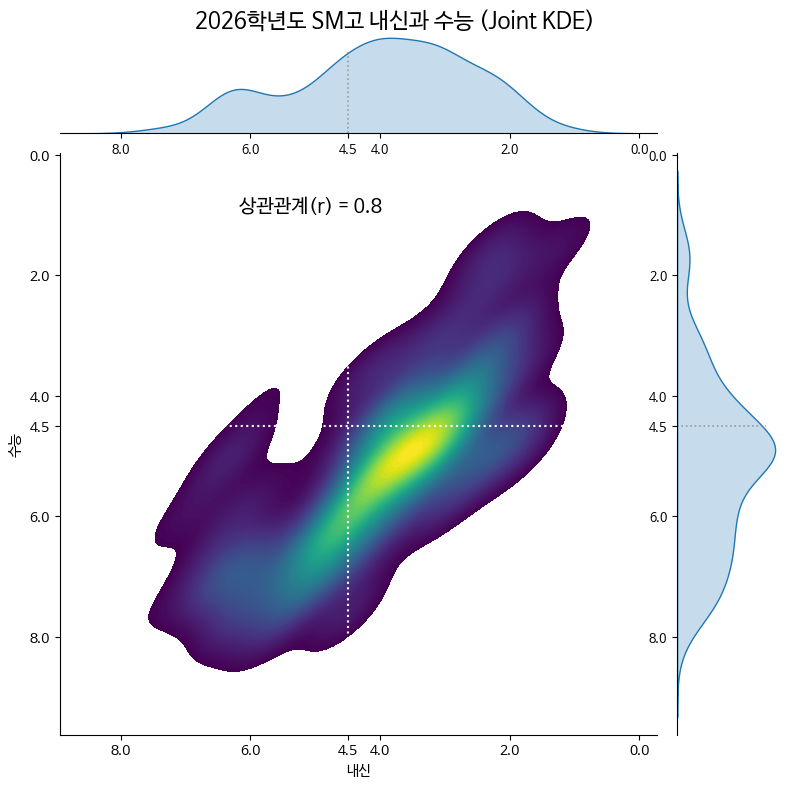

In [ ]:
#9-3 산포도와 정규분포

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

# 데이터 전처리
df = df.dropna(subset=['전과목', '등급수능'])
x = df['전과목'].values
y = df['등급수능'].values
corr_coef = np.corrcoef(x, y)[0, 1]

# jointplot 생성
g = sns.jointplot(
    data=df,
    x='전과목',
    y='등급수능',
    kind='kde',
    fill=True,
    cmap='viridis',
    thresh=0.05,
    levels=100,
    height=8
)

# 상관계수 텍스트 추가
g.ax_joint.text(
    0.3, 0.9,
    f'상관관계(r) = {corr_coef:.1f}',
    transform=g.ax_joint.transAxes,
    fontsize=14
)

# 축 반전
g.ax_joint.invert_xaxis()
g.ax_joint.invert_yaxis()

# 라벨 및 제목 수동 설정
g.set_axis_labels('내신', '수능')
plt.suptitle('2025학년도 SM고 내신과 수능 (Joint KDE)', fontsize=16)
plt.subplots_adjust(top=0.95)

# ── Joint 축 눈금 label 추가 함수 ───────────────────────────────────
def add_tick(ax, value, axis='x'):
    if axis == 'x':
        ticks = list(ax.get_xticks())
        if value not in ticks:
            ticks.append(value)
            ticks.sort()
        ax.set_xticks(ticks)
        ax.set_xticklabels([str(round(t, 1)) for t in ticks])
    else:
        ticks = list(ax.get_yticks())
        if value not in ticks:
            ticks.append(value)
            ticks.sort()
        ax.set_yticks(ticks)
        ax.set_yticklabels([str(round(t, 1)) for t in ticks])

ax = g.ax_joint
add_tick(ax, 4.5, axis='x')
add_tick(ax, 4.5, axis='y')

# ── 주변 분포 축 눈금 label 추가 ─────────────────────────────────────
g.ax_marg_x.xaxis.set_tick_params(labelbottom=True)
x_marg_ticks = list(g.ax_marg_x.get_xticks())
if 4.5 not in x_marg_ticks:
    x_marg_ticks.append(4.5)
    x_marg_ticks.sort()
g.ax_marg_x.set_xticks(x_marg_ticks)
g.ax_marg_x.set_xticklabels([str(round(t, 1)) for t in x_marg_ticks], fontsize=9)

g.ax_marg_y.yaxis.set_tick_params(labelleft=True)
y_marg_ticks = list(g.ax_marg_y.get_yticks())
if 4.5 not in y_marg_ticks:
    y_marg_ticks.append(4.5)
    y_marg_ticks.sort()
g.ax_marg_y.set_yticks(y_marg_ticks)
g.ax_marg_y.set_yticklabels([str(round(t, 1)) for t in y_marg_ticks], fontsize=9)

# ── 결합분포 점선: 데이터 범위 안에서만 ──────────────────────────────
x_data_min, x_data_max = x.min(), x.max()
y_data_min, y_data_max = y.min(), y.max()

line_style = dict(color='white', linestyle=':', linewidth=1.5)
ax.plot([4.5, 4.5], [y_data_min, y_data_max], **line_style)
ax.plot([x_data_min, x_data_max], [4.5, 4.5], **line_style)

# ── 주변 분포 점선: scipy KDE로 4.5 위치 밀도값 계산 후 그 높이까지만 ──

# 상단 분포(ax_marg_x): x=4.5에서의 밀도 높이 계산
kde_x = gaussian_kde(x)
#density_at_45_x = float(kde_x(4.5))
density_at_45_x = float(kde_x(np.array([4.5]))[0])              # 4.5 위치의 밀도값
x_kde_range = np.linspace(x_data_min, x_data_max, 500)
max_density_x = float(kde_x(x_kde_range).max())        # 전체 최대 밀도값

# 밀도 비율로 axes 좌표 변환
marg_x_ylim = g.ax_marg_x.get_ylim()
scale_x = (marg_x_ylim[1] - marg_x_ylim[0]) / max_density_x
line_top_x = marg_x_ylim[0] + density_at_45_x * scale_x  # 4.5 위치의 실제 y좌표

g.ax_marg_x.plot(
    [4.5, 4.5], [marg_x_ylim[0], line_top_x],
    color='gray', linestyle=':', linewidth=1.2, alpha=0.7
)

# 우측 분포(ax_marg_y): y=4.5에서의 밀도 높이 계산
kde_y = gaussian_kde(y)
#density_at_45_y = float(kde_y(4.5))
density_at_45_y = float(kde_y(np.array([4.5]))[0])
y_kde_range = np.linspace(y_data_min, y_data_max, 500)
max_density_y = float(kde_y(y_kde_range).max())

marg_y_xlim = g.ax_marg_y.get_xlim()
scale_y = (marg_y_xlim[1] - marg_y_xlim[0]) / max_density_y
line_right_y = marg_y_xlim[0] + density_at_45_y * scale_y  # 4.5 위치의 실제 x좌표

g.ax_marg_y.plot(
    [marg_y_xlim[0], line_right_y], [4.5, 4.5],
    color='gray', linestyle=':', linewidth=1.2, alpha=0.7
)

plt.show()

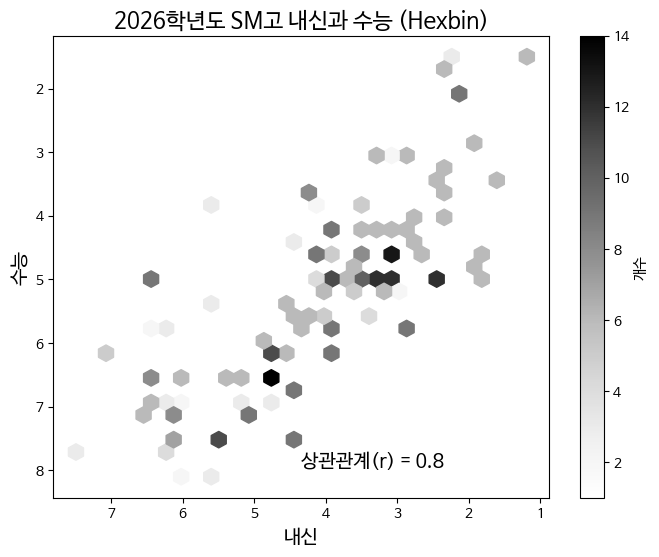

In [ ]:
#9-4. 내신과 수능 상관관계 A: hexbin

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# '전과목'과 '등급수능'에 NaN이 있는 행 제거
df = df.dropna(subset=['전과목', '등급수능'])

# '전과목'과 '등급수능' 데이터 추출
x = df['전과목'].values
y = df['등급수능'].values

# 상관계수 계산
corr_coef = np.corrcoef(x, y)[0, 1]

# hexbin 그래프 그리기
plt.figure(figsize=(8, 6))
hb = plt.hexbin(x, y, gridsize=30, cmap='Greys', mincnt=1)  # mincnt=1: 빈 칸 안 나오게
plt.colorbar(hb, label='개수')  # 색깔에 대응하는 데이터 수 표시
plt.title('2025학년도 SM고 내신과 수능 (Hexbin)', fontsize=16)
plt.xlabel('내신', fontsize=14)
plt.ylabel('수능', fontsize=14)

# 상관계수 추가
plt.text(0.5, 0.1, f'상관관계(r) = {corr_coef:.1f}',
         ha='left', va='top',
         transform=plt.gca().transAxes, fontsize=14)

# x축과 y축 뒤집기
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

# 그래프 저장 경로 설정
path = '/content/drive/MyDrive/python/sumyeong/result_habbul/'
# 저장하려면 주석 해제
# plt.savefig(f'{path}pass_2025_수명고_내신수능_hexbin.png')
# plt.sav


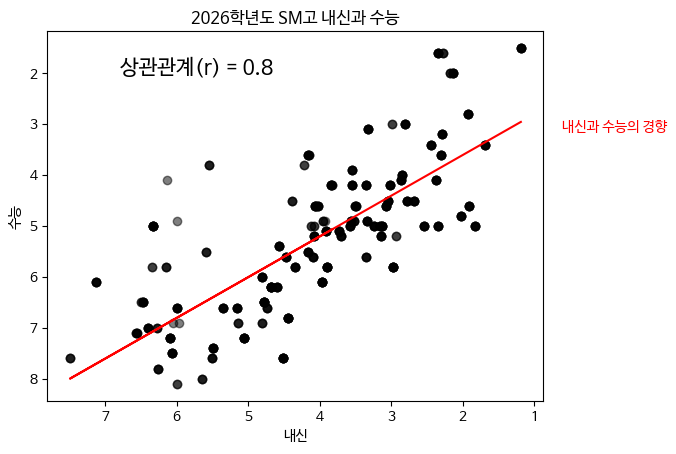

In [ ]:
#9-5. 내신과 수능과 상관관계B: 산포도에 추세선(회귀선) 표시

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Drop rows with any NaN values in '전과목' or '등급수능' columns
df = df.dropna(subset=['전과목', '등급수능'])

# Extract '전과목' and '등급수능' columns
x = df['전과목'].values
y = df['등급수능'].values

# Calculate the correlation coefficient
corr_coef = np.corrcoef(x, y)[0, 1]

# Create the scatter plot
plt.scatter(x, y, alpha=0.5, c='black')
plt.title('2025학년도 SM고 내신과 수능')
plt.xlabel('내신')
plt.ylabel('수능')

# Add the correlation coefficient to the plot
plt.text(0.3, 0.9, f'상관관계(r) = {corr_coef:.1f}',
         horizontalalignment='center', verticalalignment='center',
         transform=plt.gca().transAxes, fontsize=15)

# Reverse the x-axis and y-axis
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

# Calculate linear regression line
m, b = np.polyfit(x, y, 1)
# Add linear regression line to scatter plot
plt.plot(x, m*x + b, color='red')


# Add text for the regression line
plt.text(np.median(x)- 3.3, m*np.median(x) + b - 2, '내신과 수능의 경향', color='red')



plt.show()

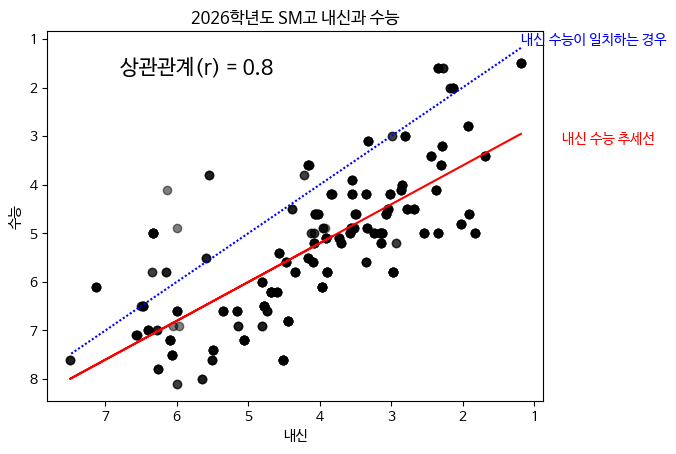

In [ ]:
#9-6. 내신과 수능과 상관관계C: 산포도에 추세선(회귀선)과 1:1대응 직선

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Drop rows with any NaN values in '전과목' or '등급수능' columns
df = df.dropna(subset=['전과목', '등급수능'])

# Extract '전과목' and '등급수능' columns
x = df['전과목'].values
y = df['등급수능'].values

# Calculate the correlation coefficient
corr_coef = np.corrcoef(x, y)[0, 1]

# Create the scatter plot
plt.scatter(x, y, alpha=0.5, c='black')
plt.title('2025학년도 SM고 내신과 수능')
plt.xlabel('내신')
plt.ylabel('수능')

# Add the correlation coefficient to the plot
plt.text(0.3, 0.9, f'상관관계(r) = {corr_coef:.1f}',
         horizontalalignment='center', verticalalignment='center',
         transform=plt.gca().transAxes, fontsize=15)

# Reverse the x-axis and y-axis
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

# Calculate linear regression line
m, b = np.polyfit(x, y, 1)
# Add linear regression line to scatter plot
plt.plot(x, m*x + b, color='red')


# Add text for the regression line
plt.text(np.median(x)- 3.3, m*np.median(x) + b - 2, '내신 수능 추세선', color='red')

# Add a 1:1 line
plt.plot([min(x), max(x)], [min(x), max(x)], color='blue', linestyle='--', dashes=[1, 1]) # 1:1 대응 직선 추가



# Add text for the 1:1 line
plt.text(min(x), min(x), '내신 수능이 일치하는 경우', color='blue', verticalalignment='bottom')


plt.show()


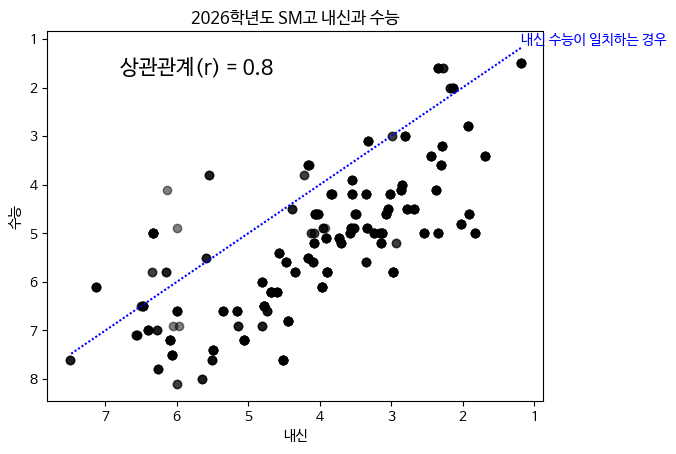

In [ ]:
#9-7. 내신과 수능과 상관관계D: 산포도에 1:1대응 직선

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Drop rows with any NaN values in '전과목' or '등급수능' columns
df = df.dropna(subset=['전과목', '등급수능'])

# Extract '전과목' and '등급수능' columns
x = df['전과목'].values
y = df['등급수능'].values

# Calculate the correlation coefficient
corr_coef = np.corrcoef(x, y)[0, 1]

# Create the scatter plot
plt.scatter(x, y, alpha=0.5, c='black')
plt.title('2025학년도 SM고 내신과 수능')
plt.xlabel('내신')
plt.ylabel('수능')

# Add the correlation coefficient to the plot
plt.text(0.3, 0.9, f'상관관계(r) = {corr_coef:.1f}',
         horizontalalignment='center', verticalalignment='center',
         transform=plt.gca().transAxes, fontsize=15)

# Reverse the x-axis and y-axis
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

# Calculate linear regression line
#m, b = np.polyfit(x, y, 1)
# Add linear regression line to scatter plot
#plt.plot(x, m*x + b, color='red')


# Add text for the regression line
#plt.text(np.median(x)- 3.3, m*np.median(x) + b - 2, '내신 수능 추세선', color='red')

# Add a 1:1 line
plt.plot([min(x), max(x)], [min(x), max(x)], color='blue', linestyle='--', dashes=[1, 1]) # 1:1 대응 직선 추가



# Add text for the 1:1 line
plt.text(min(x), min(x), '내신 수능이 일치하는 경우', color='blue', verticalalignment='bottom')


plt.show()

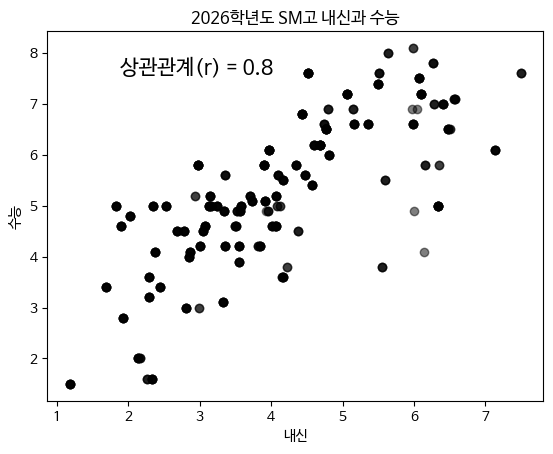

In [ ]:
#9-8 보조자료. 내신과 수능과 상관관계B: 역방향 산포도

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Drop rows with any NaN values in '전과목' or '등급수능' columns
df = df.dropna(subset=['전과목', '등급수능'])


# Extract '전과목' and '등급수능' columns
x = df['전과목'].values
y = df['등급수능'].values


# Calculate the correlation coefficient
corr_coef = np.corrcoef(x, y)[0, 1]


# Create the scatter plot
plt.scatter(x, y, alpha=0.5,  c='black')
plt.title('2025학년도 SM고 내신과 수능')
plt.xlabel('내신')
plt.ylabel('수능')

# Add the correlation coefficient to the plot
plt.text(0.3, 0.9, f'상관관계(r) = {corr_coef:.1f}',
         horizontalalignment='center', verticalalignment='center',
         transform=plt.gca().transAxes, fontsize=15)

# Reverse the x-axis and y-axis
#plt.gca().invert_xaxis()
#plt.gca().invert_yaxis()

plt.show()

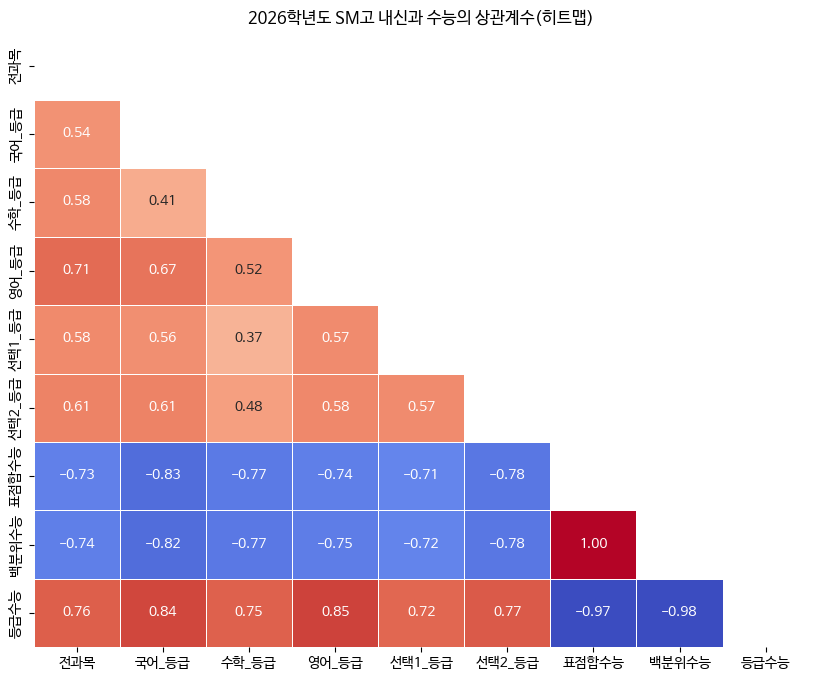

In [ ]:
#10. 내신과 수능과 상관관계(히트맵)


import seaborn as sns

#일부 항목추출
df_heatmap = df[['전과목', '국어_등급', '수학_등급', '영어_등급', '선택1_등급', '선택2_등급', '표점합수능',  '백분위수능',  '등급수능']]


# 상관계수 계산
corr = df_heatmap.corr()



# 대각행렬 오른쪽 부분을 마스킹 (대각선을 포함한 오른쪽 상단 부분을 제외)
mask = np.triu(np.ones_like(corr, dtype=bool))


# 히트맵 그리기
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, mask=mask, cbar=False)
plt.title('2025학년도 SM고 내신과 수능의 상관계수(히트맵)')

path = '/content/drive/MyDrive/python/sumyeong/result_habbul/'
#plt.savefig(f'{path}pass_2025_수명고_히트맵상관계수.png')
#plt.savefig(f'{path}pass_2025_수명고_히트맵상관계수.pdf')

plt.show()

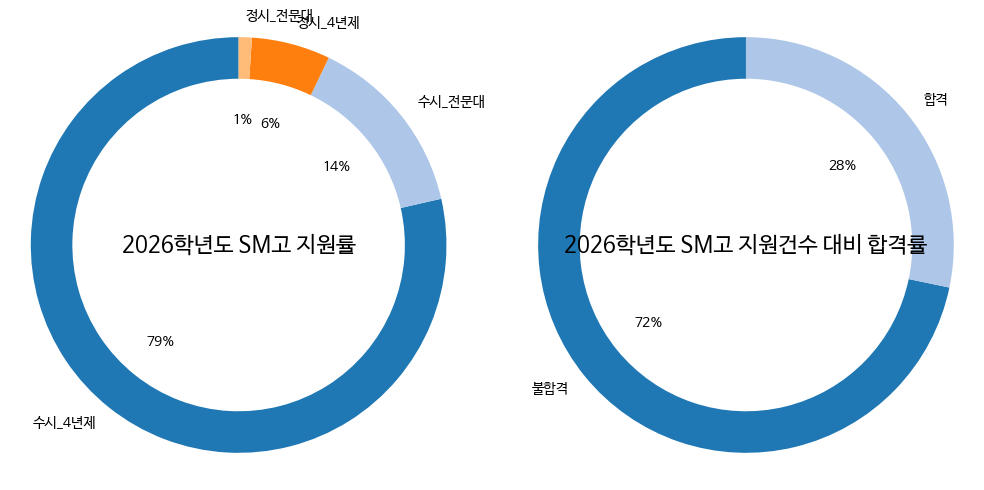

In [ ]:
#11. 수시정시 지원률과 합격률 도넛차트

import pandas as pd
import matplotlib.pyplot as plt


# 조건에 따라 '지원시기'열의 값 변경
df['지원시기'] = df['지원시기'].replace({
    # 정시 관련
    '정시(가)': '정시',
    '정시(나)': '정시',
    '정시(다)': '정시',


    # 전문대 수시 관련 (먼저 처리)
    '수시1차': '수시_전문대',
    '수시_1차': '수시_전문대',
    '수시2차': '수시_전문대',
    '수시_2차': '수시_전문대',

    # 4년제 수시 (마지막 처리)
    '수시': '수시_4년제'
})


# '지원시기'별 비율 계산
지원시기_비율 = (df['지원시기'].value_counts(normalize=True) * 100).astype(int)  # 정수로 변환 후 퍼센트로 변환
labels = 지원시기_비율.index


# '최종' 열의 값이 '합'인 경우는 '합격', '불'인 경우는 '불합격'으로 변경
#df['최종'] = df['최종'].apply(lambda x: '합격' if x == '합' else '불합격')


# '최종' 열의 값을 '합격', '불합격'으로 직접 변경
df['최종'] = df['최종'].replace({'합': '합격', '불': '불합격'})


# '합격'과 '불합격'별 비율 계산
최종_비율 = (df['최종'].value_counts(normalize=True) * 100).astype(int)  # 정수로 변환 후 퍼센트로 변환


# '지원시기' 도넛 차트
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.pie(지원시기_비율, labels=labels, autopct='%1.0f%%', startangle=90, colors=plt.cm.tab20.colors, wedgeprops=dict(width=0.2))
# 제목 추가
plt.text(0, 0, '2025학년도 SM고 지원률', fontsize=16, ha='center', va='center')
plt.axis('equal')  # 동그랗게 만들기



# 지원건수 대비 합격률 도넛 차트
plt.subplot(1, 2, 2)
plt.pie(최종_비율, labels=최종_비율.index, autopct='%1.0f%%', startangle=90, colors=plt.cm.tab20.colors, wedgeprops=dict(width=0.2))
plt.text(0, 0, '2025학년도 SM고 지원건수 대비 합격률', fontsize=16, ha='center', va='center')
plt.axis('equal')  # 동그랗게 만들기

plt.tight_layout()  # subplot 간 간격 조절


plt.show()

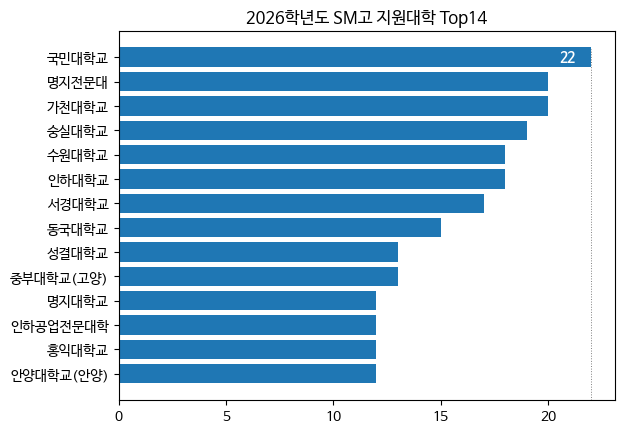

In [ ]:
#12. 지원대학 막대그래프

import pandas as pd
import matplotlib.pyplot as plt


# 데이터 불러오기
path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')


# Filter the rows based on the frequency of the "대학" column
freq = df['대학'].value_counts()
freq = freq[freq >= 12]

# 대학수
freq_num = len(freq)

# Create a horizontal bar plot with descending order
freq_sorted = freq.sort_values()
plt.barh(freq_sorted.index, freq_sorted)



# Draw a dotted vertical line only from the X-axis tick with maximum value of the plot
max_value = max(freq_sorted)
plt.axvline(max_value, linestyle=':', color='gray', linewidth=0.7, ymax=0.95)  # 아래쪽 x축까지 선이 도달하도록 ymax 설정



# Annotate the maximum value on the plot
plt.text(max_value - 1.5, len(freq_sorted) - 1, f'{max_value}', color='white', fontsize=10, va='center', fontweight='bold')



plt.title(f"2025학년도 SM고 지원대학 Top{freq_num}")
#plt.savefig(f'{path1}2025uni_preferred.png', dpi=300, bbox_inches='tight')
#plt.savefig(f'{path1}2025uni_preferred.pdf', bbox_inches='tight')
plt.show()

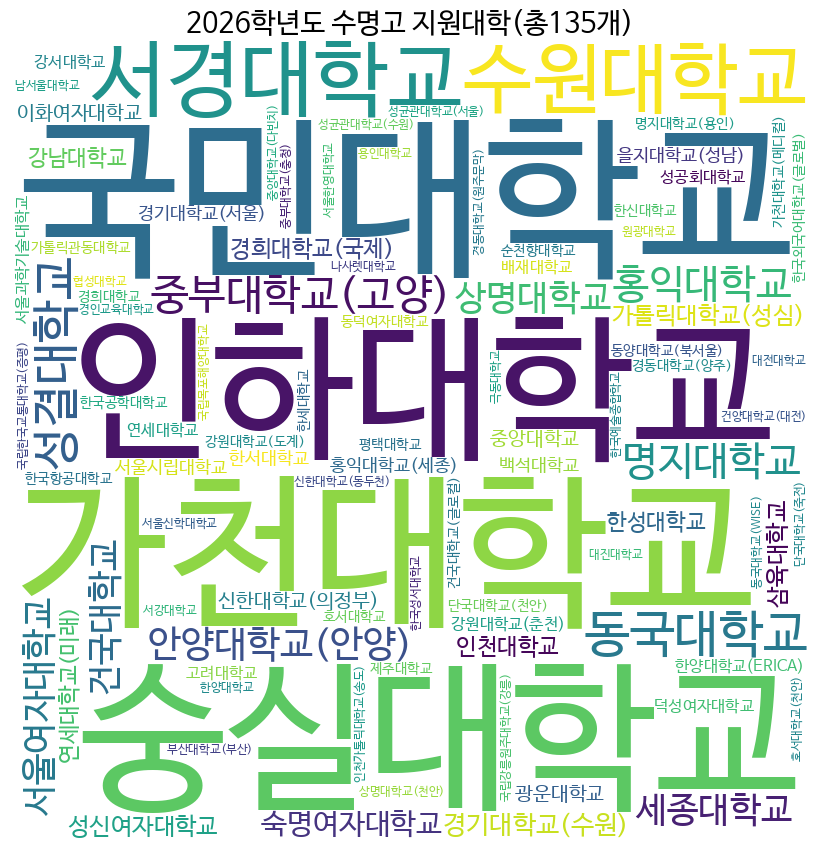

In [ ]:
#13.지원대학 워드클라우드(wordcloud)

import random
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import datetime

# Get the current year
current_year = datetime.datetime.now().year


# Assuming the academic year starts this year and continues into the next year
academic_year = f"{current_year}학년도"


#지원시기: 수시
df_apply = df[df.지원시기  == '수시']



#중복제외한 대학수
df_dup = df_apply.drop_duplicates('대학')
df_freq = len(df_dup['대학'])



#결과를 하나로 고정
random.seed(42)  # set the random seed



wordcloud = WordCloud(font_path='NanumBarunGothic', width=800, height=800, background_color='white', min_font_size=10).generate_from_frequencies(df_apply['대학'].value_counts())


fig = plt.figure(figsize=(8, 8))
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)


# Now update the title string to include the current academic year
plt.title(f"{academic_year} 수명고 지원대학(총{df_freq}개)", fontsize=20)

path = '/content/drive/MyDrive/python/sumyeong/'
pdf_path = f'{path}2025학년도_수명고_wordcloud.pdf'
plt.savefig(pdf_path, dpi=300, bbox_inches='tight', pad_inches=0)

wordcloud.to_file(f'{path}202학년도_수명고_wordcloud.png')

plt.show()

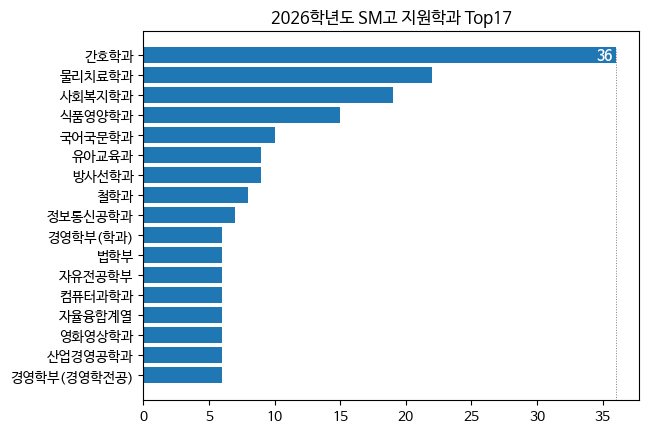

In [ ]:
#14. 지원학과 막대그래프(가로)

import pandas as pd
import matplotlib.pyplot as plt

# 데이터 불러오기
path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')


# '모집단위' 열에서 '경영학과'와 '경영학부'를 '경영학부(학과)'로 합산
df['모집단위'] = df['모집단위'].replace({'경영학과': '경영학부(학과)', '경영학부': '경영학부(학과)'})

# '모집단위' 열에서 '컴퓨터관련학과' 합산
df['모집단위'] = df['모집단위'].replace({'컴퓨터소프트웨어학과': '컴퓨터과학과', '소프트웨어학과': '컴퓨터과학과',  '컴퓨터공학과': '컴퓨터과학과'})


# '모집단위' 열에서 '국어교육문학' 합산
df['모집단위'] = df['모집단위'].replace({'국어국문문예창작학부': '국어교육문학전공', '국어교육과': '국어교육문학전공'})


# '모집단위' 열에서 '사회복지학과' 합산
df['모집단위'] = df['모집단위'].replace({'사회복지과': '사회복지학과'})


# '모집단위' 열에서 '물리치료과' 합산
df['모집단위'] = df['모집단위'].replace({'물리치료과': '물리치료학과'})



# '모집단위' 열에서 '컴퓨터관련학과' 합산
df['모집단위'] = df['모집단위'].replace({'자유전공': '자유전공학부', '자율설계전공학부': '자유전공학부'})


# Filter the rows based on the frequency of the "대학" column
freq = df['모집단위'].value_counts()
freq = freq[freq >= 6]

# 대학수
freq_num = len(freq)

# Create a horizontal bar plot with descending order
freq_sorted = freq.sort_values()
plt.barh(freq_sorted.index, freq_sorted)



# Draw a dotted vertical line only from the X-axis tick with maximum value of the plot
max_value = max(freq_sorted)
plt.axvline(max_value, linestyle=':', color='gray', linewidth=0.7, ymax=0.95)  # 아래쪽 x축까지 선이 도달하도록 ymax 설정



# Annotate the maximum value on the plot
plt.text(max_value - 1.5, len(freq_sorted) - 1, f'{max_value}', color='white', fontsize=10, va='center', fontweight='bold')



plt.title(f"2025학년도 SM고 지원학과 Top{freq_num}")
plt.show()

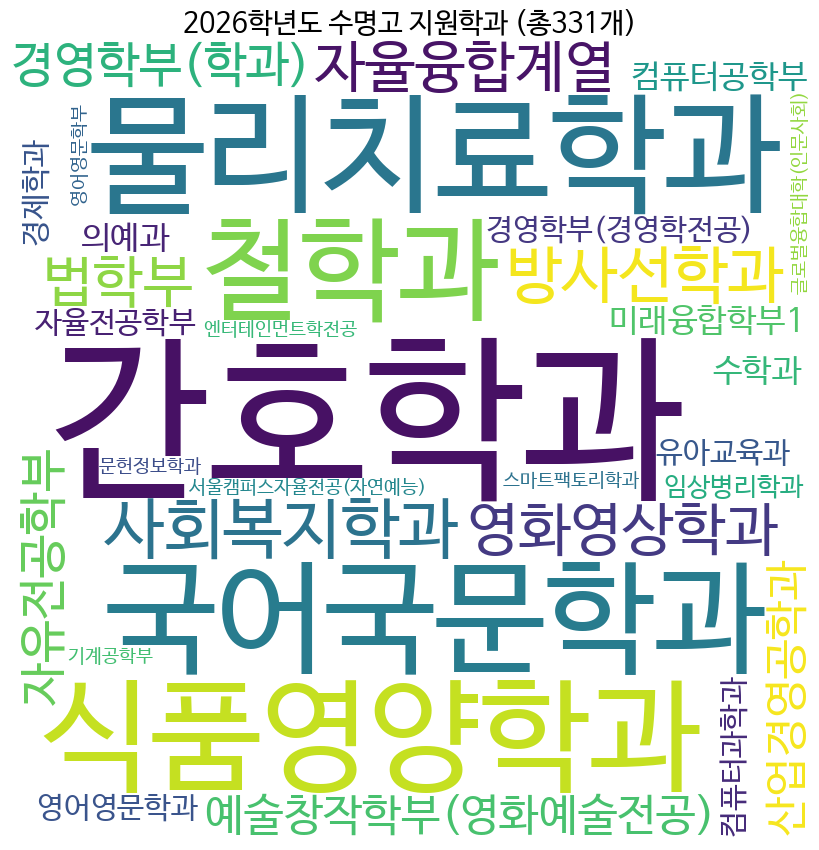

In [ ]:
#15. 지원학과 워드클라우드(wordcloud)

import random
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import datetime

# Get the current year
current_year = datetime.datetime.now().year


# Assuming the academic year starts this year and continues into the next year
academic_year = f"{current_year}학년도"


# '모집단위' 열에서 '경영학과'와 '경영학부'를 '경영학부(학과)'로 합산
df['모집단위'] = df['모집단위'].replace({'경영학과': '경영학부(학과)', '경영학부': '경영학부(학과)'})



# '모집단위' 열에서 '컴퓨터관련학과' 합산
df['모집단위'] = df['모집단위'].replace({'컴퓨터소프트웨어학과': '컴퓨터과학과', '소프트웨어학과': '컴퓨터과학과',  '컴퓨터공학과': '컴퓨터과학과'})



# '모집단위' 열에서 '국어교육문학' 합산
df['모집단위'] = df['모집단위'].replace({'국어국문문예창작학부': '국어교육문학전공', '국어교육과': '국어교육문학전공'})


# '모집단위' 열에서 '사회복지학과' 합산
df['모집단위'] = df['모집단위'].replace({'사회복지과': '사회복지학과'})


# '모집단위' 열에서 '물리치료과' 합산
df['모집단위'] = df['모집단위'].replace({'물리치료과': '물리치료학과'})



# '모집단위' 열에서 '컴퓨터관련학과' 합산
df['모집단위'] = df['모집단위'].replace({'자유전공': '자유전공학부', '자율설계전공학부': '자유전공학부'})



#지원시기: 수시
df_apply = df[df.지원시기  == '수시']


#중복제외한 대학수
df_dup = df_apply.drop_duplicates('모집단위')
df_freq = len(df_dup['모집단위'])



#결과를 하나로 고정
random.seed(42)  # set the random seed



wordcloud = WordCloud(font_path='NanumBarunGothic', width=800, height=800, background_color='white', min_font_size=10).generate_from_frequencies(df_apply['모집단위'].value_counts())


fig = plt.figure(figsize=(8, 8))
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)


# Now update the title string to include the current academic year
plt.title(f"{academic_year} 수명고 지원학과 (총{df_freq}개)", fontsize=20)

path = '/content/drive/MyDrive/python/sumyeong/result_wordcloud/'
pdf_path = f'{path}202학년도_수명고_wordcloud.pdf'
#plt.savefig(pdf_path, dpi=300, bbox_inches='tight', pad_inches=0)

wordcloud.to_file(f'{path}202학년도_수명고_지원학과wordcloud.png')

plt.show()

In [ ]:
#16. 반별 4년제 합격자 명단

from tabulate import tabulate

path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')


#4년제 지원자수(중복포함)
seoul_df_fouryearapply = df[~(df.대학.str.contains("대학교"))]
seoul_df_fouryearapply = len(seoul_df_fouryearapply)

#지역, 최종, ace대학 제외
seoul_df = df[(df.최종 == '합') & ~(df.대학.str.contains("대학교"))]


#4년제 합격건수(중복포함)
seoul_df_freq = len(seoul_df)


#4년제 합격률 = 4년제 합격건수 / 4년제 지원자수
seoul_df_fouryearpass = (seoul_df_freq / seoul_df_fouryearapply) *100
seoul_df_fouryearpass = int(seoul_df_fouryearpass)

#필요한 변수(열)만 불러옴
seoul_df = seoul_df[['지역', '학번', '계열', '이름', '대학', '모집단위', '최종', '전과목', '지원시기', '전형분류']]



#중복제외한 합격자수
seoul_df_person = seoul_df.drop_duplicates('이름')


# tabulate를 사용하여 결과 출력
print(tabulate(seoul_df, headers='keys', tablefmt='plain', showindex=False))
print("********************************************************************")



#합격자수
print("2025학년도 SM고 4년제 대학 합격건수는 %d건입니다.(중복합격 포함)" % len(seoul_df))

print("2025학년도 SM고 4년제 대학 합격자수는 %d명입니다.(중복제외)" % len(seoul_df_person))


print(f"2025학년도 SM고 4년제 대학 합격률은 {seoul_df_fouryearpass}%입니다.(중복포함)")


#데이터 프레임으로 전환
seoul_df_p = pd.DataFrame(seoul_df)


#결과를 엑셀로 저장
path = '/content/drive/MyDrive/python/sumyeong/'
seoul_df_p.to_excel(excel_writer= f'{path}반별4년제합격자_2026_수명고.xlsx')

In [ ]:
#17. 4년제대 합격자 명단

import pandas as pd
from tabulate import tabulate

path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')



#4년제 지원자수(중복포함)
#seoul_df_fouryearapply = df[~(df.대학.str.contains("대학교"))]
#seoul_df_fouryearapply = len(seoul_df_fouryearapply)


# 지역, 최종, 특정 대학 제외
exclude_universities = ["대학교", "명지전문", "인하공업", "한국폴리텍"]
seoul_df = df[(df.최종 == '합') & ~df.대학.str.contains("|".join(exclude_universities))]



#4년제 합격건수(중복포함)
seoul_df_freq = len(seoul_df)



#필요한 변수(열)만 불러옴
seoul_df = seoul_df[['지역', '학번', '계열', '이름', '대학', '모집단위', '최종', '전과목', '지원시기', '전형분류']]



#중복제외한 합격자수
seoul_df_person = seoul_df.drop_duplicates('이름')
seoul_df_person = len(seoul_df_person)



#졸업생대비 4년제 합격률 = 4년제 합격자 / 졸업생수(147)
numofgraduate = 147
seoul_df_fouryearpass = (seoul_df_person / numofgraduate) *100
seoul_df_fouryearpass = int(seoul_df_fouryearpass)



#합격자수
print("202학년도 SM고 4년제 합격건수는 %d건입니다.(중복합격 포함)" % len(seoul_df))

print(f"202학년도 SM고 4년제 합격자수는 {seoul_df_person}명입니다.(중복제외)")


print(f"202학년도 SM고 4년제 졸업생 대비 합격률은 {seoul_df_fouryearpass}%입니다.(중복포함)")

# tabulate를 사용하여 결과 출력
print(tabulate(seoul_df, headers='keys', tablefmt='plain', showindex=False))
print("********************************************************************")



In [ ]:
#18. 수도권(서울, 경기, 인천) 4년제 합격자 명단

from tabulate import tabulate

path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')


area = ['서울', '경기', '인천']

#전문대 제외
exclude_techschool = ['수시1차', '수시2차']


#4년제 지원자수(중복포함) - 전문대 제외
seoul_df_fouryearapply = df[~(df['대학'].str.contains("|".join(exclude_techschool)))]
seoul_df_fouryearapply = len(seoul_df_fouryearapply)



seoul_df = seoul_df[seoul_df['지역'].isin(area)]


#4년제 합격건수(중복포함)
seoul_df_freq = len(seoul_df)



#필요한 변수(열)만 불러옴
seoul_df = seoul_df[['지역', '학번', '계열', '이름', '대학', '모집단위', '최종', '전과목', '지원시기', '전형분류']]



#중복제외한 합격자수
seoul_df_person = seoul_df.drop_duplicates('이름')
seoul_df_person = len(seoul_df_person)



#4년제 합격률 = 4년제 합격자 / 졸업생수(147)
numofgraduate = 147
seoul_df_fouryearpass = (seoul_df_person / numofgraduate) *100
seoul_df_fouryearpass = int(seoul_df_fouryearpass)



#합격자수
print("2025학년도 SM고 4년제 수도권대 합격건수는 %d건입니다.(중복합격 포함)" % len(seoul_df))

print(f"2025학년도 SM고 4년제 수도권대 합격자수는 {seoul_df_person}명입니다.(중복제외)")


print(f"2025학년도 SM고 4년제 수도권대 학생대비 합격률은 {seoul_df_fouryearpass}%입니다.(중복포함)")

# tabulate를 사용하여 결과 출력
print(tabulate(seoul_df, headers='keys', tablefmt='plain', showindex=False))
print("********************************************************************")


#데이터 프레임으로 전환
seoul_df_p = pd.DataFrame(seoul_df)


#결과를 엑셀로 저장
path = '/content/drive/MyDrive/python/sumyeong/'
seoul_df_p.to_excel(excel_writer= f'{path}수도권전문대합격자_2026_수명고.xlsx')

2026학년도 SM고 4년제 수도권대 합격건수는 46건입니다.(중복합격 포함)
2026학년도 SM고 4년제 수도권대 합격자수는 30명입니다.(중복제외)
2026학년도 SM고 4년제 수도권대 학생대비 합격률은 20%입니다.(중복포함)
지역      학번  계열    이름    대학                모집단위                                  최종      전과목  지원시기    전형분류
서울     30101  예체능  강현우  서경대학교          스포츠앤테크놀로지학과                    합         6.633  수시        실기
서울     30105  예체능  김예린  서경대학교          광고홍보영상학과                          합         3.972  수시        실기
서울     30114  인문    백지수  이화여자대학교      심리학과                                  합         1.689  수시        교과
서울     30115  인문    부혜원  국민대학교          국제통상학과                              합         2.443  수시        교과
서울     30115  인문    부혜원  명지대학교          경영학부(경영학전공)                      합         2.443  수시        교과
서울     30116  자연    송승한  동국대학교          컴퓨터AI학부                              합         1.83   수시        교과
서울     30116  자연    송승한  숭실대학교          컴퓨터학부                                합         1.83   수시        교과
서울     30121  예체능  윤도현  한국예술종합학교

In [ ]:
#19. 수도권(서울, 경기, 인천) 4년제 합격자 명단

from tabulate import tabulate

path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')

area = ['서울', '경기', '인천']

# 졸업생 수 자동 계산 (전체 데이터에서 이름 중복 제외)
numofgraduate = df['이름'].drop_duplicates().count()

#4년제 지원자수(중복포함)
seoul_df_fouryearapply = df[~(df.대학.str.contains("대학교", na=False))]
seoul_df_fouryearapply = len(seoul_df_fouryearapply)

# 지역, 최종, 특정 대학 제외
exclude_universities = ["대학교", "명지전문", "인하공업", "한국폴리텍"]
seoul_df = df[(df.최종 == '합') & ~df.대학.str.contains("|".join(exclude_universities), na=False)]

seoul_df = seoul_df[seoul_df['지역'].isin(area)]

#4년제 합격건수(중복포함)
seoul_df_freq = len(seoul_df)

#필요한 변수(열)만 불러옴
seoul_df = seoul_df[['지역', '학번', '계열', '이름', '대학', '모집단위', '최종', '전과목', '지원시기', '전형분류']]

#중복제외한 합격자수
seoul_df_person = seoul_df.drop_duplicates('이름')
seoul_df_person_count = len(seoul_df_person)

#4년제 합격률 = 4년제 합격자 / 졸업생수
seoul_df_fouryearpass = (seoul_df_person_count / numofgraduate) * 100
seoul_df_fouryearpass = int(seoul_df_fouryearpass)

#합격자수
print(f"졸업생 수: {numofgraduate}명")
print(f"2025학년도 SM고 4년제 수도권대 합격건수는 {len(seoul_df)}건입니다.(중복합격 포함)")
print(f"2025학년도 SM고 4년제 수도권대 합격자수는 {seoul_df_person_count}명입니다.(중복제외)")
print(f"2025학년도 SM고 4년제 수도권대 졸업생 대비 합격률은 {seoul_df_fouryearpass}%입니다.(중복제외)")

# tabulate를 사용하여 결과 출력
print(tabulate(seoul_df, headers='keys', tablefmt='plain', showindex=False))
print("********************************************************************")

#데이터 프레임으로 전환
seoul_df_p = pd.DataFrame(seoul_df)

#결과를 엑셀로 저장
path = '/content/drive/MyDrive/python/sumyeong/'
seoul_df_p.to_excel(excel_writer= f'{path}수도권전문대합격자_2026_수명고.xlsx')

In [ ]:
#지원시기 빈도수 계산

df_freq = df['지원시기'].value_counts()
df_freq

,count
지원시기,
수시,566
수시1차,151
수시2차,22
정시(가),12
정시(나),11
정시(다),10
정시,9


In [ ]:
#20. 전문대 합격자 명단

from tabulate import tabulate

path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')

area = ['서울', '경기', '인천']


# 지역, 최종, 특정 대학 포함
exclude_universities = ["수시1차", "수시2차"]
seoul_df = df[(df.최종 == '합') & df['지원시기'].str.contains("|".join(exclude_universities))]

#'정시'인 전문대 제외
seoul_df = seoul_df[~(seoul_df['지원시기'] == '정시')]



#4년제 합격건수(중복포함)
seoul_df_freq = len(seoul_df)



#필요한 변수(열)만 불러옴
seoul_df = seoul_df[['지역', '학번', '계열', '이름', '대학', '모집단위', '최종', '전과목', '지원시기', '전형분류']]



#중복제외한 합격자수
seoul_df_person = seoul_df.drop_duplicates('이름')
seoul_df_person = len(seoul_df_person)



#졸업생대비 4년제 합격률 = 4년제 합격자 / 졸업생수(147)
numofgraduate = 147
seoul_df_fouryearpass = (seoul_df_person / numofgraduate) *100
seoul_df_fouryearpass = int(seoul_df_fouryearpass)



#합격자수
print("202학년도 SM고 전문대 합격건수는 %d건입니다.(중복합격 포함)" % len(seoul_df))

print(f"202학년도 SM고 전문대 합격자수는 {seoul_df_person}명입니다.(중복제외)")


print(f"202학년도 SM고 전문대 졸업생 대비 합격률은 {seoul_df_fouryearpass}%입니다.(중복포함)")

# tabulate를 사용하여 결과 출력
print(tabulate(seoul_df, headers='keys', tablefmt='plain', showindex=False))
print("********************************************************************")

202학년도 SM고 전문대 합격건수는 83건입니다.(중복합격 포함)
202학년도 SM고 전문대 합격자수는 36명입니다.(중복제외)
202학년도 SM고 전문대 졸업생 대비 합격률은 24%입니다.(중복포함)
지역      학번  계열    이름    대학                모집단위                                       최종      전과목  지원시기    전형분류
충남     30628  자연    김규빈  아주자동차대학      미래자동차공학부                               합         8.118  수시1차     교과
충남     30626  예체능  한준서  백석문화대학교      실용음악학과 기악전공                          합         7.028  수시1차     실기
인천     30626  예체능  한준서  인천재능대학교      실용음악과                                     합         7.028  수시1차     실기
인천     30625  자연    최연희  인하공업전문대학    화학생명공학과                                 합         3.073  수시2차     교과
경기     30623  예체능  조채원  동서울대            메타버스게임애니메이션과                       합         6.936  수시1차     교과
경기     30617  예체능  이현빈  대림대              방송음향기술과                                 합         6.53   수시1차     학생부
경기     30617  예체능  이현빈  유한대학교          실내건축전공                                   합         6.53   수시1차     교과
서울     30617  자연    이현빈  동양미

In [ ]:
#18. 인서울 4년제 합격자 명단

from tabulate import tabulate

path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')

area = ['서울']

exclude_apply = ["수시1차", "수시2차"]

# 모든 필터링을 한 번에 적용
seoul_df = df[
    (df['최종'] == '합') &  # 최종 합격만
    (df['지역'].isin(area)) &  # 인서울만
    (~df['지원시기'].str.contains("|".join(exclude_apply), na=False))]


#'정시'인 전문대 제외
seoul_df = seoul_df[~(seoul_df['지원시기'] == '정시')]


# 4년제 합격건수(중복포함)
seoul_df_freq = len(seoul_df)

# 필요한 변수(열)만 불러옴
seoul_df = seoul_df[['지역', '학번', '계열', '이름', '대학', '모집단위', '최종', '전과목', '지원시기', '전형분류', '백분위수능']]

# 중복제외한 합격자수
seoul_df_person = seoul_df.drop_duplicates('이름')
seoul_df_person_count = len(seoul_df_person)

# 졸업생대비 4년제 합격률
numofgraduate = 147
seoul_df_fouryearpass = int((seoul_df_person_count / numofgraduate) * 100)

# 결과 출력
print(f"2025학년도 SM고 인서울 4년제 합격건수는 {len(seoul_df)}건입니다.(중복합격 포함)")
print(f"2025학년도 SM고 인서울 4년제 합격자수는 {seoul_df_person_count}명입니다.(중복제외)")
print(f"2025학년도 SM고 인서울 4년제 졸업생 대비 합격률은 {seoul_df_fouryearpass}%입니다.(중복제외)")
print(tabulate(seoul_df, headers='keys', tablefmt='plain', showindex=False))
print("********************************************************************")

2026학년도 SM고 인서울 4년제 합격건수는 53건입니다.(중복합격 포함)
2026학년도 SM고 인서울 4년제 합격자수는 33명입니다.(중복제외)
2026학년도 SM고 인서울 4년제 졸업생 대비 합격률은 22%입니다.(중복제외)
지역      학번  계열    이름    대학                모집단위                                  최종      전과목  지원시기    전형분류      백분위수능
서울     30625  인문    최연희  국민대학교          영어영문학부                              합         3.073  수시        종합                54.7
서울     30624  공통    주민규  서경대학교          미래융합학부1                             합         3.117  수시        교과               nan
서울     30613  자연    이시연  서울여자대학교      데이터사이언스학과                        합         3.146  수시        종합                32.5
서울     30609  인문    노유솜  연세대학교          문헌정보학과                              합         2.984  정시(가)    수능                79.7
서울     30605  공통    김은서  명지대학교          자율전공학부(인문)                        합         2.183  수시        교과               nan
서울     30605  인문    김은서  동국대학교          일본학과                                  합         2.183  수시        교과               nan
서울     306

In [ ]:
#19. 지방 4년제 합격자 명단

from tabulate import tabulate

path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')

area = ['서울', '경기', '인천']


#4년제 지원자수(중복포함)
local_df_fouryearapply = df[~(df.대학.str.contains("대학교"))]
local_df_fouryearapply = len(local_df_fouryearapply)

#지역, 최종, ace대학 제외
local_df = df[(df.최종 == '합') & ~(df.대학.str.contains("대학교")) & ~(df.대학.str.contains("전문대"))]

local_df = local_df[~local_df['지역'].isin(area)]


#4년제 합격건수(중복포함)
local_df_freq = len(seoul_df)



#필요한 변수(열)만 불러옴
local_df = local_df[['지역', '학번', '계열', '이름', '대학', '모집단위', '최종', '전과목', '지원시기', '전형분류']]



#중복제외한 합격자수
local_df_person = local_df.drop_duplicates('이름')
local_df_person = len(local_df_person)



#졸업생대비 4년제 합격률 = 4년제 합격자 / 졸업생수(147)
numofgraduate = 147
local_df_fouryearpass = (local_df_person / numofgraduate) *100
local_df_fouryearpass = int(local_df_fouryearpass)



#합격자수
print("2025학년도 SM고 4년제 지방 합격건수는 %d건입니다.(중복합격 포함)" % len(seoul_df))

print(f"2025학년도 SM고 4년제  지방 합격자수는 {local_df_person}명입니다.(중복제외)")


print(f"2025학년도 SM고 4년제 지방 졸업생 대비 합격률은 {local_df_fouryearpass}%입니다.(중복포함)")

# tabulate를 사용하여 결과 출력
print(tabulate(local_df, headers='keys', tablefmt='plain', showindex=False))
print("********************************************************************")


#데이터 프레임으로 전환
seoul_df_p = pd.DataFrame(local_df)


2026학년도 SM고 4년제 지방 합격건수는 32건입니다.(중복합격 포함)
2026학년도 SM고 4년제  지방 합격자수는 2명입니다.(중복제외)
2026학년도 SM고 4년제 지방 졸업생 대비 합격률은 1%입니다.(중복포함)
지역      학번  계열    이름    대학                   모집단위            최종      전과목  지원시기    전형분류
대전     30128  자연    채민규  한국과학기술원(KAIST)  반도체시스템공학과  합         1.764  수시        종합
충남     30628  자연    김규빈  아주자동차대학         미래자동차공학부    합         8.118  수시1차     교과
********************************************************************


In [ ]:
#20. 4년제 합격자 명단A: 선호대학 순

import pandas as pd
from tabulate import tabulate




exclude_apply = ["수시1차", "수시2차"]


# 지역, 최종, ace대학 제외
uni4 = df[(df.최종 == '합') & (~df['지원시기'].str.contains("|".join(exclude_apply), na=False))]

# 필요한 변수(열)만 불러옴
uni4 = uni4[['지역', '이름', '대학', '모집단위', '최종', '전과목', '지원시기', '전형분류', '표점합수능', '백분위수능']]


uni4['전과목'] = uni4['전과목'].round(2)

# NaN 값을 '졸업생'으로 변경
uni4['전과목'].fillna('졸업생', inplace=True)



# 결과를 출력할 순서대로 정렬


output_order = ['서울대학교', '연세대학교', '고려대학교', '한국과학기술원(KAIST)', '서강대학교', '성균관대학교', '한양대학교', '중앙대학교', '경희대학교',
       '한국외대학교', '서울시립대학교', '이화여자대학교', '건국대학교', '동국대학교', '홍익대학교', '숙명여자대학교',
       '국민대학교', '숭실대학교', '세종대학교', '서울과학기술대학교', '단국대학교', '광운대학교', '명지대학교', '상명대학교', '가천대학교(글로벌)', '가톨릭대학교(성심)',
       '한국예술종합학교', '한성대학교', '서경대학교', '삼육대학교',  '성신여자대학교', '서울여자대학교', '덕성여자대학교', '아주대학교', '인하대학교', '한양대학교(에리카)']




uni4 = uni4.sort_values(by=['대학', '모집단위'], key=lambda x: x.map({v: i for i, v in enumerate(output_order)}))

# tabulate를 사용하여 결과 출력
print(tabulate(uni4, headers='keys', tablefmt='plain', showindex=False))
print("********************************************************************")

# 합격자수
print("202학년도 수명고 대학 합격자수는 %d건입니다.(중복합격 포함)" % len(uni4))

# 데이터 프레임으로 전환
uni4_p = pd.DataFrame(uni4)

# 결과를 엑셀로 저장
path = '/content/drive/MyDrive/python/sumyeong/'
uni4_p.to_excel(excel_writer=f'{path}선호대학순_2026_수명고_실명.xlsx')

/tmp/ipython-input-1957345555.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  uni4['전과목'].fillna('졸업생', inplace=True)


지역    이름    대학                      모집단위                                                                  최종      전과목  지원시기    전형분류      표점합수능    백분위수능
서울    노유솜  연세대학교                문헌정보학과                                                              합          2.98  정시(가)    수능                 361          79.7
서울    이가인  연세대학교                전기전자공학부                                                            합          1.18  수시        교과                 392          93.2
서울    장윤정  고려대학교                서어서문학과                                                              합          2.27  정시(가)    수능                 391          95
대전    채민규  한국과학기술원(KAIST)     반도체시스템공학과                                                        합          1.76  수시        종합                   0         nan
서울    장윤정  성균관대학교              인문과학계열                                                              합          2.27  정시(나)    수능                 391          95
서울    장윤정  중앙대학교                경영학부(경영학전공) 

In [ ]:
#20-1. 4년제대 합격자 명단A: 선호대학 순 - 게시용 익명

from tabulate import tabulate


##  데이터 부르기
path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')




# 전문대제외한 합격자
exclude_apply = ["수시1차", "수시2차"]
uni4 = df[(df.최종 == '합') & (~df['지원시기'].str.contains("|".join(exclude_apply), na=False))]



# 필요한 변수(열)만 불러옴
uni4 = uni4[['이름', '지역', '대학', '모집단위', '최종', '전과목', '전형분류', '전형명', '전형방법']]

uni4['전과목'] = uni4['전과목'].round(2)


# Show first one letter and replace the rest of the letters with an asterisk in '이름' column
uni4['이름'] = uni4['이름'].apply(lambda x: x[:1] + 'O' * (len(x) - 1) if len(x) >= 2 else x)


# 결과를 출력할 순서대로 정렬

output_order = ['서울대학교', '연세대학교', '고려대학교', '한국과학기술원(KAIST)', '서강대학교', '성균관대학교', '한양대학교', '중앙대학교', '경희대학교',
       '한국외대학교', '서울시립대학교', '이화여자대학교', '건국대학교', '동국대학교', '홍익대학교', '숙명여자대학교',
       '국민대학교', '숭실대학교', '세종대학교', '서울과학기술대학교', '단국대학교', '광운대학교', '명지대학교', '상명대학교', '가천대학교(글로벌)', '가톨릭대학교(성심)',
       '한국예술종합학교', '한성대학교', '서경대학교', '삼육대학교',  '성신여자대학교', '서울여자대학교', '덕성여자대학교', '아주대학교', '인하대학교', '한양대학교(에리카)']



#uni4 = uni4.sort_values(by=['대학', '모집단위'], key=lambda x: x.map({v: i for i, v in enumerate(output_order)}))
uni4 = uni4.sort_values(by=['대학'], key=lambda x: x.map({v: i for i, v in enumerate(output_order)}))


# tabulate를 사용하여 결과 출력
print(tabulate(uni4, headers='keys', tablefmt='plain', showindex=False))
print("********************************************************************")

# 합격자수
print("202학년도 수명고 대학 합격자수는 %d건입니다.(중복포함)" % len(uni4))

# 데이터 프레임으로 전환
uni4_p = pd.DataFrame(uni4)

# 결과를 엑셀로 저장
path = '/content/drive/MyDrive/python/sumyeong/'
uni4_p.to_excel(excel_writer=f'{path}합격자익명_2025학년도_수명고_uniorder_anonymous.xlsx')


이름    지역    대학                      모집단위                                                                  최종      전과목  전형분류    전형명                                                전형방법
이OO    서울    연세대학교                전기전자공학부                                                            합          1.18  교과        추천형                                                학생부 100%
채OO    대전    한국과학기술원(KAIST)     반도체시스템공학과                                                        합          1.76  종합        반도체시스템인재전형Ⅰ                                 서류100
백OO    서울    이화여자대학교            심리학과                                                                  합          1.69  교과        고교추천전형                                          학생부 100%
송OO    서울    동국대학교                컴퓨터AI학부                                                              합          1.83  교과        학교장추천인재                                        학생부 70% + 서류 30%
이OO    서울    동국대학교                정치행정학부(북한학)                              

In [ ]:
#17. 4년제대 합격자 명단A: 선호대학 순 - 게시용 익명

from tabulate import tabulate
import pandas as pd

##  데이터 부르기
path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')

# 🔧 개선 1: 4년제 대학만 필터링 (전문대 제외)
# '대학' 컬럼에 "대학교"가 포함된 것만 (전문대학은 제외)
uni4 = df[(df.최종 == '합') & (df.대학.str.contains("대학교", na=False))]

# 🔧 디버깅: 필터링 결과 확인
print(f"=== 필터링 결과: 총 {len(uni4)}건 ===")
print(uni4['대학'].value_counts())
print("\n")

# 필요한 변수(열)만 불러옴
uni4 = uni4[['이름', '지역', '대학', '모집단위', '최종', '전과목', '전형분류', '전형명', '전형방법']]

# 전과목 점수 반올림
uni4['전과목'] = uni4['전과목'].round(2)

# 이름 익명화 (첫 글자만 표시, 나머지는 O)
uni4['이름'] = uni4['이름'].apply(lambda x: x[:1] + 'O' * (len(x) - 1) if len(x) >= 2 else x)

# 🔧 개선 2: 선호대학 순서 정의
output_order = [
    '서울대학교', '연세대학교', '고려대학교', '서강대학교', '성균관대학교',
    '한양대학교', '중앙대학교', '경희대학교(국제)', '한국외국어대학교',
    '서울시립대학교', '이화여자대학교', '건국대학교', '동국대학교',
    '홍익대학교', '숙명여자대학교', '국민대학교', '숭실대학교', '세종대학교',
    '서울과기대학교', '광운대학교', '명지대학교', '상명대학교',
    '가톨릭대학교(성심)', '가천대학교(글로벌)', '동덕여자대학교',
    '한성대학교', '서경대학교', '삼육대학교', '성신여자대학교',
    '서울여자대학교', '덕성여자대학교', '아주대학교', '인하대학교',
    '한양대학교(에리카)'
]

# 🔧 개선 3: 정렬 (순서에 없는 대학은 맨 뒤로)
def get_sort_key(univ_name):
    try:
        return output_order.index(univ_name)
    except ValueError:
        return len(output_order)  # 리스트에 없으면 맨 뒤로

uni4['정렬순서'] = uni4['대학'].apply(get_sort_key)
uni4 = uni4.sort_values(by=['정렬순서', '모집단위'])
uni4 = uni4.drop(columns=['정렬순서'])  # 임시 컬럼 제거

# 🔧 개선 4: 인덱스 초기화
uni4 = uni4.reset_index(drop=True)

# tabulate를 사용하여 결과 출력
print(tabulate(uni4, headers='keys', tablefmt='plain', showindex=False))
print("********************************************************************")

# 🔧 개선 5: 오타 수정 및 통계 출력
print(f"2025학년도 수명고 4년제 대학 합격자수는 {len(uni4)}건입니다. (중복포함)")
print(f"합격 대학 수: {uni4['대학'].nunique()}개교")
print("\n")

# 🔧 개선 6: 불필요한 변환 제거 및 엑셀 저장
path_out = '/content/drive/MyDrive/python/sumyeong/'
uni4.to_excel(
    excel_writer=f'{path_out}합격자익명_2025학년도_수명고_uniorder_anonymous.xlsx',
    index=False  # 인덱스 제외
)

print(f"파일 저장 완료: {path_out}합격자익명_2025학년도_수명고_uniorder_anonymous.xlsx")

=== 필터링 결과: 총 155건 ===
대학
서경대학교         7
중부대학교(고양)     7
서일대학교         5
한양여자대학교       5
인하대학교         5
             ..
평택대학교         1
연성대학교         1
가톨릭대학교(성심)    1
백석문화대학교       1
인천재능대학교       1
Name: count, Length: 83, dtype: int64


이름    지역    대학                      모집단위                                                                  최종      전과목  전형분류    전형명                                                전형방법
이OO    서울    연세대학교                전기전자공학부                                                            합          1.18  교과        추천형                                                학생부 100%
백OO    서울    이화여자대학교            심리학과                                                                  합          1.69  교과        고교추천전형                                          학생부 100%
김OO    서울    동국대학교                일본학과                                                                  합          2.18  교과        학교장추천인재                                        학생부 70% + 서류 30%
이OO   

## 첫글자는 남기고 나머지 글자는 별표표시

uni4['이름'] = uni4['이름'].apply(lambda x: x[:1] + '*' * (len(x) - 1) if len(x) >= 2 else x)

이 코드는 데이터프레임의 '이름' 열에 있는 각각의 값을 수정하는데 사용됩니다. 여기서는 lambda 함수를 사용하여 각 이름을 변경하고 있습니다.

설명을 간단히 하면:

1. uni4['이름'].apply()는 '이름' 열의 각 항목에 함수를 적용하는 메서드입니다.

2. lambda x: x[:1] + '*' * (len(x) - 1) if len(x) >= 2 else x 부분은 람다 함수입니다. 이 함수는 이름의 길이가 2 이상인 경우에만 실행됩니다.

3. x[:1]은 이름의 첫 번째 글자를 가져옵니다.

4. ' * ' * (len(x) - 1)은 첫 번째 글자를 제외한 나머지 글자를 '*'로 바꿉니다. 글자의 길이에서 1을 빼는 이유는 첫 번째 글자는 그대로 두기 위해서입니다.

5. if len(x) >= 2 else x는 이름이 두 글자 이상일 때만 위의 작업을 수행하고, 그렇지 않으면 이름을 그대로 반환합니다.

In [ ]:
#17-1. 게시용 4년제대 합격자 명단B: '지역', '대학', '모집단위', '지원시기'


import pandas as pd
from tabulate import tabulate

# 최종 열의 값이 '가나다'일 때 '정시'로 변경
df.loc[df['최종'] == '가나다', '최종'] = '정시'

# 게시용 4년제대 합격자 명단A: '지역', '대학', '모집단위', '지원시기'

# uni4 DataFrame 생성
uni4 = df[(df['최종'] == '합') & ~(df['대학'].str.contains("대학교"))][['지역', '대학', '모집단위', '지원시기']]


# '지원시기' 열의 값이 '가', '나', '다'일 경우 '정시'로 변경
uni4.loc[uni4['지원시기'].isin(['가', '나', '다']), '지원시기'] = '정시'



#대구카톨릭대 국어교육과 합격자 제외
uni4 = uni4[~((uni4['대학'] == '대구가톨릭대') & (uni4['모집단위'] == '국어교육과'))].copy()


# 결과를 출력할 순서대로 정렬
output_order = ['대구가톨릭대', '서울대',  '연세대', '고려대', '서강대', '성균관대', '한양대', '중앙대', '경희대', '한국외대', '서울시립대', '이화여대', '건국대', '동국대', '홍익대', '숙명여대',
                '국민대', '숭실대', '세종대', '서울과기대', '광운대', '명지대', '상명대', '가톨릭대(성심)', '가천대(글로벌)',
                '한국예술종합학교', '공군사관학교', '한성대', '서경대', '삼육대',  '성신여대', '서울여대', '덕성여대', '아주대', '인하대', '한양대(에리카)']



uni4 = uni4.sort_values(by=['대학', '모집단위'], key=lambda x: x.map({v: i for i, v in enumerate(output_order)}))

# 합격자수
print("2025SM고 4년제대 합격자수는 %d건입니다.(중복합격 포함)" % len(uni4))
print("***************************************************************************")

# tabulate를 사용하여 결과 출력
print(tabulate(uni4, headers='keys', tablefmt='plain', showindex=False))

# 데이터프레임을 엑셀로 저장
path = '/content/drive/MyDrive/python/sumyeong/result_habbul/'
uni4.to_excel(excel_writer=f'{path}게시용합격자_2025_수명고_uniorder_board1.xlsx', index=False)


In [ ]:
#17-2. 게시용 4년제대 합격자 명단C: '지역', '대학', '모집단위', '지원시기', '전형분류'

from tabulate import tabulate


# 지역, 최종, ace대학 제외
uni4 = df[(df.최종 == '합') & ~(df.대학.str.contains("대학교"))]



# '지원시기' 열의 값이 '가', '나', '다'일 경우 '정시'로 변경
uni4.loc[uni4['지원시기'].isin(['가', '나', '다']), '지원시기'] = '정시'


# 필요한 변수(열)만 불러옴
uni4 = uni4[['지역', '대학', '모집단위', '지원시기', '전형분류']]



#대구카톨릭대 국어교육과 합격자 제외
uni4 = uni4[~((uni4['대학'] == '대구가톨릭대') & (uni4['모집단위'] == '국어교육과'))].copy()



# 결과를 출력할 순서대로 정렬
output_order = ['서울대',  '연세대', '고려대', '서강대', '성균관대', '한양대', '중앙대', '경희대', '한국외대', '서울시립대', '이화여대', '건국대', '동국대', '홍익대', '숙명여대',
                '국민대', '숭실대', '세종대', '서울과기대', '광운대', '명지대', '상명대', '가톨릭대(성심)', '가천대(글로벌)',
                '한국예술종합학교', '공군사관학교', '한성대', '서경대', '삼육대',  '성신여대', '서울여대', '덕성여대', '아주대', '인하대', '한양대(에리카)']


uni4 = uni4.sort_values(by=['대학', '모집단위'], key=lambda x: x.map({v: i for i, v in enumerate(output_order)}))



# 합격자수
print("2025SM고 4년제대 합격자수는 %d건입니다.(중복합격 포함)" % len(uni4))
print("**********************************************************************")


# tabulate를 사용하여 결과 출력
print(tabulate(uni4, headers='keys', tablefmt='plain', showindex=False))


# 데이터 프레임으로 전환
uni4_p = pd.DataFrame(uni4)

# 결과를 엑셀로 저장
path = '/content/drive/MyDrive/python/sumyeong/result_habbul/'
uni4_p.to_excel(excel_writer=f'{path}pass_2025_수명고_uniorder_board2.xlsx')

In [ ]:
#18. 지원횟수가 궁금한 대학

import pandas as pd

## 데이터 불러오기
path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')

uni = input("지원횟수가 궁금한 대학: ")

# 대학명에 입력한 문자열이 포함된 행들을 찾기
df_uni = df[df['대학'].str.contains(uni, regex=False)]
df_uni = df_uni[['이름', '대학', '모집단위', '최종', '전과목', '전형분류']]


#전과목 열의 값을 소수점 둘째 자리에서 반올림하기
df_uni['전과목'] = df_uni['전과목'].round(1)


#지원건수 세기
df_uni_len = len(df_uni)


# Convert DataFrame to a list of lists for tabulate
table_data = df_uni.values.tolist()


# Define the table headers
table_headers = ['이름', '대학', '모집단위', '최종', '전과목', '전형분류']


# Create the formatted table using tabulate
table_string = tabulate(table_data, headers=table_headers, tablefmt='plain')


print(f'{uni}에 지원한 횟수는 {df_uni_len}회')
print('----------------------------------------')
print(f'{uni} 지원명단')
print(table_string)
#print(df_uni)

지원횟수가 궁금한 대학: 서울대
서울대에 지원한 횟수는 14회
----------------------------------------
서울대 지원명단
이름    대학      모집단위              최종      전과목  전형분류
신혜수  동서울대  사회복지학과          불           7.5  교과
김민준  서울대    컴퓨터공학부          불           1    종합
김영훈  동서울대  연기예술학과(연극)    불           6    실기
오승미  서울대    인류학과              불           2.1  종합
오종찬  남서울대  물리치료학과          불           4.8  교과
김록현  서울대    기계공학부            불           1.3  종합
이현우  남서울대  스포츠비즈니스학과    합           7    실기
지윤이  동서울대  연기예술학과(연극)    불           4.5  실기
정성태  동서울대  컴퓨터소프트웨어학과  불           7    교과
박수민  남서울대  유통마케팅학과        합           4    교과
양은영  남서울대  임상병리학과          불           4.2  교과
진병준  동서울대  레저스포츠학과        합           6.7  실기
황선혁  남서울대  스포츠비즈니스학과    불           7.3  실기
황선혁  동서울대  레저스포츠학과        불           7.3  실기


In [ ]:
#19. 특정 백분위 구간의 점수별 빈도(ex: 80~85%사이의 인원)

mi = int(input("이상:"))
mx = int(input("미만:"))


# mx이상 mi이하 조건을 충족하는 객체 만들기
df_interval = df[(df.백분위수능 >= mi) & (df.백분위수능 < mx)]

#중복학생을 제외하고 1개만 남김
df_interval = df_interval.drop_duplicates('이름')

df_interval_name = df_interval[['학번', '이름', '전과목', '등급수능', '백분위수능']].copy()


#전과목 열을 소숫점 둘째자리까지만 표시
df_interval_name['백분위수능'] = df_interval_name['백분위수능'].round(1)


#전과목 열을 소숫점 둘째자리까지만 표시
df_interval_name['전과목'] = df_interval_name['전과목'].round(2)


#결과를 백분위수능순으로 내림차순
df_interval_name = df_interval_name.sort_values(by='백분위수능', ascending=False)


# Define the table headers
table_headers = ['학번', '이름', '전과목', '등급수능', '백분위수능']


# Create the formatted table using tabulate
table_string = tabulate(df_interval_name, headers=table_headers, tablefmt='plain')
print(table_string)
print()


print("--------------------------------------------")
#print(str(len(list_1))+"명")

print(f"백분위 {mi}%이상 {mx}% 미만 :{len(df_interval)}명")
#자료 https://stackoverflow.com/questions/43855474/changing-sort-in-value-counts8

이상:80
미만:100
       학번  이름      전과목    등급수능    백분위수능
590   30521  장윤정      2.34         1.6          95
495   30420  이가인      1.18         1.5          93.2
 10   30103  김나영      2.14         2            87.7

--------------------------------------------
백분위 80%이상 100% 미만 :3명


In [ ]:
#20. 수시 1인당 지원건수: 중복제거


##  데이터 부르기
path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')


# '지원시기'열의 값 변경: 가,나
df['지원시기'] = df['지원시기'].replace({'가': '정시', '나': '정시', '다': '정시', '정시1차':'정시',
                                       '수시1차': '수시', '수시2차': '수시'})

df_susi = df[df['지원시기'] == '수시']
df_drop = df_susi.drop_duplicates('이름')
df_drop = len(df_drop)
df_apply = len(df_susi)

df_cal = round(df_apply / df_drop, 1)

print(f'수시 지원건수: {df_apply}회')
print(f'수시 지원자  {df_drop}명')

print(f'2025학년도 SM고 수시 1인당 평균 지원건수는 {df_cal}회')

수시 지원건수: 739회
수시 지원자  131명
2026학년도 SM고 수시 1인당 평균 지원건수는 5.6회


In [ ]:
#21. 영어 등급별 인원

mi = int(input("궁금한 영어 수능등급:"))
df_interval = df[(df.영어_등급 == mi)]
df_interval[['학번', '영어_등급']]

df_interval_unique = df_interval['학번'].unique().size
print("2025학년도 SM고 영어 수능등급 {}명".format(df_interval_unique))

궁금한 영어 수능등급:1
2025학년도 SM고 영어 수능등급 0명


In [ ]:
#22. 학교 수능 백분위평균

df_standard = df.dropna(subset = ['백분위수능'])


s_mean = df_standard['백분위수능'].mean().round(0)
print(f"2025학년도 SM고 수능 백분위점수는 {int(s_mean)}%입니다.")  # 소수점 첫째 자리에서 반올림

2025학년도 SM고 수능 백분위점수는 35%입니다.


In [ ]:
#23. 학교 전체 수능 등급평균


df_standard = df.dropna(subset = ['등급수능'])


s_mean = df_standard['등급수능'].mean().round(1)
print(f"2025학년도 SM고 수능 등급은 {(s_mean)}입니다.")

2025학년도 SM고 수능 등급은 5.5입니다.


In [ ]:
#24. 학교 수능 표점합 평균: '국어_표준점수', '수학_표준점수', '선택1_표준점수', '선택2_표준점수'의 열의 값이 모두 1이상인 행의 값을 합산

total_standard_scores = df[(df['국어_표준점수'] >= 1) &
                        (df['수학_표준점수'] >= 1) &
                        (df['선택1_표준점수'] >= 1) &
                        (df['선택2_표준점수'] >= 1)].sum(numeric_only=True)


# '표점합수능' 열의 유효값들의 합산을 해당 빈도로 나누어 평균계산
valid_scores_count = df_standard['표점합수능'].count()
total_valid_scores = df_standard['표점합수능'].sum()
average_score = total_valid_scores / valid_scores_count

# 결과 출력
print(f"202학년도 SM고 수능 표점합점수는 {average_score:.0f}점입니다.")

202학년도 SM고 수능 표점합점수는 270점입니다.


In [ ]:
#24-1. 이름으로 학생의 내신과 석차를 확인: 아름다운 코드 A

# Get input name
name = input("이름:")

# Filter DataFrame to only include rows with the input name
df_filtered = df[df['이름'] == name]

# 학생의 내신
df_filtered_nesin = df_filtered['전과목'].iloc[0].round(1)


# Calculate rank
# 해당 학생보다 내신 성적이 낮은 학생들의 수
lower_scores = df[df['전과목'] < df_filtered_nesin]['이름'].nunique()

# 동일한 내신 성적을 가진 학생들의 수
equal_scores = df[df['전과목'] == df_filtered_nesin]['이름'].nunique() - 1

# 최종 석차 계산
rank = lower_scores + equal_scores + 1

# Print the result
print("********************************************")
print(f"{name}의 내신은 {df_filtered_nesin}등급이고 석차는 {rank}등입니다.")


이름:김록현
********************************************
김록현의 내신은 1.3등급이고 석차는 2등입니다.


In [ ]:
#보조: 이름으로 해당 학생의 전체 석차를 확인: 아름다운 코드 B - 단순한 코드

# Get input name
name = input("이름:")

# Filter DataFrame to only include rows with the input name
df_filtered = df[df['이름'] == name]

# Calculate rank of first row in filtered DataFrame
rank = df[df.전과목 < df_filtered.전과목.iloc[0]]
rank = rank.groupby('이름')['전과목'].nunique().sum() + 1

# Print the result
print(f"{name}의 '전과목' 등수는 {rank}등 입니다.")

In [ ]:
#25. 특정 수능 백분위점수 구간의 내신과 수능백분위의 상관관계

import pandas as pd
import numpy as np
from scipy.stats import pearsonr


#특정 백분위 구간의 점수별 빈도(ex: 80~85%사이의 빈도수)
mi = int(input("이상:"))
mx = int(input("미만:"))


# mx이상 mi이하 조건을 충족하는 객체 만들기
df_interval = df[(df.백분위수능 >= mi) & (df.백분위수능 < mx)]

#중복학생을 제외하고 1개만 남김
#df_interval = df_interval.drop_duplicates('이름')

df_interval_name = df_interval[['학번', '이름', '백분위수능', '전과목']].copy()


# 상관계수 및 p-값 계산
corr, p_value = pearsonr(df_interval_name['전과목'], df_interval_name['백분위수능'])
r_squared = corr ** 2

# 결과 출력
print()
print(f"{mi}이상 {mx}이하 수능백분위와 내신의 상관계수: {corr:.2f}")
print(f"p-값: {p_value:.2f}")
print(f"설명력: {r_squared:.2f}")

이상:80
미만:100

80이상 100이하 수능백분위와 내신의 상관계수: -0.99
p-값: 0.00
설명력: 0.97


In [ ]:
#27. 중복포함한 전체 합격건수: 중복 합격포함 : 134건


df_pass = df[df.최종 == '합']
print(df_pass.count())

#수시, 정시별 합격건수: 수시(123건), 정시(11건)
#df_pass.groupby(['지원시기']).count()

#중복합격자수 제외한 합격자수: 71명
df_pass_nodouble = df_pass['학번'].nunique()
print(f'중복합격자수 제외한 합격자수: {df_pass_nodouble}명')

학번                                205
이름                                205
지역                                205
대학                                205
지원시기                              205
전형명                               205
계열                                205
모집단위                              205
1단계                                32
최종                                205
예비                                 95
등록                                 82
비고                                  0
전형종류                               26
전형일자                               26
1단계발표일                             18
최종발표일                             112
최저학력기준                             40
모집인원                              205
전형분류                              205
전형방법                              205
전과목                               205
국수영사과                             205
국수영사                              205
국수영과                              205
국수영                               205
국어          

In [ ]:
#29. 반 입력해서 해당반 학생들 출력하기 ex)302
num = input("학년반 ex)301: ")
df_num = df[df['학번'].astype(str).str.contains(num)]
df_num = df_num[['학번', '이름', '대학', '모집단위', '전과목', '백분위수능']]
df_num

# 이름을 입력하여 내신기준 석차를 출력하는 코드 설명

1)* df[df['전과목'] < df_filtered['전과목'].iloc[0]]* selects rows from the DataFrame where the "전과목" value is lower than the "전과목" value of the student whose name was input by the user. This creates a filtered DataFrame that includes all students who have a lower "전과목" value than the input student.


2) *.groupby('이름')['전과목']* groups the filtered DataFrame by the "이름" column and selects the "전과목" column. This creates a Series object that contains the "전과목" values of all the students who have a higher "전과목" value than the input student, grouped by name.


3) *.nunique()* counts the number of unique "전과목" values in the grouped Series. This effectively counts the number of students who have a higher "전과목" value than the input student, excluding any duplicates.

4) *.sum()* adds up the counts of unique "전과목" values for all the groups. This gives the total number of students who have a higher "전과목" value than the input student, excluding duplicates.

5)* + 1* adds 1 to the total count to get the rank of the input student, since the rank is equal to the number of students with a higher "전과목" value plus 1.

6) Finally, the rank is assigned to the rank variable and returned as the output of the program.

수능의 이론적 평균
1. 백분위 : 50%
2. 표준점수: 300점 - 국어(100) + 수학(100) + 탐구1(50) + 탐구2(50)
3. 수능등급: 5등급 - 9등급 중 중간값(median)

In [ ]:
#30. 수능이 내신보다 더 잘 나온 학생수와 비율

# Filter the DataFrame
filtered_df = df[df['전과목'] > df['등급수능']]
filtered_df = filtered_df.drop_duplicates(subset='이름')


# Round the '전과목' column to two decimal places
filtered_df['전과목'] = filtered_df['전과목'].apply(lambda x: round(x, 1))

filtered_df_total = df.drop_duplicates(subset='이름')
filtered_df_num = len(filtered_df_total)
filtered_df_num_div = (len(filtered_df) / filtered_df_num)*100
filtered_df_num_div = round(filtered_df_num_div, 0)


# Print the filtered DataFrame
print(filtered_df[['이름', '전과목', '등급수능']])
print("-----------------------------------------------------")
print(f'2025학년도 SM고 수능이 내신보다 높게 나온 학생 {len(filtered_df)}명이고 비율은 {int(filtered_df_num_div)}%입니다.')

      이름  전과목  등급수능
149  장윤정  2.3   1.6
163  이서윤  3.3   3.1
239  이지은  4.2   3.6
268  신상우  6.2   5.8
279  반수창  5.6   5.5
312  김찬우  6.3   5.0
353  김연우  6.0   4.9
394  최은성  4.2   3.8
398  정민지  6.1   4.1
411  이재웅  5.5   3.8
562  백건우  7.1   6.1
762  김나영  2.2   2.0
-----------------------------------------------------
2026학년도 SM고 수능이 내신보다 높게 나온 학생 12명이고 비율은 9%입니다.


In [ ]:
#30-1. 수능이 내신보다 1등급이상 잘 나온 학생수와 비율

# Filter the DataFrame
filtered_df = df[(df['전과목'] - df['등급수능'] > 1) | (df['전과목'] - df['등급수능'] == 1)]
filtered_df = filtered_df.drop_duplicates(subset='이름')


# Round the '전과목' column to two decimal places
filtered_df['전과목'] = filtered_df['전과목'].apply(lambda x: round(x, 1))

filtered_df_total = df.drop_duplicates(subset='이름')
filtered_df_num = len(filtered_df_total)
filtered_df_num_div = (len(filtered_df) / filtered_df_num)*100
filtered_df_num_div = round(filtered_df_num_div, 0)


# Print the filtered DataFrame
print(filtered_df[['이름', '전과목', '등급수능']])
print("-----------------------------------------------------")
print(f'2025학년도 SM고 수능이 내신보다 1등급 높게 나온 학생 {len(filtered_df)}명이고 비율은 {int(filtered_df_num_div)}%입니다.')

      이름  전과목  등급수능
312  김찬우  6.3   5.0
353  김연우  6.0   4.9
398  정민지  6.1   4.1
411  이재웅  5.5   3.8
562  백건우  7.1   6.1
-----------------------------------------------------
2026학년도 SM고 수능이 내신보다 1등급 높게 나온 학생 5명이고 비율은 4%입니다.


In [ ]:
#31. 서울주요대(18개) 학생별 지원결과

import os
import pandas as pd


uni = ['서울대학교', '연세대학교', '고려대학교', '서강대학교', '성균관대학교', '한양대학교', '중앙대학교', '경희대학교', '경희대학교(국제)',
       '한국외국어대학교', '서울시립대학교', '이화여자대학교', '건국대학교', '동국대학교', '홍익대학교', '숙명여자대학교',
       '국민대학교', '숭실대학교', '세종대학교']



# 'uni' 리스트에 해당하는 대학에 지원한 학생들만 필터링
df_filtered = df[df['대학'].isin(uni)].copy()

# '이름'별로 '최종' 열의 합계 계산 ('합'이라는 값이 있으면 1로 계산)
df_filtered['합격건수'] = df_filtered['최종'].apply(lambda x: 1 if x == '합' else 0)
df_filtered['합격건수'] = df_filtered.groupby('이름')['합격건수'].transform('sum')

# 중복 제거
df_unique = df_filtered.drop_duplicates(subset=['이름'])

# 학생별로 결과 출력
for index, row in df_unique.iterrows():
    print(f"\n학생 이름: {row['이름']}, 합격건수: {row['합격건수']}")
    print()
    df_student = df_filtered[df_filtered['이름'] == row['이름']]
    print(df_student[['대학', '모집단위', '최종', '전과목', '전형분류']].to_string(index=False))
    print()
    print("------------------------------------------------------------------")


# 결과를 엑셀 파일로 저장
path = '/content/drive/MyDrive/python/sumyeong/result_excel/'
os.makedirs(path, exist_ok=True)  # 경로가 없으면 생성

with pd.ExcelWriter(os.path.join(path, '서울14개대_학생지원결과.xlsx')) as writer:
    for index, row in df_unique.iterrows():
        df_student = df_filtered[df_filtered['이름'] == row['이름']]
        df_student[['대학', '모집단위', '최종', '전과목', '전형분류']].to_excel(writer, sheet_name=row['이름'], index=False)


학생 이름: 최연희, 합격건수: 1

   대학                모집단위 최종   전과목 전형분류
국민대학교              영어영문학부  합 3.073   종합
동국대학교 영어영문학부(영어문학,영어통번역학)  불 3.073   논술
홍익대학교              영어영문학과  불 3.073   논술

------------------------------------------------------------------

학생 이름: 주민규, 합격건수: 0

   대학   모집단위 최종   전과목 전형분류
숭실대학교 일어일문학과  불 3.117   종합

------------------------------------------------------------------

학생 이름: 장윤희, 합격건수: 0

   대학           모집단위 최종   전과목 전형분류
국민대학교   공연예술학부(연극전공)  불 3.893   실기
동국대학교   연극학부(연극/뮤지컬)  불 3.893   실기
숭실대학교 예술창작학부(영화예술전공)  불 3.893   실기

------------------------------------------------------------------

학생 이름: 장소은, 합격건수: 0

   대학           모집단위 최종   전과목 전형분류
홍익대학교 공연예술학부(실용음악전공)  불 7.495   실기

------------------------------------------------------------------

학생 이름: 이정빈, 합격건수: 0

   대학 모집단위 최종   전과목 전형분류
경희대학교 생물학과  불 3.732   종합

------------------------------------------------------------------

학생 이름: 이시연, 합격건수: 0

   대학       모집단위 최종   전과목 전형분류
숭실대학교 산업정보시스템공학과  불 3.1

In [ ]:
#32. 영어 1등급 비율계산A: 중복고려하지 않고 전체 1등급학생수를 영어등급학생수로 나눈 비율

df_english1_ratio = (df['영어_등급'] == 1.0).sum() / len(df['영어_등급'])*100
df_english1_ratio_int = int(df_english1_ratio.round(0))
print(f'영어1등급 {df_english1_ratio_int}%')

영어1등급 2%


In [ ]:
#32-1. 영어 1등급 비율계산법B: 중복제외한 응시자수
df_name_uniq = df.drop_duplicates('이름')
df_name_uniq_count = len(df_name_uniq)


#중복 제외한 영어1등급 학생수
df_name_uniq_eng = df_name_uniq[df_name_uniq['영어_등급'] == 1.0 ]
df_name_uniq_eng = len(df_name_uniq_eng)

df_eng_pct = (df_name_uniq_eng / df_name_uniq_count) * 100
df_eng_pct = int(round(df_eng_pct, 0))



print(f'영어 1등급 비율은 {df_eng_pct}%입니다.')

영어 1등급 비율은 2%입니다.


In [ ]:
#33. 수시 영어1등급 학생명단 및 학생수

#라이브러리 불러오기
from tabulate import tabulate

#수시
df_susi = df[df['지원시기'] == '수시']

#1등급 filter
df_susi_english1 = df_susi[df_susi['영어_등급'] == 1.0]


#이름 중복자 제외
df_susi_english1 = df_susi_english1.drop_duplicates('이름')


#백분위수능를 소수점 첫째자리까지 표시
df_susi_english1['백분위수능'] = df_susi_english1['백분위수능'].round(1)


#필요한 열
df_susi_english1 = df_susi_english1[['이름', '영어_등급', '전과목', '백분위수능']]


# Define the table headers
table_headers = ['학번', '이름', '영어_등급', '전과목', '백분위수능']

#영어1등급 받은 학생수
df_susi_english1_num = len(df_susi_english1)

# Create the formatted table using tabulate
table_string = tabulate(df_susi_english1, headers=table_headers, tablefmt='plain')


#출력
print(f'영어1등급 학생은 {df_susi_english1_num}명입니다.')
print()
print(table_string)

영어1등급 학생은 3명입니다.

  학번  이름      영어_등급    전과목    백분위수능
   163  이서윤            1     3.321          61.7
   200  최민              1     2.286          69.5
   253  이가인            1     1.184          93.2


In [ ]:
#34. 특정학과별(모집단위) 지원횟수, 합격횟수, 불합격횟수, 합격률

import pandas as pd
from tabulate import tabulate


# 모집단위 입력 받기
uni = input("모집단위: ")

# 모집단위와 '최종' 열이 '합' 또는 '불'인 행 필터링
mask = df['모집단위'].notna() & df['모집단위'].str.contains(uni, na=False)
df_filtered = df[mask].copy()

# '합'과 '불' 빈도 계산
count_total = len(df_filtered)
count_pass = len(df_filtered[df_filtered['최종'].str.contains('합', na=False)])
count_fail = len(df_filtered[df_filtered['최종'].str.contains('불', na=False)]) + len(df_filtered[df_filtered['최종'].isna()])

# '합'의 백분율 계산
percentage_pass = (count_pass / count_total) * 100 if count_total > 0 else 0


#df_filtered['전과목'] = df_filtered['전과목'].round(2)
df_filtered.loc[:, '전과목'] = df_filtered['전과목'].round(2)


# 필요한 컬럼 선택
columns_required = ['학번', '지역', '이름', '대학', '모집단위', '최종', '전과목', '전형명', '전형분류', '전형방법']
df_subset = df_filtered[columns_required]

# 테이블 형태로 출력
table_string = tabulate(df_subset, headers=columns_required, tablefmt='plain', showindex=False)

print()
print(f"{uni}에 지원한 학생 명단")
print("**********************************************************************************************************************************************")
print(table_string)
print()
print(f"{uni} 모집단위 지원횟수: {count_total}건")
print("**********************************************************************************************************************************************")
print(f"{uni} 모집단위 합격횟수: {count_pass}건, 불합격 횟수: {count_fail}건")
print()
print(f"{uni} 모집단위의 합격률: {percentage_pass:.1f}%")

모집단위: 간호

간호에 지원한 학생 명단
**********************************************************************************************************************************************
  학번  지역    이름    대학                    모집단위        최종      전과목  전형명                                                전형분류    전형방법
 30106  인천    김예은  가천대학교(메디컬)      간호학과        불          4.94  기회균형                                              종합        1단계:【5배수】서류 100%_x000D_
                                                                                                                                                    2단계:면접 50% + 1단계성적 50%
 30106  서울    김예은  강서대학교              간호학과        불          4.94  기회균등할당제                                        교과        학생부 70% + 면접 30%
 30106  강원    김예은  경동대학교(원주문막)    간호학과        합          4.94  기초생활수급자, 차상위계층, 한부모가족지원대상자전형  교과        학생부 100%
 30106  경기    김예은  동남보건대              간호학부        불          4.94  기초수급권자/차상위계층/한부모가족 지원대상자         학생부      학생부 100%
 30106  경기    

In [ ]:
#35. 4년제대 계열합격률: 공통, 예체능을 인문으로 통합

from tabulate import tabulate



#전문대 제외
exclude_techschool = ['수시1차', '수시2차', '정시']
df_4year = df[(df['최종'] == '합') & ~(df['지원시기'].str.contains("|".join(exclude_techschool), na = False))].copy()


# Combine '공통' and '예체능' into '인문' 계열
df_4year['계열'] = df_4year['계열'].replace(['공통', '예체능'], '인문')

# Group by '계열' and calculate the ratio
result = df_4year.groupby('계열').size().reset_index(name='합격자(건)')
result['비율(%)'] = (result['합격자(건)'] / result['합격자(건)'].sum() * 100).round(0).astype(int)  # Round to the nearest integer

# Rename the columns
result = result.rename(columns={'계열': '계열', '합격자(건)': '합격자(건)', '비율(%)': '비율(%)'})

print(tabulate(result, headers='keys', tablefmt='plain', showindex=False))

계열      합격자(건)    비율(%)
인문             113         54
자연              97         46


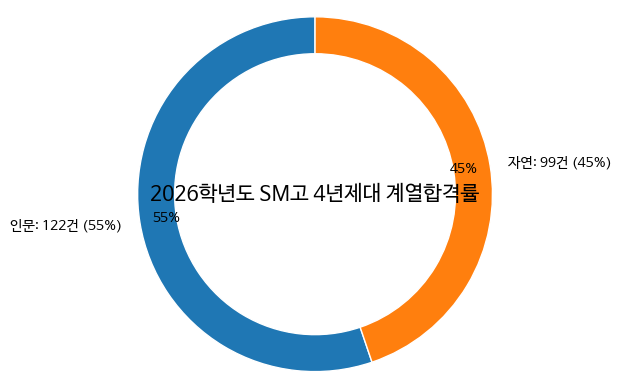

In [ ]:
#36. 4년제대 계열 합격률 도넛차트- 공통, 예체능을 인문으로 통합


import matplotlib.pyplot as plt
from tabulate import tabulate


#수시 전문대 제외
exclude_techschool = ['수시1차', '수시2차']
df_4year = df[(df['최종'] == '합') & ~(df['지원시기'].str.contains("|".join(exclude_techschool), na = False))].copy()


#정시 전문대 제외
df_4year = df_4year[~(df_4year['지원시기']  == '정시')]


# Combine '공통' and '예체능' into '인문' 계열
df_4year['계열'] = df_4year['계열'].replace(['공통', '예체능'], '인문')

# Group by '계열' and calculate the ratio
result = df_4year.groupby('계열').size().reset_index(name='합격자(건)')
result['비율(%)'] = (result['합격자(건)'] / result['합격자(건)'].sum() * 100).round(0).astype(int)  # Round to the nearest integer

# Rename the columns
result = result.rename(columns={'계열': '계열', '합격자(건)': '합격자(건)', '비율(%)': '비율(%)'})



# 시각화 부분 수정
fig, ax = plt.subplots()
ax.pie(result['합격자(건)'], labels=result['계열'] + ': ' + result['합격자(건)'].astype(str) + '건 (' + result['비율(%)'].astype(str) + '%)', startangle=90, radius=1.2, autopct='%1.0f%%', pctdistance=0.85, wedgeprops=dict(width=0.25, edgecolor='w'))

# 제목 추가
plt.text(0, 0, '2025학년도 SM고 4년제대 계열합격률', fontsize=15, ha='center', va='center')



plt.show()

In [ ]:
# '계열' 별로 합격한 학생 수 계산
pass_counts_by_dept = df[df['최종'] == '합'].groupby('계열').size()

# '계열' 별로 총 학생 수 계산
total_counts_by_dept = df.groupby('계열').size()

# '계열' 별 합격률 계산
pass_rates_by_dept = pass_counts_by_dept / total_counts_by_dept * 100

# 결과 출력
print(pass_rates_by_dept)

계열
간호보건          NaN
공통      29.545455
예체능     20.300752
인문      29.149798
자연      30.000000
dtype: float64


In [ ]:
#지원계열별 인원
df.groupby(by = '계열').size()

#df.groupby('계열').count() : 결과가 전체열의 빈도가 나옴

,0
계열,
간호보건,5
공통,44
예체능,133
인문,247
자연,310


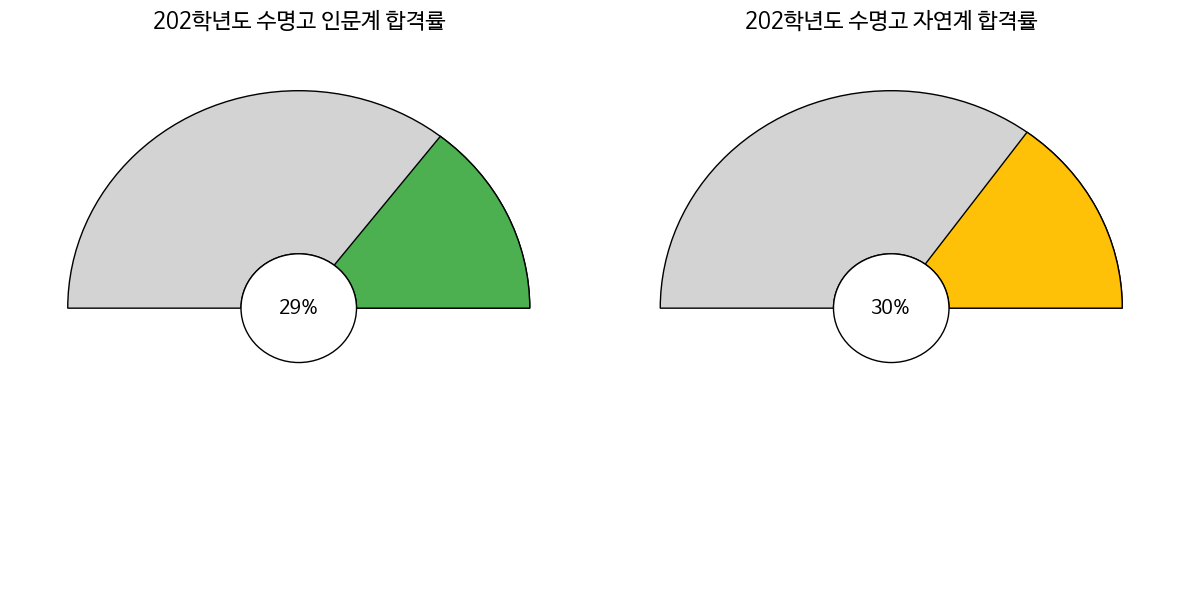

In [ ]:
#37. 계열별 합격률 반원 그래프 - 인문 합격률, 자연합격률

import matplotlib.pyplot as plt

from matplotlib.patches import Patch, Path, Wedge, Circle  # Circle 추가
import matplotlib.patches as patches


# '인문' 계열에서 '최종'이 '합'인 비율 계산
인문_합격자수 = df[(df['계열'] == '인문') & (df['최종'] == '합')].shape[0]
인문_전체 = df[df['계열'] == '인문'].shape[0]

ratio_inmun = (인문_합격자수 / 인문_전체) * 100 if 인문_전체 > 0 else 0
ratio_inmun = round(ratio_inmun)


# '자연' 계열에서 '최종'이 '합'인 비율 계산
자연_합격자수 = df[(df['계열'] == '자연') & (df['최종'] == '합')].shape[0]
자연_전체 = df[df['계열'] == '자연'].shape[0]

ratio_jayun = (자연_합격자수 / 자연_전체) * 100 if 자연_전체 > 0 else 0
ratio_jayun = round(ratio_jayun)


def draw_gauge_chart(ax, percentage, title, color):
    # 배경 원 그리기
    ax.add_patch(patches.Wedge(center=(0.5, 0.5), r=0.4, theta1=0, theta2=180, width=0.3, facecolor='lightgrey', edgecolor='black'))

    # 비율에 따른 원 그리기
    if percentage > 0:
        ax.add_patch(patches.Wedge(center=(0.5, 0.5), r=0.4, theta1=0, theta2=180 * percentage / 100, width=0.3, facecolor=color, edgecolor='black'))

    # 가운데 원(도넛 형태 만들기)
    ax.add_patch(Circle((0.5, 0.5), 0.1, transform=ax.transAxes, facecolor='white', edgecolor='black'))

    # 텍스트 및 타이틀 추가
    ax.text(0.5, 0.5, f'{percentage}%', horizontalalignment='center', verticalalignment='center', fontsize=14, transform=ax.transAxes)
    ax.set_title(title, fontsize=16)

    # 축 및 눈금 제거
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')


# 각 계열의 비율
ratios = {'인문': ratio_inmun, '자연': ratio_jayun}
colors = {'인문': '#4CAF50', '자연': '#FFC107'}

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

for ax, (title, percentage) in zip(axs, ratios.items()):
    draw_gauge_chart(ax, percentage, f'202학년도 수명고 {title}계 합격률', colors[title])

plt.tight_layout()



plt.show()

In [ ]:
#38. 특정등급대별 학생명단

min = float(input('몇등급이상:'))
max = float(input('몇등급이상:'))

df_one = df[(df['전과목'] >= min) & (df['전과목'] < max)]
df_one = df_one.drop_duplicates('이름')
df_one = df_one[['학번', '전과목', '등급수능', '대학', '모집단위', '최종', '전형분류']].sort_values(by = '전과목')
df_one

몇등급이상:3.7
몇등급이상:4


,학번,전과목,등급수능,대학,모집단위,최종,전형분류
6,30102,3.791,5.1,강원대(춘천),경영대학무전공학과,합,교과
574,30411,3.832,3.2,육군사관학교,육군사관학교(인문)(남),합,기타
568,30410,3.912,4.4,경기대(수원),경제학부,불,교과
493,30225,3.972,5.0,국민대,AI빅데이터융합경영학과(자연),불,교과
248,30504,3.980,NaN,가톨릭대(성심),자유전공학부,불,종합
201,30318,3.980,4.6,강남대,상경학부,불,교과


몇등급 이상:1
몇등급 미만:2


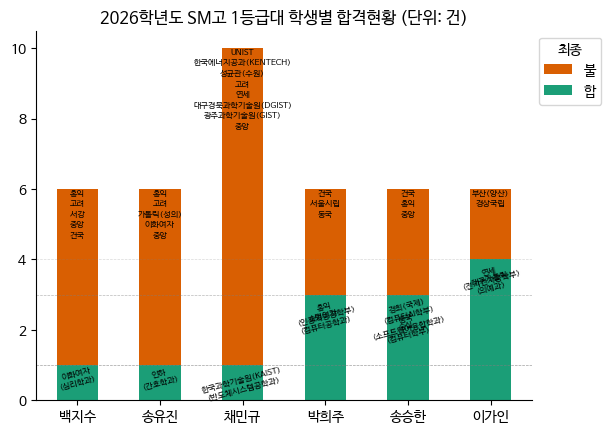

In [ ]:
#39. 등급입력하면 등급대 합격자 나오는 그래프: 합격자 대학, 학과


from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd


lownum = float(input("몇등급 이상:"))
highnum = float(input("몇등급 미만:"))


# 데이터 및 필터링
df_one = df[(df['전과목'] >= lownum) & (df['전과목'] < highnum)].copy()


#이름 익명처리
#df_one['이름'] = df_one['이름'].apply(lambda x: x[:2] + '0' * (len(x) - 2))


pivot_data = df_one.pivot_table(index='이름', columns='최종', values='학번', aggfunc='count', fill_value=0)
pivot_data = pivot_data[['합', '불']]
college_unit_data = df_one.groupby(['이름', '최종']).agg({
    '대학': lambda x: list(set(x)),
    '모집단위': lambda x: list(set(x))
}).unstack(fill_value=[])

pivot_data.sort_values(by='합', ascending=True, inplace=True)


# 대학명 단축 함수
def shorten_university_name(name):
    """'대학교'를 제거하여 대학명 단축"""
    return name.replace('대학교', '')


# 그래프 설정
ax = pivot_data.plot(kind='bar', stacked=True, color=sns.color_palette('Dark2', 2))
plt.gca().spines[['top', 'right']].set_visible(False)
plt.title(f"2025학년도 SM고 {int(round(lownum))}등급대 학생별 합격현황 (단위: 건)")
plt.xlabel('')
handles, labels = ax.get_legend_handles_labels()
order = [1, 0]
plt.legend([handles[idx] for idx in order], [labels[idx] for idx in order], title="최종", loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)

font_size1 = 6
font_size2 = 6
text_offset = 0.3



# 텍스트 추가 및 점선 그리기
for idx, val in enumerate(pivot_data.index):
    sum_height = pivot_data.loc[val, '합']
    non_height = pivot_data.loc[val, '불']

    if sum_height > 0:
        colleges = college_unit_data.loc[val, ('대학', '합')]
        units = college_unit_data.loc[val, ('모집단위', '합')]
        for i, (college, unit) in enumerate(zip(colleges, units)):
            short_name = shorten_university_name(college)  # 대학명 단축
            plt.text(idx, sum_height - i * text_offset, f"{short_name}\n({unit})", ha='center', va='top', color='black', fontsize=font_size1, rotation = 15)

    if non_height > 0:
        colleges = college_unit_data.loc[val, ('대학', '불')]
        for i, college in enumerate(colleges):
            short_name = shorten_university_name(college)  # 대학명 단축
            plt.text(idx, sum_height + non_height - i * text_offset, short_name, ha='center', va='top', color='black', fontsize=font_size2)

    # 점선 추가
    plt.hlines(y=sum_height, xmin=-0.5, xmax=len(pivot_data.index) - 0.5, colors='gray', linestyles='--', linewidth=0.5, alpha=0.3)

plt.show()

몇등급 이상:1
몇등급 미만:2


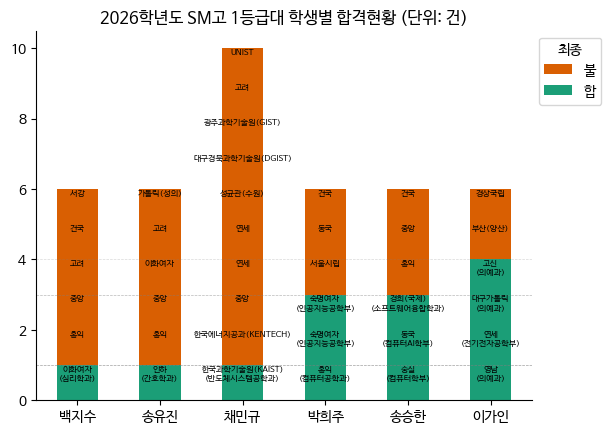

In [ ]:
#39. 등급입력하면 등급대 합격자 나오는 그래프: 합격자 대학, 학과

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd

lownum = float(input("몇등급 이상:"))
highnum = float(input("몇등급 미만:"))

# 데이터 및 필터링
df_one = df[(df['전과목'] >= lownum) & (df['전과목'] < highnum)].copy()

# 이름 익명처리
# df_one['이름'] = df_one['이름'].apply(lambda x: x[:2] + '0' * (len(x) - 2))

pivot_data = df_one.pivot_table(index='이름', columns='최종', values='학번', aggfunc='count', fill_value=0)
pivot_data = pivot_data[['합', '불']]
college_unit_data = df_one.groupby(['이름', '최종']).agg({
    '대학': lambda x: list(x),
    '모집단위': lambda x: list(x)
}).unstack(fill_value=[])

pivot_data.sort_values(by='합', ascending=True, inplace=True)


# 대학명 단축 함수
def shorten_university_name(name):
    """'대학교'를 제거하여 대학명 단축"""
    return name.replace('대학교', '')


# 그래프 설정
ax = pivot_data.plot(kind='bar', stacked=True, color=sns.color_palette('Dark2', 2))
plt.gca().spines[['top', 'right']].set_visible(False)
plt.title(f"2025학년도 SM고 {int(round(lownum))}등급대 학생별 합격현황 (단위: 건)")
plt.xlabel('')
handles, labels = ax.get_legend_handles_labels()
order = [1, 0]
plt.legend([handles[idx] for idx in order], [labels[idx] for idx in order], title="최종", loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)

font_size1 = 6
font_size2 = 6


# 텍스트 추가 및 점선 그리기
for idx, val in enumerate(pivot_data.index):
    sum_height = pivot_data.loc[val, '합']
    non_height = pivot_data.loc[val, '불']

    if sum_height > 0:
        colleges = college_unit_data.loc[val, ('대학', '합')]
        units = college_unit_data.loc[val, ('모집단위', '합')]

        # ✅ 합격 건수에 따라 offset 동적 계산
        text_offset = sum_height / len(colleges) if len(colleges) > 0 else 0.5

        for i, (college, unit) in enumerate(zip(colleges, units)):
            short_name = shorten_university_name(college)
            plt.text(idx, sum_height - i * text_offset, f"{short_name}\n({unit})",
                     ha='center', va='top', color='black', fontsize=font_size1, rotation=0)

    if non_height > 0:
        colleges = college_unit_data.loc[val, ('대학', '불')]

        # ✅ 불합격 건수에 따라 offset 동적 계산
        text_offset = non_height / len(colleges) if len(colleges) > 0 else 0.5

        for i, college in enumerate(colleges):
            short_name = shorten_university_name(college)
            plt.text(idx, sum_height + non_height - i * text_offset, short_name,
                     ha='center', va='top', color='black', fontsize=font_size2)

    # 점선 추가
    plt.hlines(y=sum_height, xmin=-0.5, xmax=len(pivot_data.index) - 0.5,
               colors='gray', linestyles='--', linewidth=0.5, alpha=0.3)

plt.show()

In [ ]:
#이름이 박희주 학생의 '최종'이 합이 학교 조회

df_park = df[(df['이름'] == '채민규') & (df['최종'] == '불')]

#이름, 대학, 모집단위, 최종 조회
df_park = df_park.loc[:, ['학번', '이름', '대학', '모집단위','전형명', '전형종류', '전형분류', '전형방법', '최종']]
df_park

,학번,이름,대학,모집단위,전형명,전형종류,전형분류,전형방법,최종
631,30128,채민규,UNIST,이공계열,일반,NaN,종합,서류100%,불
632,30128,채민규,고려대학교,기계공학부,학업우수전형,NaN,종합,서류 100%,불
633,30128,채민규,광주과학기술원(GIST),반도체공학과,일반전형,면접,종합,1단계:서류100%\n2단계:면접40%+1단계성적60%,불
634,30128,채민규,대구경북과학기술원(DGIST),반도체공학과,학교장추천전형,NaN,종합,서류100%,불
635,30128,채민규,성균관대학교(수원),반도체융합공학과,탐구형,NaN,종합,서류 100%,불
636,30128,채민규,연세대학교,IT융합공학전공,활동우수형,면접,종합,1단계:서류 100%\n2단계:면접 40% + 1단계성적 60%,불
637,30128,채민규,연세대학교,융합과학공학부(ISE),국제형(국내고),면접,종합,1단계:서류 100%\n2단계:면접 40% + 1단계성적 60%,불
638,30128,채민규,중앙대학교,기계공학부,지역균형전형,NaN,교과,학생부 100%,불
639,30128,채민규,한국에너지공과대학교(KENTECH),에너지공학부,일반전형,면접,종합,1단계:서류100%\n2단계:1단계성적 50% + 면접 50%,불


In [ ]:
[columns for columns in df.columns if '전형' in columns]

['전형명', '전형종류', '전형일자', '전형분류', '전형방법']

몇등급 이상:2
몇등급 미만:3


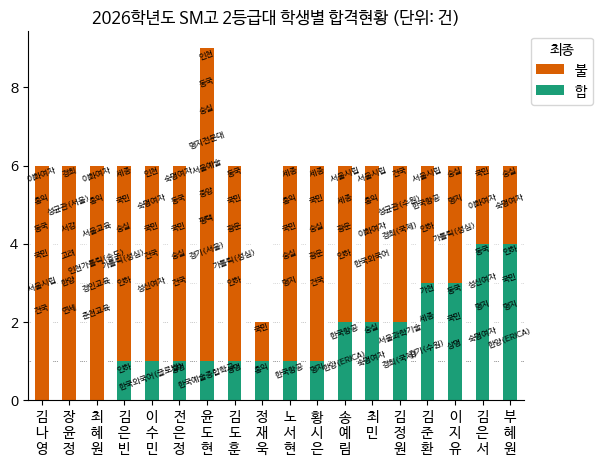

In [ ]:
#39-1. 등급입력하면 등급대 합격자 나오는 그래프: 합격자 대학만 나옴

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd

## 데이터 불러오기
path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')

lownum = float(input("몇등급 이상:"))
highnum = float(input("몇등급 미만:"))

# 필터링 조건에 맞는 데이터 추출
df_one = df[(df['전과목'] >= lownum) & (df['전과목'] < highnum)].copy()

# 이름의 민감한 정보를 숨김 처리
#df_one['이름'] = df_one['이름'].apply(lambda x: x[:2] + '0')

# '최종', '대학' 데이터를 각 '최종' 상태에 따라 집계
pivot_data = df_one.pivot_table(index='이름', columns='최종', values='학번', aggfunc='count', fill_value=0)
pivot_data = pivot_data[['합', '불']]  # '합'과 '불' 컬럼 순서 유지


# 대학 데이터만 추출
college_unit_data = df_one.groupby(['이름', '최종']).agg({
    '대학': lambda x: list(set(x)),
}).unstack(fill_value=[])

pivot_data.sort_values(by='합', ascending=True, inplace=True)  # '합' 기준으로 정렬


# 그래프 그리기
ax = pivot_data.plot(kind='bar', stacked=True, color=sns.color_palette('Dark2', 2))
plt.gca().spines[['top', 'right']].set_visible(False)
plt.title(f"2025학년도 SM고 {int(round(lownum))}등급대 학생별 합격현황 (단위: 건)")
plt.xlabel('')


# 범례 순서 조절
handles, labels = ax.get_legend_handles_labels()
order = [1, 0]  # '불'이 먼저 나오고 '합'이 다음 나오도록 조정
plt.legend([handles[idx] for idx in order], [labels[idx] for idx in order], title="최종", loc='upper left', bbox_to_anchor=(1, 1))

plt.xticks(rotation= -90)


# 각 x축 레이블을 세로로 쓰기
labels = ax.get_xticklabels()
for label in labels:
    label.set_rotation(0)
    label.set_text('\n'.join(label.get_text()))  # 각 글자를 줄바꿈으로 구분

ax.set_xticklabels(labels)


# 대학명 단축 함수
def shorten_university_name(name):
    """'대학교'를 제거하여 대학명 단축"""
    return name.replace('대학교', '')


# '합'과 '불' 세그먼트 내에 '대학' 텍스트 추가, 폰트 크기 및 간격 조정
font_size = 6  # 폰트 크기 설정

text_offset = 0.7  # 텍스트 간의 수직 간격 조정
for idx, val in enumerate(pivot_data.index):
    sum_height = pivot_data.loc[val, '합']
    non_height = pivot_data.loc[val, '불']

    # '합' 막대에 대학 목록 표시
    if sum_height > 0:
        colleges = college_unit_data.loc[val, ('대학', '합')]
        for i, college in enumerate(colleges):
            short_name = shorten_university_name(college)  # 대학명 단축
            plt.text(idx, sum_height - i * text_offset, short_name, ha='center', va='top', color='black', fontsize=font_size, rotation= 20)

    # '불' 막대에 대학 목록 표시
    if non_height > 0:
        colleges = college_unit_data.loc[val, ('대학', '불')]
        for i, college in enumerate(colleges):
            short_name = shorten_university_name(college)  # 대학명 단축
            plt.text(idx, sum_height + non_height - i * text_offset, short_name, ha='center', va='top', color='black', fontsize=font_size, rotation= 20)

    # 점선 추가
    #plt.hlines(y=sum_height, xmin=-0.5, xmax=len(pivot_data.index) - 0.5, colors='gray', linestyles='--', linewidth=0.5, alpha=0.3)
    # 점선 추가 (막대 사이 간격에만 그리기)
    bar_width = 0.4
    for i in range(len(pivot_data.index) - 1):
        plt.hlines(y=sum_height, xmin=i + bar_width, xmax=i + 1 - bar_width,
                   colors='gray', linestyles='dotted', linewidth=0.5, alpha=0.3)

# 첫 번째 막대 앞
    plt.hlines(y=sum_height, xmin=-0.5, xmax=0 - bar_width,
               colors='gray', linestyles='dotted', linewidth=0.5, alpha=0.3)

# 마지막 막대 뒤
    plt.hlines(y=sum_height, xmin=len(pivot_data.index) - 1 + bar_width,
               xmax=len(pivot_data.index) - 0.5,
               colors='gray', linestyles='dotted', linewidth=0.5, alpha=0.3)

plt.show()

In [ ]:
#39-2. 등급입력하면 등급대 합격자 나오는 그래프: 이름만 나옴

import pandas as pd
import plotly.graph_objects as go

# 데이터 불러오기
path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')

lownum = float(input("몇등급 이상:"))
highnum = float(input("몇등급 미만:"))

# 필터링 조건에 맞는 데이터 추출
df_one = df[(df['전과목'] >= lownum) & (df['전과목'] < highnum)].copy()

# 이름의 민감한 정보를 숨김 처리
#df_one['이름'] = df_one['이름'].apply(lambda x: x[:2] + '0')

# '최종', '대학' 데이터를 각 '최종' 상태에 따라 집계
pivot_data = df_one.pivot_table(index='이름', columns='최종', values='학번', aggfunc='count', fill_value=0)
pivot_data = pivot_data[['합', '불']]

# 그래프 객체 생성
fig = go.Figure()

# 각 막대 추가
for col in pivot_data.columns:
    fig.add_trace(go.Bar(x=pivot_data.index, y=pivot_data[col], name=col))

# 업데이트 레이아웃
fig.update_layout(barmode='stack', title_text=f"202학년도SM고 {int(round(lownum))}등급대 학생별 합격현황",
                  clickmode='event+select')

# 클릭 이벤트 처리 함수
def display_click(trace, points, state):
    idx = points.point_inds[0]
    label = pivot_data.index[idx]
    info = f'{label}: 합격 {pivot_data.loc[label, "합"]}건, 불합격 {pivot_data.loc[label, "불"]}건'
    fig.update_layout(title_text=info)

# 클릭 이벤트 연결
fig.data[0].on_click(display_click)

# 그래프 표시
fig.show()

몇등급 이상:1
몇등급 미만:2


몇등급 이상:1
몇등급 미만:2


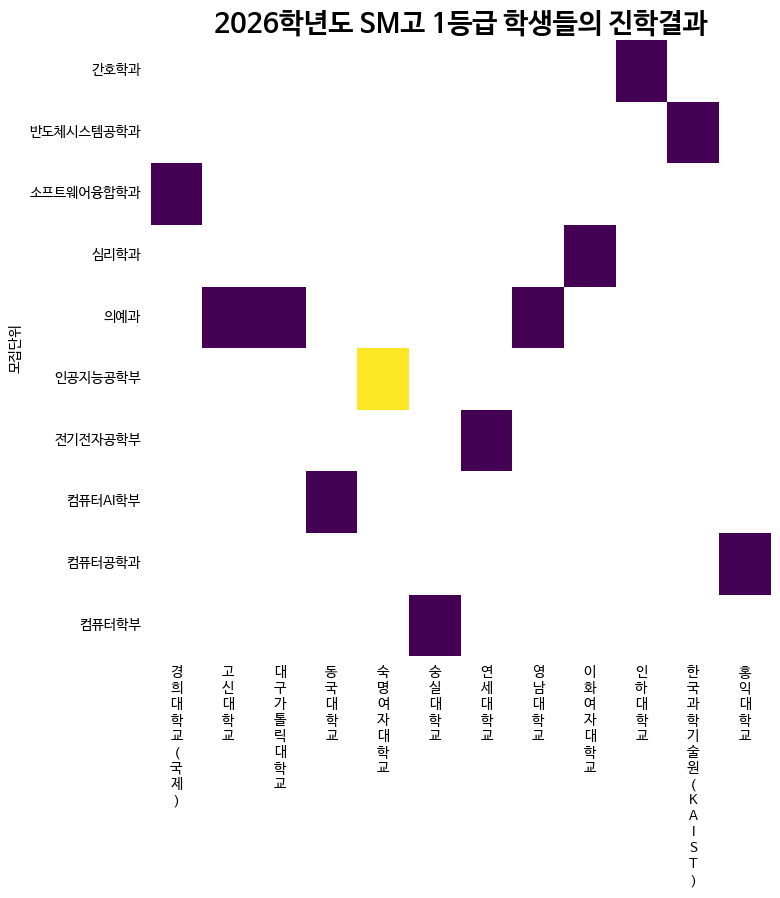

In [ ]:
#40. 특정등급대 학생들의 진학결과 그래프

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd


lownum = float(input("몇등급 이상:"))
highnum = float(input("몇등급 미만:"))


# 필터링 조건에 맞는 데이터 추출
df_one = df[(df['전과목'] >= lownum) & (df['전과목'] < highnum) & (df['최종'] == '합')].copy()

plt.figure(figsize=(8, 8))
plt.title(f'2025학년도 SM고 {int(round(lownum))}등급 학생들의 진학결과',fontsize = 20, fontweight='bold')  # 제목 설정


# 그룹화 및 모집단위별 카운트, 실제 데이터에 맞춰서 df_one을 사용
df_2dhist = pd.DataFrame({
    x_label: grp['모집단위'].value_counts()
    for x_label, grp in df_one.groupby('대학')
})

# 히트맵 생성
#ax = sns.heatmap(df_2dhist, cmap='viridis', annot=True, fmt=".2f")
ax = sns.heatmap(df_2dhist, cmap='viridis', cbar=False)


# 히트맵 상단에 '내신등급' 텍스트 추가
# 'x'와 'y'는 텍스트가 위치할 좌표입니다. 'ha'는 가로 정렬 방식을, 'va'는 세로 정렬 방식을 지정합니다.
#plt.text(x=1.12, y=1.02, s='내신등급', fontsize=12, ha='center', va='bottom', transform=ax.transAxes)


plt.tick_params(axis='both',  # 'both'는 x축과 y축 모두에 적용됩니다.
                which='both',  # 'both'는 주요(major) 및 부차적(minor) tick 모두에 적용됩니다.
                bottom=False,  # x축의 하단 tick을 삭제합니다.
                top=False,    # x축의 상단 tick을 삭제합니다.
                left=False,   # y축의 왼쪽 tick을 삭제합니다.
                right=False,  # y축의 오른쪽 tick을 삭제합니다.
                labelbottom=True,  # x축 라벨은 유지합니다.
                labelleft=True)  # y축 라벨 유지


# x축 대학명을 세로 방향(위에서 아래)으로 표시
plt.xticks(rotation=0, ha='center', va='top')


    # 각 x축 레이블을 세로로 쓰기
labels = ax.get_xticklabels()
for label in labels:
    label.set_rotation(0)
    label.set_text('\n'.join(label.get_text()))  # 각 글자를 줄바꿈으로 구분

ax.set_xticklabels(labels)


plt.show()

몇등급 이상:1
몇등급 미만:2


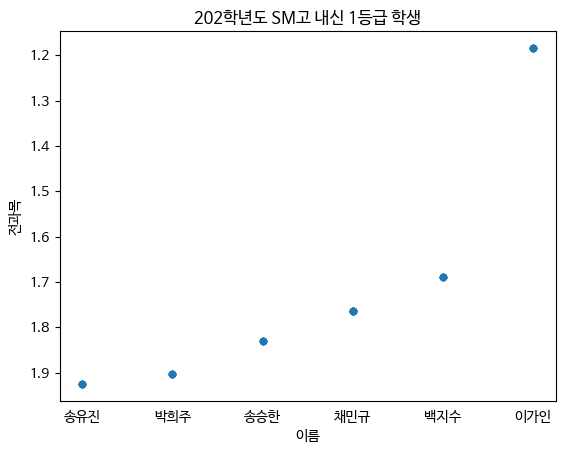

In [ ]:
#41. 특정등급대 학생들의 내신등급

lownum = float(input("몇등급 이상:"))
highnum = float(input("몇등급 미만:"))

df_one = df[(df['전과목'] >= lownum) & (df['전과목'] < highnum)]
# df_one = df_one.drop_duplicates('이름')
df_one = df_one[['이름', '전과목', '전형분류', '최종', '대학', '모집단위']].sort_values(by='전과목', ascending=False)

# x축 이름 수정
#df_one['이름'] = df_one['이름'].apply(lambda x: x[0] + '*' * (len(x) - 1))

# 그래프 생성
ax = df_one.plot.scatter(x='이름', y='전과목')

# 제목 추가
ax.set_title(f'202학년도 SM고 내신 {int(round(lownum))}등급 학생')

# y축 방향 반대로 설정
ax.invert_yaxis()


plt.tick_params(axis='both',  # 'both'는 x축과 y축 모두에 적용됩니다.
                which='both',  # 'both'는 주요(major) 및 부차적(minor) tick 모두에 적용됩니다.
                bottom=False,  # x축의 하단 tick을 삭제합니다.
                top=False,    # x축의 상단 tick을 삭제합니다.
                left=True,   # y축의 왼쪽 tick을 삭제합니다.
                right=False,  # y축의 오른쪽 tick을 삭제합니다.
                labelbottom=True,  # x축 라벨은 유지합니다.
                labelleft=True)  # y축 라벨 유지


In [ ]:
#42.수시정시 지원건수 및 비율

# '지원시기'열의 값 변경: 가,나
df['지원시기'] = df['지원시기'].replace({'가': '정시', '나': '정시', '다': '정시', '정시1차':'정시',
                                       '수시1차': '수시', '수시2차': '수시'})

# 지원시기와 최종의 빈도 및 비율 계산
지원시기_빈도 = df['지원시기'].value_counts()
최종_빈도 = df['최종'].value_counts()

# 빈도 출력
print("지원시기별 건수:")
print(지원시기_빈도)
print("\n최종 결과 건수:")
print(최종_빈도)

# 비율 계산 및 출력
print("\n지원시기 비율:")
print((지원시기_빈도 / 지원시기_빈도.sum())*100)
print("\n최종 비율:")
final = ((최종_빈도 / 최종_빈도.sum())*100).round(1)
print(final)

지원시기별 건수:
지원시기
수시    739
Name: count, dtype: int64

최종 결과 건수:
최종
불    534
합    205
Name: count, dtype: int64

지원시기 비율:
지원시기
수시    100.0
Name: count, dtype: float64

최종 비율:
최종
불    72.3
합    27.7
Name: count, dtype: float64


In [ ]:
#46. 모집단위에서 특정전공 검색

from tabulate import tabulate

path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')

major = input("관심전공:")

#디자인이 들어간 학과
df_design = df[(df['모집단위'].str.contains(major))]


df_design_applicant = df_design.drop_duplicates('이름')
df_design_applicant = len(df_design_applicant)

#필요한 변수(열)만 불러옴
df_design = df_design[['지역', '학번', '계열', '대학', '모집단위', '최종', '전과목', '지원시기', '전형분류']]



# tabulate를 사용하여 결과 출력
print(tabulate(df_design, headers='keys', tablefmt='plain', showindex=False))
print("********************************************************************")
print(f'중복제외한 지원자수는 {df_design_applicant}명')



#데이터 프레임으로 전환
df_design = pd.DataFrame(df_design)


#결과를 엑셀로 저장
path = '/content/drive/MyDrive/python/sumyeong/result_excel/'
df_design.to_excel(excel_writer= f'{path}디자인학과지원자_2025_수명고.xlsx')

관심전공:건축
지역      학번  계열    대학            모집단위                       최종      전과목  지원시기    전형분류
서울     30221  자연    동국대          건축공학부                     불         3.065  수시        교과
서울     30221  자연    숭실대          건축학부(실내건축전공)         불         3.065  수시        종합
서울     30221  인문    한양대          실내건축디자인학과             불         3.065  수시        종합
서울     30314  자연    고려대          건축사회환경공학부             불         2.087  수시        교과
서울     30405  자연    삼육대          건축학과(5년)                  불         4.684  수시        종합
서울     30407  자연    동국대          건축공학부                     불         2.388  수시        교과
서울     30407  자연    서울시립대      건축학부(건축학전공)(5년)      불         2.388  수시        교과
서울     30407  자연    숭실대          건축학부(건축학,건축공학전공)  합         2.388  수시        교과
서울     30410  자연    동양미래대학교  건축과                         합         5.853  수시1차     교과
경기     30616  자연    경민대학교      건축공간디자인과               합         7.596  수시2차     교과
******************************************************

In [ ]:
#47. 전형분류에서 특정전형 검색

from tabulate import tabulate

path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')


type = input("전형(ex:교과, 종합, 논술, 실기):")

#디자인이 들어간 학과
df_design = df[(df['전형분류'].str.contains(type))]


df_design_applicant = df_design.drop_duplicates('이름')
df_design_applicant = len(df_design_applicant)



#필요한 변수(열)만 불러옴
df_design = df_design[['전형분류', '지역', '학번', '계열', '이름', '대학', '모집단위', '최종', '전과목', '지원시기']]



# tabulate를 사용하여 결과 출력
print(tabulate(df_design, headers='keys', tablefmt='plain', showindex=False))
print("********************************************************************")
print(f'중복제외한 지원자수는 {df_design_applicant}명')



#데이터 프레임으로 전환
df_design = pd.DataFrame(df_design)


#결과를 엑셀로 저장
path = '/content/drive/MyDrive/python/sumyeong/result_excel/'
df_design.to_excel(excel_writer= f'{path}실기전형지원자_2025_수명고.xlsx')

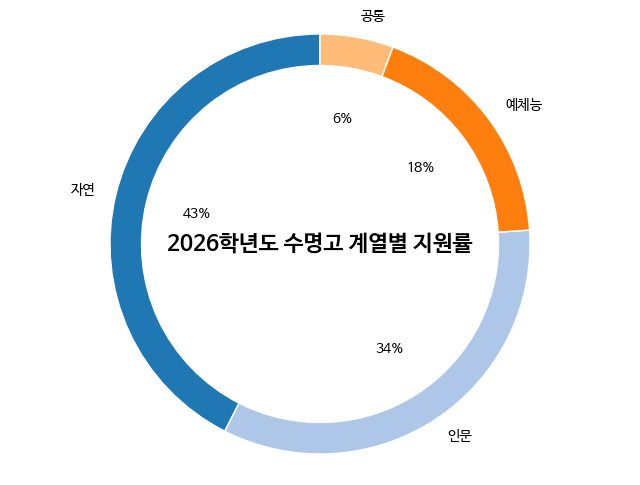

In [ ]:
#48. 계열별 지원비율(ex: 인문, 자연, 예체능)

import pandas as pd
import matplotlib.pyplot as plt

# 파일 불러오기
path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')

# 전체 학생 수 계산
total_students = len(df)



# '지원시기'열의 값 변경: 가,나
df['계열'] = df['계열'].replace({'간호보건': '자연'})


# '계열' 열에서 groupby로 빈도와 비율 계산
dept_counts = df['계열'].value_counts()
dept_ratio = dept_counts / total_students

# 도넛차트로 빈도와 비율 표현
fig, ax = plt.subplots(figsize=(8, 6))
#ax.pie(dept_counts, labels=dept_counts.index, autopct='%1.0f%%', startangle=90, colors=plt.cm.tab20.colors)
ax.pie(dept_counts, labels=dept_counts.index, autopct='%1.0f%%', startangle=90, colors=plt.cm.tab20.colors, wedgeprops=dict(width=0.15, edgecolor='w'))


ax.axis('equal')

# 도넛 형태 생성
center_circle = plt.Circle((0,0),0.80,fc='white')
fig.gca().add_artist(center_circle)

# 제목 추가
plt.text(0, 0, '2025학년도 수명고 계열별 지원률', horizontalalignment='center', verticalalignment='center', fontsize=16, fontweight='bold')

plt.show()


In [ ]:
#49. 특정계열의 합격률

adtype = input("계열(ex: 인문, 자연, 예체능)")

arts_students = df[df['계열'] == adtype]

# '최종' 열에서 '합'인 행 선택
pass_students = arts_students[arts_students['최종'] == '합']

# '계열' 열이 '예체능'인 학생들의 합격률 계산
pass_rate = len(pass_students) / len(arts_students) * 100

print(f"{adtype} 학생들의 합격률 {pass_rate}%")

계열(ex: 인문, 자연, 예체능)예체능
예체능 학생들의 합격률 27.611940298507463%


In [ ]:
#50. 특정계열의 합격자

adtype = input("계열(ex: 인문, 자연, 예체능)")


# '계열' 열이 '예체능'인 행 필터링
arts_students = df[df['계열'] == adtype]

# '최종' 열에서 '합'인 행 선택
pass_students = arts_students[arts_students['최종'] == '합']


#반올림
pass_students['전과목'] = pass_students['전과목'].round(1)

# '최종' 열에서 '합'인 학생들의 '학번', '대학', '모집단위' 열 출력
pass_students_info = pass_students[['대학', '계열', '모집단위', '최종', '전과목']]


# '전과목' 열 값을 오름차순으로 정렬
pass_students_info_sorted = pass_students_info.sort_values(by='전과목')


# tabulate를 사용하여 결과 출력
print(tabulate(pass_students_info_sorted, headers='keys', tablefmt='plain', showindex=False))



#결과를 엑셀로 저장
path = '/content/drive/MyDrive/python/sumyeong/result_excel/'
pass_students_info_sorted.to_excel(excel_writer= f'{path}예체능전형합격자_2025_수명고.xlsx')

계열(ex: 인문, 자연, 예체능)예체능
대학              계열    모집단위                            최종      전과목
성신여대          예체능  디자인과                            합           2.8
인하대            예체능  의류디자인학과(실기)                합           3.3
세종대            예체능  영화예술학과(연출제작전공)          합           3.5
명지전문대학      예체능  디지털콘텐츠융합과                  합           4.1
연성대학교        예체능  반려동물보건과                      합           4.2
명지전문대학      예체능  뷰티매니지먼트과(뷰티스킨케어전공)  합           4.2
경인여자대학교    예체능  뷰티디자인학과 뷰티케어전공         합           4.7
세종대            예체능  영화예술학과(연출제작전공)          합           4.7
백제예술대학교    예체능  실용음악과                          합           4.7
경동대(양주)      예체능  스포츠마케팅학과                    합           4.8
동양미래대학교    예체능  시각디자인과                        합           4.9
신한대(의정부)    예체능  공연예술학과(연기)                  합           5.4
명지전문대학      예체능  연극영상학과                        합           5.4
중부대(고양)      예체능  연극영화학전공(연기)                합           5.4
백석예술대학교    예체능  공연예술학부(뮤지컬)                합           5.4

<ipython-input-33-0410fd981239>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pass_students['전과목'] = pass_students['전과목'].round(1)


In [ ]:
[columns for columns in df.columns if '전형' in columns]

['전형명', '전형종류', '전형일자', '전형분류', '전형방법']

In [ ]:
#51. 특정학과의 특정등급일때 결과

from tabulate import tabulate


major = input("모집단위:")
level_min =  float(input("높은 등급:"))
level_max = float(input("낮은 등급:"))


#4년제 지원자수(중복포함)
df_nurse = df[(df.모집단위.str.contains(major))]

#df_nurse = df_nurse[df_nurse['최종'] == '합']

df_nurse = df_nurse[(df_nurse['전과목'] > level_min) & (df_nurse['전과목'] < level_max) ]

df_nurse['전과목'] = df_nurse['전과목'].round(1)

df_nurse =  df_nurse[['전과목', '대학', '모집단위', '최종', '전형분류', '전형명', '전형방법']]



# tabulate를 사용하여 결과 출력
print(tabulate(df_nurse, headers='keys', tablefmt='plain', showindex=False))


#결과를 엑셀로 저장
path = '/content/drive/MyDrive/python/sumyeong/result_excel/'
df_nurse.to_excel(excel_writer= f'{path}간호학과합격자_2025_3.5등급.xlsx')

모집단위:국어
높은 등급:3
낮은 등급:4
  전과목  대학            모집단위              최종    전형분류    전형명                      전형방법
     3.5  동국대          국어국문문예창작학부  합      실기        실기(국어국문문예창작학부)  학생부 30% + 실기 70%
     3.7  가천대(글로벌)  외국어계열            불      교과        지역균형                    1단계:【7배수】학생부 100%
                                                                                                2단계:면접 50% + 1단계성적 50%


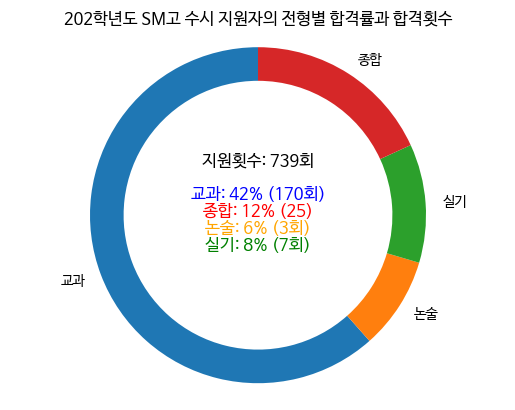

In [ ]:
#52. 전형별 합격률과 합격횟수

import pandas as pd
import matplotlib.pyplot as plt

# 데이터 전처리: 전형분류 재분류
df_modified = df.copy()

# 조건 1: '전형분류'가 '학생부'이고 '전형방법'에 '100%'가 포함된 경우 → '교과'로 변경
df_modified.loc[(df_modified['전형분류'] == '학생부') &
                (df_modified['전형방법'].str.contains('100%', na=False)), '전형분류'] = '교과'


# 조건 2: '전형분류'가 '학생부'이고 '전형방법'에 '면접'이 포함된 경우 → '종합'으로 변경
df_modified.loc[(df_modified['전형분류'] == '학생부') &
                (df_modified['전형방법'].str.contains('면접', na=False)), '전형분류'] = '종합'

# 수시, 수시1차, 수시2차를 모두 포함
susi = ['수시', '수시1차', '수시2차']

# 조건에 따라 데이터 필터링 (df_modified 사용!)
filtered_df = df_modified[df_modified['지원시기'].str.contains("|".join(susi), na=False)]

# 각 전형분류별 합격자 수 계산
pass_counts = filtered_df.groupby('전형분류')['최종'].value_counts().unstack().fillna(0)['합']

# 각 전형분류별 합격률 계산
pass_rates = filtered_df.groupby('전형분류')['최종'].value_counts(normalize=True).unstack().fillna(0)['합']

# 도넛 차트 생성
labels = pass_rates.index
sizes = pass_rates.values * 100
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, startangle=90, wedgeprops=dict(width=0.2))

ax.axis('equal')

# 도넛 차트 내부에 비율과 빈도 표현
ax.text(0, 0.3, f"지원횟수: {len(filtered_df)}회", ha='center', fontsize=12, color='black')
ax.text(0, 0.1, f"교과: {pass_rates['교과'] * 100:.0f}% ({int(pass_counts['교과'])}회)", ha='center', fontsize=12, color='blue')
ax.text(0, 0, f"종합: {pass_rates['종합'] * 100:.0f}% ({int(pass_counts['종합'])})", ha='center', fontsize=12, color='red')
ax.text(0, -0.1, f"논술: {pass_rates['논술'] * 100:.0f}% ({int(pass_counts['논술'])}회)", ha='center', fontsize=12, color='orange')
ax.text(0, -0.2, f"실기: {pass_rates['실기'] * 100:.0f}% ({int(pass_counts['실기'])}회)", ha='center', fontsize=12, color='green')

plt.title('202학년도 SM고 수시 지원자의 전형별 합격률과 합격횟수')
plt.show()

In [ ]:
[columns for columns in df.columns if '전형' in columns]

['전형명', '전형종류', '전형일자', '전형분류', '전형방법']

In [ ]:
import pandas as pd

# '전형분류'가 '학생부'인 행만 필터링하여 원하는 열 선택
result = df[df['전형분류'] == '학생부'][['이름', '대학', '전형명', '전형종류', '전형일자', '전형방법']]

# 결과 출력
print(result)

# 또는 더 보기 좋게 출력
print(result.to_string(index=False))

      이름       대학                       전형명 전형종류 전형일자            전형방법
29   김예은    동남보건대  기초수급권자/차상위계층/한부모가족 지원대상자  NaN  NaN        학생부 100%
43   김지후    서일대학교                       일반고  NaN  NaN         학생부100%
44   김지후  숭의여자대학교                        일반  NaN  NaN        학생부 100%
114  임소진  수원과학대학교                       일반고  NaN  NaN        학생부 100%
144  최민용      김포대                        일반  NaN  NaN        학생부 100%
158  김지효     경인여대                        일반  NaN  NaN        학생부 100%
159  김지효     경인여대                        일반  NaN  NaN        학생부 100%
163  김지효    서일대학교                       일반고  NaN  NaN         학생부100%
166  김초은      경민대                       일반고  NaN  NaN        학생부 100%
167  김초은     경인여대                       일반고  NaN  NaN        학생부 100%
169  김초은    서정대학교                        일반  NaN  NaN         학생부100%
170  김초은  수원여자대학교                        일반  NaN  NaN    학생부60%+면접40%
176  김효주      대림대                       일반고  NaN  NaN        학생부 100%
177  김효주      대림대   

In [ ]:
#53. 모집단위(학과)별 지원자

from tabulate import tabulate

path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')

major = input("모집단위:")

#4년제 지원자수(중복포함)
uni_apply = df[(df.모집단위.str.contains(major))]

print(uni_apply[['대학', '모집단위', '최종', '전과목', '등급수능']])

모집단위:태권
           대학          모집단위 최종    전과목  등급수능
591  가천대(글로벌)         태권도전공  불  6.906   NaN
592  신한대(의정부)         태권도학부  합  6.906   NaN
593       용인대         태권도학과  불  6.906   NaN
594     한국체육대         태권도학과  불  6.906   NaN
595       상지대  체육학부(태권도학전공)  합  6.906   NaN
620  가천대(글로벌)         태권도전공  불  5.990   7.6
621  신한대(의정부)         태권도학부  합  5.990   7.6
622       용인대         태권도학과  불  5.990   7.6


In [ ]:
#54. 등급대별 수시 합격자 확인

from tabulate import tabulate


##  데이터 부르기
path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')


level_min =  float(input("높은 등급:"))
level_max = float(input("낮은 등급:"))

apply_type = input("전형분류:")
result = input("최종(합, 불):")


#4년제 지원자수(중복포함)
df_nurse = df[(df.전형분류.str.contains(apply_type))]

df_nurse = df_nurse[df_nurse['최종'] == result]

df_nurse = df_nurse[(df_nurse['전과목'] >= level_min) & (df_nurse['전과목'] < level_max) ]

df_nurse['전과목'] = df_nurse['전과목'].round(1)

df_nurse =  df_nurse[['이름', '전과목', '대학', '모집단위', '최종', '전형분류', '전형명', '전형방법']]

df_nurse_num = len(df_nurse)


print(f"종합전형 {result}건수 {df_nurse_num}건")

# tabulate를 사용하여 결과 출력
print(tabulate(df_nurse, headers='keys', tablefmt='plain', showindex=False))

높은 등급:1
낮은 등급:2
전형분류:교과
최종(합, 불):합
종합전형 합건수 9건
이름      전과목  대학              모집단위        최종    전형분류    전형명                        전형방법
백지수       1.7  이화여자대학교    심리학과        합      교과        고교추천전형                  학생부 100%
송승한       1.8  동국대학교        컴퓨터AI학부    합      교과        학교장추천인재                학생부 70% + 서류 30%
송승한       1.8  숭실대학교        컴퓨터학부      합      교과        학생부우수자전형              학생부 100%
박희주       1.9  숙명여자대학교    인공지능공학부  합      교과        학생부교과(지역균형선발전형)  학생부 100%
송유진       1.9  인하대학교        간호학과        합      교과        지역균형                      학생부 100%
이가인       1.2  고신대학교        의예과          합      교과        일반고                        1단계:학생부 100%_x000D_
                                                                                                      2단계:면접 10% + 1단계성적 90%
이가인       1.2  대구가톨릭대학교  의예과          합      교과        교과전형                      1단계:학생부 100%_x000D_
                                                                                              

In [ ]:
#55. 등급대별 수능최저등급 충족여부 - 내신등급 추가

import numpy as np
import pandas as pd
from tabulate import tabulate
import math  # 절사를 위해 math 모듈 추가



##  데이터 부르기
path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')


# 입력 받기
level_min = float(input("내신 높은 등급:"))
level_max = float(input("내신 낮은 등급:"))

choice = input("탐구1과 탐구2의 평균등급을 사용하시겠습니까? (예/아니오): ")

# '수능'을 제외한 값 필터링
#df_filtered = df[df['전형분류'] != '수능']

# 범위에 따른 '전과목' 값 필터링
df_level = df_filtered[(df_filtered['전과목'] >= level_min) & (df_filtered['전과목'] < level_max)].copy()

# 데이터 프레임 필터링
df_level = df_level.drop_duplicates('전과목')
df_level = df_level[['전과목', '국어_등급', '수학_등급', '영어_등급', '선택1_등급', '선택2_등급']]

# '이름' 열의 값을 첫 글자만 남기고 나머지는 '*'로 대체
#df_level['이름'] = df_level['이름'].apply(lambda x: x[:1] + '*' * (len(x) - 1) if len(x) >= 2 else x)

# 열 이름 변경
df_level.rename(columns={'선택1_등급': '탐구1_등급', '선택2_등급': '탐구2_등급'}, inplace=True)


# NaN 값을 0으로 대체
df_level.fillna(0, inplace=True)

# 평균 사용 여부에 따른 조건 처리
if choice.lower() == '예':
    trunc_choice = input("탐구1과 탐구2의 평균을 절사하시겠습니까? (예/아니오): ")
    if trunc_choice.lower() == '예':
        df_level['탐구_등급'] = df_level[['탐구1_등급', '탐구2_등급']].mean(axis=1).apply(math.floor)
    else:
        df_level['탐구_등급'] = df_level[['탐구1_등급', '탐구2_등급']].mean(axis=1)
    columns = ['국어_등급', '수학_등급', '영어_등급', '탐구_등급']
else:
    columns = ['국어_등급', '수학_등급', '영어_등급', '탐구1_등급', '탐구2_등급']

# 최저합 계산
df_level['4합'] = df_level[columns].apply(lambda x: x.nsmallest(4).sum(), axis=1)
df_level['3합'] = df_level[columns].apply(lambda x: x.nsmallest(3).sum(), axis=1)
df_level['2합'] = df_level[columns].apply(lambda x: x.nsmallest(2).sum(), axis=1)

# 결과 출력
headers = ['전과목', '국어_등급', '수학_등급', '영어_등급']
if choice.lower() == '예':
    headers.append('탐구_등급')
else:
    headers.extend(['탐구1_등급', '탐구2_등급'])
headers.extend(['2합', '3합', '4합'])

#전과목 순으로 오름차순
df_level = df_level.sort_values(by='전과목')

tab = tabulate(df_level[headers], headers='keys', tablefmt='plain', showindex=False)
print()
print(tab)

# 데이터 프레임으로 전환은 불필요함
# 엑셀로 저장
#path = '/content/drive/MyDrive/python/sumyeong/'
#df_level.to_excel(excel_writer=f'{path}{level_min}등급대_수능최저등급조합_2025_수명고_익명.xlsx', index=False)

내신 높은 등급:1.0
내신 낮은 등급:2.0
탐구1과 탐구2의 평균등급을 사용하시겠습니까? (예/아니오): 예
탐구1과 탐구2의 평균을 절사하시겠습니까? (예/아니오): 예

  전과목    국어_등급    수학_등급    영어_등급    탐구_등급    2합    3합    4합
   1                2            2            2            1      3      5      7
   1.071            3            2            2            6      4      7     13
   1.186            3            2            0            2      2      4      7
   1.526            4            3            2            4      5      9     13
   1.726            7            4            2            5      6     11     18
   1.899            1            5            2            2      3      5     10


In [ ]:
#55. 등급대별 수능최저등급 충족여부 - 내신등급 추가

import numpy as np
import pandas as pd
from tabulate import tabulate
import math  # 절사를 위해 math 모듈 추가

# 입력 받기
grade_high = float(input("내신 높은 등급(낮은 숫자, 예: 1.5): "))  # 숫자가 작을수록 높은 내신
grade_low  = float(input("내신 낮은 등급(높은 숫자, 예: 3.0): "))  # 숫자가 클수록 낮은 내신

choice = input("탐구1과 탐구2의 평균등급을 사용하시겠습니까? (예/아니오): ").strip()

# '수능'을 제외한 값 필터링
df_filtered = df[df['전형분류'] != '수능']



# 필터링 전에 전과목 컬럼을 float으로 변환
df_filtered['전과목'] = pd.to_numeric(df_filtered['전과목'], errors='coerce')


# 범위에 따른 '전과목' 값 필터링 (경계값 포함: >= , <=)
df_level = df_filtered[
    (df_filtered['전과목'] >= grade_high) &
    (df_filtered['전과목'] <= grade_low)
].copy()

# 데이터 프레임 필터링
df_level = df_level.drop_duplicates('이름')
df_level = df_level[['이름', '전과목', '국어_등급', '수학_등급', '영어_등급', '선택1_등급', '선택2_등급']]

# '이름' 열의 값을 첫 글자만 남기고 나머지는 '*'로 대체
# df_level['이름'] = df_level['이름'].apply(lambda x: x[:1] + '*' * (len(x) - 1) if len(x) >= 2 else x)

# 열 이름 변경
df_level.rename(columns={'선택1_등급': '탐구1_등급', '선택2_등급': '탐구2_등급'}, inplace=True)

# 평균 사용 여부에 따른 조건 처리
if choice == '예':
    trunc_choice = input("탐구1과 탐구2의 평균을 절사하시겠습니까? (예/아니오): ").strip()
    if trunc_choice == '예':
        df_level['탐구_등급'] = df_level[['탐구1_등급', '탐구2_등급']].mean(axis=1).apply(math.trunc)
    else:
        df_level['탐구_등급'] = df_level[['탐구1_등급', '탐구2_등급']].mean(axis=1)
    columns = ['국어_등급', '수학_등급', '영어_등급', '탐구_등급']
else:
    columns = ['국어_등급', '수학_등급', '영어_등급', '탐구1_등급', '탐구2_등급']

# 최저합 계산 (NaN은 합산에서 제외)
df_level['4합'] = df_level[columns].apply(lambda x: x.dropna().nsmallest(4).sum(), axis=1)
df_level['3합'] = df_level[columns].apply(lambda x: x.dropna().nsmallest(3).sum(), axis=1)
df_level['2합'] = df_level[columns].apply(lambda x: x.dropna().nsmallest(2).sum(), axis=1)

# 결과 출력 헤더 구성
headers = ['전과목', '국어_등급', '수학_등급', '영어_등급']
if choice == '예':
    headers.append('탐구_등급')
else:
    headers.extend(['탐구1_등급', '탐구2_등급'])
headers.extend(['2합', '3합', '4합'])

# 전과목 순으로 오름차순 정렬
df_level = df_level.sort_values(by='전과목')

tab = tabulate(df_level[headers], headers='keys', tablefmt='plain', showindex=False)
print()
print(tab)

# 엑셀로 저장
path = '/content/drive/MyDrive/python/sumyeong/'
df_level.to_excel(
    excel_writer=f'{path}{grade_high}등급대_수능최저등급조합_2026_수명고_익명.xlsx',
    index=False
)

내신 높은 등급(낮은 숫자, 예: 1.5): 1.0
내신 낮은 등급(높은 숫자, 예: 3.0): 2.0
탐구1과 탐구2의 평균등급을 사용하시겠습니까? (예/아니오): 예
탐구1과 탐구2의 평균을 절사하시겠습니까? (예/아니오): 예

  전과목    국어_등급    수학_등급    영어_등급    탐구_등급    2합    3합    4합
       1            2            2            2            1      3      5      7


In [ ]:
#55-1. 수능최저등급 개인별 자동확인

import numpy as np
from tabulate import tabulate
import math  # 절사를 위해 math 모듈 추가

# 사용자 입력 받기
name = input('이름: ')
choice = input("탐구1과 탐구2'의 평균등급을 사용하시겠습니까? (예/아니오): ")

# 데이터 프레임 필터링
df_kim = df[df['이름'] == name]
df_kim = df_kim.drop_duplicates('이름')
df_kim = df_kim[['국어_등급', '수학_등급', '영어_등급', '선택1_등급', '선택2_등급']]

# 열 이름 변경
df_kim.rename(columns={'선택1_등급': '탐구1_등급', '선택2_등급': '탐구2_등급'}, inplace=True)

# 평균 사용 여부에 따른 조건 처리
if choice.lower() == '예':
    trunc_choice = input("탐구1과 탐구2의 평균을 절사하시겠습니까? (예/아니오): ")
    if trunc_choice.lower() == '예':
        df_kim['탐구_등급'] = df_kim[['탐구1_등급', '탐구2_등급']].mean(axis=1).apply(math.floor)
    else:
        df_kim['탐구_등급'] = df_kim[['탐구1_등급', '탐구2_등급']].mean(axis=1)
    columns = ['국어_등급', '수학_등급', '영어_등급', '탐구_등급']
else:
    columns = ['국어_등급', '수학_등급', '영어_등급', '탐구1_등급', '탐구2_등급']

# 최저합 계산
df_kim['4합'] = df_kim[columns].apply(lambda x: x.nsmallest(4).sum(), axis=1)
df_kim['3합'] = df_kim[columns].apply(lambda x: x.nsmallest(3).sum(), axis=1)
df_kim['2합'] = df_kim[columns].apply(lambda x: x.nsmallest(2).sum(), axis=1)

# 결과 출력
headers = ['국어_등급', '수학_등급', '영어_등급']
if choice.lower() == '예':
    headers.append('탐구_등급')
else:
    headers.extend(['탐구1_등급', '탐구2_등급'])
headers.extend(['2합', '3합', '4합'])
tab = tabulate(df_kim[headers], headers='keys', tablefmt='plain', showindex=False)
print() ; print(tab)

이름: 박지민
탐구1과 탐구2'의 평균등급을 사용하시겠습니까? (예/아니오): 예
탐구1과 탐구2의 평균을 절사하시겠습니까? (예/아니오): 예

  국어_등급    수학_등급    영어_등급    탐구_등급    2합    3합    4합
          7            7            3            7     10     17     24


In [ ]:
#56. 수시 지원조합 - 등급대별: 이름 나오는 버전

import pandas as pd
from tabulate import tabulate



##  데이터 부르기
path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')

# 입력 받기
level_min = float(input("높은 등급:"))
level_max = float(input("낮은 등급:"))

# '수능'을 제외한 값 필터링
df_filtered = df[df['전형분류'] != '수능']

# 범위에 따른 '전과목' 값 필터링
df_level = df_filtered[(df_filtered['전과목'] >= level_min) & (df_filtered['전과목'] < level_max)].copy()

# 전과목 내신 소수점 첫째자리까지 표시
df_level['전과목'] = df_level['전과목'].round(1)


# '전형분류'의 빈도수를 카운트하여 피벗 테이블 생성
pivot_table = df_level.pivot_table(index=('이름', '전과목'), columns='전형분류', aggfunc='size', fill_value=0)


# '이름', '교과', '종합', '실기', '논술' 열로 정렬
result = pivot_table.reindex(columns=['교과', '종합', '실기', '논술'], fill_value=0).reset_index()

# '전과목' 열의 값의 오름차순으로 정렬
result = result.sort_values(by='전과목').reset_index(drop=True)


# 교과, 종합, 실기, 논술의 평균 계산
averages = result[['교과', '종합', '실기', '논술']].mean().round(1)
average_row = pd.DataFrame([['평균', '', averages['교과'], averages['종합'], averages['실기'], averages['논술']]],
                           columns=result.columns)


# 결과에 평균 행 추가
result = pd.concat([result, average_row], ignore_index=True)

# 결과 출력
print(tabulate(result, headers='keys', tablefmt='plain'))


# 데이터 프레임으로 전환
result_df = pd.DataFrame(result)

# 결과를 엑셀로 저장
path = '/content/drive/MyDrive/python/sumyeong/'
result_df.to_excel(excel_writer=f'{path}{level_min}등급대_수시전형_지원조합_2025_수명고.xlsx', index=False)


높은 등급:1
낮은 등급:3
    이름    전과목      교과    종합    실기    논술
 0  이가인  1.2          6       0       0         0
 1  백지수  1.7          6       0       0         0
 2  송승한  1.8          4       2       0         0
 3  채민규  1.8          1       9       0         0
 4  송유진  1.9          1       5       0         0
 5  박희주  1.9          1       5       0         0
 6  김정원  2.0          3       3       0         0
 7  김나영  2.1          1       5       0         0
 8  김은서  2.2          6       0       0         0
 9  송예림  2.3          6       0       0         0
10  장윤정  2.3          3       3       0         0
11  최민    2.3          6       0       0         0
12  최혜원  2.3          4       2       0         0
13  부혜원  2.4          6       0       0         0
14  김도훈  2.4          6       0       0         0
15  전은정  2.5          1       5       0         0
16  노서현  2.7          6       0       0         0
17  황시은  2.7          2       4       0         0
18  김준환  2.8          2       4       0    

In [ ]:
#56-1. 등급대별 수시 지원조합: 익명처리

import pandas as pd
from tabulate import tabulate

##  데이터 부르기
path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')

# 입력 받기
level_min = float(input("높은 등급:"))
level_max = float(input("낮은 등급:"))

# '수능'을 제외한 값 필터링
df_filtered = df[df['전형분류'] != '수능']

# 범위에 따른 '전과목' 값 필터링
df_level = df_filtered[(df_filtered['전과목'] >= level_min) & (df_filtered['전과목'] < level_max)].copy()

# 전과목 내신 소수점 첫째자리까지 표시
df_level['전과목'] = df_level['전과목'].round(1)

# 이름을 첫 글자만 남기고 나머지는 별표로 처리한 새로운 열 추가
df_level['익명'] = df_level['이름'].apply(lambda x: x[0] + '*' * (len(x) - 1))


# '전형분류'의 빈도수를 카운트하여 피벗 테이블 생성
pivot_table = df_level.pivot_table(index=('이름', '전과목', '익명'), columns='전형분류', aggfunc='size', fill_value=0)


# '익명', '전과목', '교과', '종합', '실기', '논술' 열로 정렬
result = pivot_table.reset_index().reindex(columns=['익명', '전과목', '교과', '종합', '실기', '논술'], fill_value=0)

# '전과목' 열의 값의 오름차순으로 정렬
result = result.sort_values(by='전과목').reset_index(drop=True)

# 교과, 종합, 실기, 논술의 평균 계산
averages = result[['교과', '종합', '실기', '논술']].mean().round(1)
average_row = pd.DataFrame([['평균', '', averages['교과'], averages['종합'], averages['실기'], averages['논술']]],
                           columns=result.columns)

# 결과에 평균 행 추가
result = pd.concat([result, average_row], ignore_index=True)

# '지원총횟수' 열 추가 및 값 계산
result['지원총횟수'] = result[['교과', '종합', '실기', '논술']].sum(axis=1)

# 결과 출력
print(tabulate(result, headers='keys', tablefmt='plain'))

# 데이터 프레임으로 전환
result_df = pd.DataFrame(result)

# 결과를 엑셀로 저장
path = '/content/drive/MyDrive/python/sumyeong/'
result_df.to_excel(excel_writer=f'{path}{level_min}등급대_수시전형_지원조합_2025_수명고_익명.xlsx', index=False)

높은 등급:1
낮은 등급:3
    익명    전과목      교과    종합    실기    논술    지원총횟수
 0  김**    1.0          5       2         0     0             7
 1  김**    1.3          5       1         0     0             6
 2  원**    1.5          6       0         0     0             6
 3  소**    1.7          3       3         0     0             6
 4  서*     1.8          4       2         0     0             6
 5  김**    1.9          2       4         0     0             6
 6  염**    1.9          6       0         0     0             6
 7  오**    2.1          1       5         0     0             6
 8  이**    2.2          4       2         0     0             6
 9  이**    2.3          4       2         0     0             6
10  김**    2.4          3       3         0     0             6
11  방**    2.4          4       2         0     0             6
12  전**    2.5          4       2         0     0             6
13  손**    2.5          2       4         0     0             6
14  홍**    2.5          2       4      

In [ ]:
#57. 특정계열 지원자 출력

adtype = input("계열(ex: 인문, 자연, 예체능)")

df_pyj = df[df['모집단위'].str.contains(adtype)]

df_pyj = df_pyj[['계열', '학번', '이름',  '대학', '모집단위', '전형분류', '최종', '전과목']]
print(df_pyj.iloc[:60, ])

계열(ex: 인문, 자연, 예체능)자연
     계열     학번   이름    대학             모집단위 전형분류 최종    전과목
33   자연  30107  김유리  이화여대          의예과(자연)   종합  불  1.125
80   자연  30117  윤벼리  이화여대  기후에너지시스템공학과(자연)   교과  합  1.683
101  자연  30121  조하민  성균관대           자연과학계열   종합  불  1.760
317  자연  30305  김서경   중앙대         간호학과(자연)   종합  불  2.944
381  자연  30314  송은재   홍익대  서울캠퍼스자율전공(자연예능)   교과  불  2.087
459  자연  30403  김동준   중앙대           자연과학대학   교과  불  2.231


In [ ]:
#보조: 2025 고3 수능점수와 2023 고3 수능점수 막대 그래프

import matplotlib.pyplot as plt

# '학번' 열에서 '380'이 들어있지 않은 행 추출: 재수생들 제외
df_filtered = df[~df['학번'].astype(str).str.contains('380')]


# 필터링된 행에서 백분위수능 열의 결측값을 제외하고 평균 계산하여 반올림한 후 정수로 변환
current_mean = round(df_filtered['백분위수능'].dropna().mean())

# 2023년도 백분위와 2025년도 백분위 데이터
years = ['2023학년도', '202학년도']
percentiles = [44, current_mean]

# 그래프 그리기
plt.figure(figsize=(8, 6))
plt.bar(years, percentiles, color=['blue', 'green'], width=0.2)

# 그래프 제목과 축 레이블 설정
plt.title('E고 2년간의 수능 백분위 점수', fontsize=16)
plt.xlabel('연도', fontsize=14)
plt.ylabel('백분위', fontsize=14)

# 그래프에 백분위 값 표시
for i in range(len(years)):
    plt.text(x=years[i], y=percentiles[i] + 0.5, s=f"{percentiles[i]}%", ha='center')

# 화살표 추가
plt.annotate('', xy=(0.8, 49), xytext=(0.2, 43), arrowprops=dict(facecolor='black', arrowstyle='->'))

path = '/content/drive/MyDrive/python/sumyeong/result_habbul/'
plt.savefig(f'{path}pass_2025_수명고_2년치수능백분위.png')
plt.savefig(f'{path}pass_2025_수명고_2년치수능백분위.pdf')

# 그래프 출력
plt.tight_layout()
plt.show()

In [ ]:
# 대학으로 해당학생 수능 과목별 등급 출력

from tabulate import tabulate

#이름 입력받기
name = input('대학:')

df_name = df[(df.대학 == name) & (df.최종 == '합')]
df_name = df_name[['이름', '대학', '모집단위', '최종','전형분류', '전과목',  '백분위수능', '등급수능']]

# Define the table headers
table_headers = ['이름', '대학', '모집단위', '최종', '전형분류', '전과목', '백분위수능', '등급수능']


# Create the formatted table using tabulate
table_string = tabulate(df_name, headers=table_headers, tablefmt='plain')
print("****************************************************************************************************************************")
print(table_string)

대학:상명대
****************************************************************************************************************************
     이름    대학    모집단위                        최종    전형분류      전과목    백분위수능    등급수능
  8  김나윤  상명대  외식의류학부(식품영양학전공)    합      종합           3.554         nan         nan
264  지성윤  상명대  공간환경학부                    합      종합           3.065          54.7         4.5
476  박준우  상명대  생명화학공학부(화공신소재전공)  합      교과           2.388          66.3         3.5
491  양기훈  상명대  경영학부                        합      교과           2.582          46           4.8
626  황호영  상명대  지능데이터융합학부              합      교과           2.684          61.7         3.8


In [ ]:
#59. 특정대(ex: 서,연,고)는 제외하고 특정대는 포함하는 대학 합격자수


##  데이터 부르기
path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')


ace_a = ['서울대', '연세대', '고려대']
ace_b = ['서강대', '성균관대', '중앙대']


#지역
seoul_df = df[df.지역 == '서울']
seoul_df

#ace제외하는 df: ~이 not의 의미
seoul_other_df = seoul_df[~seoul_df['대학'].isin(ace_a) & seoul_df['대학'].isin(ace_b) & (seoul_df['최종'] == '합')]
seoul_other_df

,학번,이름,지역,대학,지원시기,전형명,계열,모집단위,1단계,최종,...,선택2_백분위,선택2_등급,한국사_등급,제2외국어_과목명,제2외국어_등급,표점합수능,백분위수능,등급수능,이름_대학_모집단위_최종_표점합수능_백분위수능_등급수능,대학_모집단위_최종_표점합수능_백분위수능_등급수능
81,30117,윤벼리,서울,중앙대,수시,지역균형,자연,공과대학,NaN,합,...,51.0,5.0,1.0,NaN,NaN,369,84.5,2.6,윤벼리 중앙대 공과대학 합/369점 84.5% 2.6등급,중앙대 공과대학 합/369점 84.5% 2.6등급
234,30214,이서윤,서울,중앙대,수시,지역균형,인문,유아교육과,NaN,합,...,69.0,4.0,3.0,NaN,NaN,358,78.3,3.0,이서윤 중앙대 유아교육과 합/358점 78.3% 3.0등급,중앙대 유아교육과 합/358점 78.3% 3.0등급


In [ ]:
#지원시기별 빈도 계산
frequency = df['지원시기'].value_counts()
#두번째 방법: frequency = df.groupby('지원시기').size().reset_index(name='빈도')

print(frequency)

지원시기
수시      566
수시1차    151
수시2차     22
Name: count, dtype: int64


In [ ]:
#

from tabulate import tabulate

# '전과목' 열을 기준으로 오름차순 정렬
sorted_df = df.sort_values(by='전과목', ascending=True)

sorted_df= sorted_df[['이름', '전과목', '대학', '모집단위', '전형분류', '최종', '전형방법', '백분위수능', '등급수능']]


# Show first one letter and replace the rest of the letters with an asterisk in '이름' column
sorted_df['이름'] = sorted_df['이름'].apply(lambda x: x[:1] + '*' * (len(x) - 1) if len(x) >= 2 else x)


# tabulate를 사용하여 결과 출력
print(tabulate(sorted_df.head(50), headers='keys', tablefmt='plain', showindex=False))
print("********************************************************************")

# 데이터 프레임으로 전환
result_df = pd.DataFrame(sorted_df)

# 결과를 엑셀로 저장
path = '/content/drive/MyDrive/python/sumyeong/'
result_df.to_excel(excel_writer=f'{path}1등급대_합격현황_수명고_2025학년도.xlsx', index=False)

이름      전과목  대학            모집단위                  전형분류    최종    전형방법                           백분위수능    등급수능
김**       1.019  인하대          의예과                    교과        합      학생부 100%                              97           1.2
김**       1.019  연세대          의예과                    교과        불      학생부 100%                              97           1.2
김**       1.019  순천향대        의예과                    교과        합      학생부 100%                              97           1.2
김**       1.019  충북대          의예과                    교과        합      학생부 100%                              97           1.2
김**       1.019  서울대          컴퓨터공학부              종합        불      1단계:【3배수】서류 100%_x000D_          97           1.2
                                                                                2단계:면접 30% + 1단계성적 70%
김**       1.019  KAIST           전학부                    종합        합      서류100                                  97           1.2
김**       1.019  가천대(메디컬)  의예과              

In [ ]:
#수명고 표준점수 350점이상 수

df_350more = df[df['표점합수능'] >= 350]
df_350more = df_350more.drop_duplicates('이름')
df_350more_num = len(df_350more)
print(f'202학년도 수명고 350점이상 학생수(중복제외)는 {df_350more_num}명')

202학년도 수명고 350점이상 학생수(중복제외)는 6명


In [ ]:
#수명고 표준점수 350점이상 학생명단

from tabulate import tabulate

df_350more = df[df['표점합수능'] >= 350]
df_350more = df_350more.drop_duplicates('이름')


df_350more = df_350more[['이름', '표점합수능', '백분위수능', '전과목', '등급수능',]]
df_350more = df_350more.sort_values(by='표점합수능', ascending=False)

df_350more['전과목'] = df_350more['전과목'].round(1)


# 이름을 첫 글자만 남기고 나머지는 별표로 처리한 새로운 열 추가
df_350more['이름'] = df_350more['이름'].apply(lambda x: x[0] + '*' * (len(x) - 1))

sorted_df= df_350more[['이름', '표점합수능', '백분위수능', '전과목', '등급수능',]]


# tabulate를 사용하여 결과 출력
print(tabulate(sorted_df, headers='keys', tablefmt='plain', showindex=False))

이름      표점합수능    백분위수능    전과목    등급수능
이**             392          93.2       1.2         1.5
장**             391          95         2.3         1.6
김**             382          87.7       2.1         2
이**             363          79.3       2.8         3
이**             357          76.7       4.2         3.6
송**             356          78         1.9         2.8


In [ ]:
#56-2. 등급대별 수시 지원조합: 실명

import pandas as pd
from tabulate import tabulate

##  데이터 부르기
path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')

# 입력 받기
level_min = float(input("높은 등급:"))
level_max = float(input("낮은 등급:"))

# '수능'을 제외한 값 필터링
df_filtered = df[df['전형분류'] != '수능']

# 범위에 따른 '전과목' 값 필터링
df_level = df_filtered[(df_filtered['전과목'] >= level_min) & (df_filtered['전과목'] < level_max)].copy()

# 전과목 내신 소수점 첫째자리까지 표시
df_level['전과목'] = df_level['전과목'].round(1)


# '전형분류'의 빈도수를 카운트하여 피벗 테이블 생성
pivot_table = df_level.pivot_table(index=('이름', '전과목'), columns='전형분류', aggfunc='size', fill_value=0)


# '익명', '전과목', '교과', '종합', '실기', '논술' 열로 정렬
result = pivot_table.reset_index().reindex(columns=['이름', '전과목', '교과', '종합', '실기', '논술'], fill_value=0)

# '전과목' 열의 값의 오름차순으로 정렬
result = result.sort_values(by='전과목').reset_index(drop=True)

# 교과, 종합, 실기, 논술의 평균 계산
averages = result[['교과', '종합', '실기', '논술']].mean().round(1)
average_row = pd.DataFrame([['평균', '', averages['교과'], averages['종합'], averages['실기'], averages['논술']]],
                           columns=result.columns)

# 결과에 평균 행 추가
result = pd.concat([result, average_row], ignore_index=True)

# '지원총횟수' 열 추가 및 값 계산
result['지원총횟수'] = result[['교과', '종합', '실기', '논술']].sum(axis=1)

# 결과 출력
print(tabulate(result, headers='keys', tablefmt='plain'))

# 데이터 프레임으로 전환
result_df = pd.DataFrame(result)

# 결과를 엑셀로 저장
path = '/content/drive/MyDrive/python/sumyeong/'
result_df.to_excel(excel_writer=f'{path}{level_min}등급{level_max}사이_수시전형_지원조합_2026_수명고.xlsx', index=False)

높은 등급:1
낮은 등급:2
    이름    전과목      교과    종합    실기    논술    지원총횟수
 0  이가인  1.2          6       0         0       0           6
 1  백지수  1.7          6       0         0       0           6
 2  채민규  1.8          1       9         0       0          10
 3  송승한  1.8          4       2         0       0           6
 4  송유진  1.9          1       5         0       0           6
 5  박희주  1.9          1       5         0       0           6
 6  평균                 3.2     3.5       0       0           6.7


In [ ]:
#56-2. 등급대별 수시 지원조합: 익명

import pandas as pd
from tabulate import tabulate

##  데이터 부르기
path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2025_habbul.xlsx')

# 입력 받기
level_min = float(input("높은 등급:"))
level_max = float(input("낮은 등급:"))

# '수능'을 제외한 값 필터링
df_filtered = df[df['전형분류'] != '수능']

# 범위에 따른 '전과목' 값 필터링
df_level = df_filtered[(df_filtered['전과목'] >= level_min) & (df_filtered['전과목'] < level_max)].copy()

# 전과목 내신 소수점 첫째자리까지 표시
df_level['전과목'] = df_level['전과목'].round(1)


# 이름을 첫 글자만 남기고 나머지는 별표로 처리한 새로운 열 추가
df_level['익명'] = df_level['이름'].apply(lambda x: x[0] + '*' * (len(x) - 1))


# '전형분류'의 빈도수를 카운트하여 피벗 테이블 생성
pivot_table = df_level.pivot_table(index=('익명', '전과목'), columns='전형분류', aggfunc='size', fill_value=0)


# '익명', '전과목', '교과', '종합', '실기', '논술' 열로 정렬
result = pivot_table.reset_index().reindex(columns=['익명', '전과목', '교과', '종합', '실기', '논술'], fill_value=0)

# '전과목' 열의 값의 오름차순으로 정렬
result = result.sort_values(by='전과목').reset_index(drop=True)

# 교과, 종합, 실기, 논술의 평균 계산
averages = result[['교과', '종합', '실기', '논술']].mean().round(1)
average_row = pd.DataFrame([['평균', '', averages['교과'], averages['종합'], averages['실기'], averages['논술']]],
                           columns=result.columns)

# 결과에 평균 행 추가
result = pd.concat([result, average_row], ignore_index=True)

# '지원총횟수' 열 추가 및 값 계산
result['지원총횟수'] = result[['교과', '종합', '실기', '논술']].sum(axis=1)

# 결과 출력
print(tabulate(result, headers='keys', tablefmt='plain'))

# 데이터 프레임으로 전환
result_df = pd.DataFrame(result)

# 결과를 엑셀로 저장
path = '/content/drive/MyDrive/python/sumyeong/result_habbul/'
result_df.to_excel(excel_writer=f'{path}{level_min}등급{level_max}사이_수시전형_지원조합_2025_수명고_익명.xlsx', index=False)

높은 등급:1
낮은 등급:2
    익명    전과목      교과    종합    실기    논술    지원총횟수
 0  김**    1.1          4       2         0       0             6
 1  정**    1.6          4       2         0       0             6
 2  윤**    1.7          6       0         0       0             6
 3  염**    1.8          4       2         0       0             6
 4  조**    1.8          4       2         0       0             6
 5  평균                 4.4     1.6       0       0             6


In [ ]:
#등급별 검색

df_four = df[(df['전과목'] >= 2.3)  & (df['전과목'] < 2.6) & (df['계열'] == '인문')]
#df_four = df_four[df_four['최종'] == '합'].copy()

#전과목 별 소트
df_four = df_four.sort_values(by='전과목', ascending=True)


df_four = df_four[['전과목', '국수영사', '대학', '모집단위', '전형분류', '최종', '전형방법', '등급수능', '백분위수능']]
df_four

,전과목,국수영사,대학,모집단위,전형분류,최종,전형방법,등급수능,백분위수능
334,2.518,2.467,건국대,영어영문학과,종합,불,1단계:【3배수】서류 100%\n2단계:면접 30% + 1단계성적 70%,2.9,74.8
764,2.518,2.467,숙명여대,홍보광고학과,수능,합,수능 100%,2.9,74.8
765,2.518,2.467,국민대,사회학과,수능,불,수능 100%,2.9,74.8
339,2.518,2.467,이화여대,영어영문학부,종합,불,서류 100%,2.9,74.8
766,2.518,2.467,홍익대,국어교육과,수능,불,수능 100%,2.9,74.8
337,2.518,2.467,동국대,영어영문학부,종합,불,1단계:【4배수】서류 100%\n2단계:면접 30% + 1단계성적 70%,2.9,74.8
336,2.518,2.467,국민대,영어영문학부,교과,불,학생부 100%,2.9,74.8
335,2.518,2.467,경희대,영어영문학과,종합,불,1단계:【3배수】서류 100%\n2단계:면접 30% + 1단계성적 70%,2.9,74.8
338,2.518,2.467,숭실대,영어영문학과,교과,불,학생부 100%,2.9,74.8
568,2.536,2.356,국민대,국제통상학과,종합,불,1단계:【3배수】서류 100%\n2단계:면접 30% + 1단계성적 70%,3.8,53.3


In [ ]:
# <예비> 특정대학별(모집단위) 지원횟수, 합격횟수, 불합격횟수, 합격률 - 34번과 동일

import pandas as pd
from tabulate import tabulate


# 모집단위 입력 받기
uni = input("대학: ")

# 모집단위와 '최종' 열이 '합' 또는 '불'인 행 필터링
mask = df['대학'].notna() & df['대학'].str.contains(uni, na=False)
df_filtered = df[mask].copy()


# '전과목' 열의 값의 오름차순으로 정렬
df_filtered = df_filtered.sort_values(by='전과목').reset_index(drop=True)


# '합'과 '불' 빈도 계산
count_total = len(df_filtered)
count_pass = len(df_filtered[df_filtered['최종'].str.contains('합', na=False)])
count_fail = len(df_filtered[df_filtered['최종'].str.contains('불', na=False)]) + len(df_filtered[df_filtered['최종'].isna()])

# '합'의 백분율 계산
percentage_pass = (count_pass / count_total) * 100 if count_total > 0 else 0


#df_filtered['전과목'] = df_filtered['전과목'].round(2)
df_filtered.loc[:, '전과목'] = df_filtered['전과목'].round(2)


# 필요한 컬럼 선택
columns_required = ['학번', '지역', '이름', '대학', '모집단위', '최종', '전과목', '전형명', '전형분류', '전형방법', '표점합수능', '백분위수능', '등급수능']
df_subset = df_filtered[columns_required]



# Show first one letter and replace the rest of the letters with an asterisk in '이름' column
df_subset.loc[:, '이름'] = df_subset['이름'].apply(lambda x: x[:1] + '*' * (len(x) - 1) if len(x) >= 2 else x)

# 테이블 형태로 출력
table_string = tabulate(df_subset, headers=columns_required, tablefmt='plain', showindex=False)

print()
print(f"{uni}에 지원한 학생 명단")
print("**********************************************************************************************************************************************")
print(table_string)
print()
print(f"{uni} 모집단위 지원횟수: {count_total}건")
print("**********************************************************************************************************************************************")
print(f"{uni} 모집단위 합격횟수: {count_pass}건, 불합격 횟수: {count_fail}건")
print()
print(f"{uni} 모집단위의 합격률: {percentage_pass:.1f}%")


# 데이터 프레임으로 전환
#result_df = pd.DataFrame(df_subset)

# 결과를 엑셀로 저장
#path = '/content/drive/MyDrive/python/sumyeong/result_d/'
#result_df.to_excel(excel_writer=f'{path}수시{uni}학과합격자_2025_수명고.xlsx', index=False)

대학: 중앙대

중앙대에 지원한 학생 명단
**********************************************************************************************************************************************
  학번  지역    이름    대학    모집단위                      최종      전과목  전형명              전형분류    전형방법                          표점합수능    백분위수능    등급수능
 30315  서울    소**    중앙대  자연과학대학                  불          1.74  지역균형전형        교과        학생부 100%                              326          61.8         3.5
 30315  서울    소**    중앙대  융합공학부                    불          1.74  CAU융합형인재전형   종합        서류 100%                                326          61.8         3.5
 30216  서울    서*     중앙대  기계공학부                    합          1.78  지역균형전형        교과        학생부 100%                              362          80.8         2.8
 30216  서울    서*     중앙대  산업보안학과(자연)            불          1.78  CAU융합형인재전형   종합        서류 100%                                362          80.8         2.8
 30606  서울    김**    중앙대  간호학과                      불   

In [ ]:
#백분위 %이상 되는 학생수

percentile = int(input('수능백분위이상:'))

#특정 백분위 이상
df_pertle = df[df['백분위수능'] >= percentile]

#'이름' 중복자 제외
df_pertle = df_pertle.drop_duplicates('이름')

#특정 백분위수능자 빈도
df_pertle = len(df_pertle)
#df_pertle = df_pertle['백분위수능'].count() : 위와 같은 코드

#출력
print(f'수능백분위가 {percentile}%이상 되는 학생수는 {df_pertle}명입니다.')

수능백분위이상:80
수능백분위가 80%이상 되는 학생수는 3명입니다.


In [ ]:
# 특정 백분위 이상, 이하 범위 설정
percentile_min = int(input('수능 백분위 이상 입력: '))
percentile_max = int(input('수능 백분위 이하 입력: '))

# 특정 범위 조건에 따른 필터링
#df_filtered = df.query('@percentile_min <= 백분위수능 <= @percentile_max')
df_filtered = df[(df['백분위수능'] >= percentile_min) & (df['백분위수능'] <= percentile_max)]

# '이름' 중복 제거
df_filtered = df_filtered.drop_duplicates('이름')

#학번, 이름, 전과목, 백분위수능
df_filtered = df_filtered[['학번', '이름', '전과목', '등급수능', '백분위수능', '대학', '모집단위', '최종']]

# 특정 백분위 범위의 학생 수 계산
student_count = len(df_filtered)

# 결과 출력
print(f'수능 백분위가 {percentile_min}% 이상 {percentile_max}% 이하인 학생 수는 {student_count}명입니다.')
print()
print(df_filtered)

수능 백분위 이상 입력: 57
수능 백분위 이하 입력: 60
수능 백분위가 57% 이상 60% 이하인 학생 수는 2명입니다.

        학번   이름    전과목  등급수능  백분위수능    대학           모집단위 최종
24   30104  박지은  3.088   4.2   58.3   광운대            법학부  불
242  30502  권은서  3.411   3.9   59.0  덕성여대  글로벌융합대학(인문사회)  불


In [ ]:
#모집단위 입력받기
major = input('모집단위:')

#모집단위에 해당하는 학생찾기
df_major = df[df['모집단위'].str.contains(major, na=False)]


#df_name에서 '이름', '대학', 모집단위', '등록'열을 추출
df_major = df_major[['학번', '이름', '대학', '모집단위', '최종', '등록']]

#해당 내용 출력
print(df_major)

모집단위:치의
   학번  이름   대학          모집단위 최종   등록
3 NaN NaN  서울대  치의학대학원(치의학과)  합   등록
4 NaN NaN  연세대          치의예과  불  NaN


In [ ]:
#'수학_등급'이 1인 '이름'이 중복뺀 학생수
df_math = df[df['수학_등급'] == 1]
df_math = df_math.drop_duplicates('이름')
df_math = len(df_math)
print(f'{df_math}명')

1명


In [ ]:
#'수학_등급'이 1인 '이름'이 중복뺀 학생의 이름
df_math = df[df['수학_등급'] == 1.0]
df_math = df_math[['이름', '수학_수학영역', '수학_표준점수', '수학_백분위', '수학_등급']]
print(df_math)

      이름 수학_수학영역  수학_표준점수  수학_백분위  수학_등급
590  장윤정   확률과통계    128.0    96.0    1.0
591  장윤정   확률과통계    128.0    96.0    1.0
592  장윤정   확률과통계    128.0    96.0    1.0
593  장윤정   확률과통계    128.0    96.0    1.0
594  장윤정   확률과통계    128.0    96.0    1.0
595  장윤정   확률과통계    128.0    96.0    1.0
